# Connect Forest Management Model with Forest Carbon Budget Model

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import ws3.forest
import time
import gurobipy as grb
import pickle
import libcbm
import os
from util_opt import compile_events, cbm_report, compile_scenario_maxstock, plot_scenario_maxstock, run_cbm_emissionstock, run_scenario, plugin_c_curves, plugin_c_curves_both, cbm_report_both, compare_ws3_cbm, compare_ws3_cbm_both, track_system_stock, track_system_emission, compile_scenario_minemission, plot_scenario_minemission, kpi_age, kpi_species, cmp_c_ss, cmp_c_se, results_scenarios, bootstrap_ogi, compare_kpi_age

In [2]:
base_year = 2020
horizon = 10
period_length = 10
max_age = 1000
n_steps = 100
tvy_name = 'totvol'
max_harvest = 1.0

In [3]:
# Define scenario options based on case study
scenario_options = {
    'redchris': ['no_cons','evenflow_cons',  'bau_redchrs', 'redchrs_AAC_90%', 'redchrs_AAC_80%', 'redchrs_AAC_70%', 'redchrs_AAC_60%', 'redchrs_AAC_50%', 'redchrs_AAC_40%', 'redchrs_AAC_30%', 'redchrs_AAC_20%', 'redchrs_AAC_10%' ],
    'goldenbear': ['no_cons', 'evenflow_cons', 'bau_gldbr', 'gldbr_AAC_90%', 'gldbr_AAC_80%', 'gldbr_AAC_70%', 'gldbr_AAC_60%', 'gldbr_AAC_50%', 'gldbr_AAC_40%', 'gldbr_AAC_30%', 'gldbr_AAC_20%', 'gldbr_AAC_10%'],
    'equitysilver': [ 'no_cons','evenflow_cons', 'bau_eqtslvr', 'eqtslvr_AAC_90%', 'eqtslvr_AAC_80%', 'eqtslvr_AAC_70%', 'eqtslvr_AAC_60%', 'eqtslvr_AAC_50%', 'eqtslvr_AAC_40%', 'eqtslvr_AAC_30%', 'eqtslvr_AAC_20%', 'eqtslvr_AAC_10%'],
    'test': ['no_cons', 'evenflow_cons', 'bau_redchrs']
}

# Function to handle case study selection and update scenario dropdown
def select_case_study(case_study):
    print(f"Selected case study: {case_study}")
    # Update the scenario dropdown based on the selected case study
    scenario_dropdown.options = scenario_options.get(case_study, [])
    scenario_dropdown.value = scenario_options[case_study][0]  # Set a default value

# Case study dropdown
case_study_dropdown = widgets.Dropdown(
    options=['redchris', 'goldenbear', 'equitysilver', 'test'],
    value='redchris',
    description='Case Study:'
)
case_study_dropdown.observe(lambda change: select_case_study(change['new']), names='value')
display(case_study_dropdown)

# Function to handle scenario selection
def select_scenario(scenario_name):
    print(f"Selected scenario: {scenario_name}")

# Scenario dropdown
scenario_dropdown = widgets.Dropdown(
    options=scenario_options['redchris'],  # Set initial options based on default case study
    value=scenario_options['redchris'][1],  # Set initial value
    description='Scenario:'
)
scenario_dropdown.observe(lambda change: select_scenario(change['new']), names='value')
display(scenario_dropdown)

# Function to handle objective functon
def select_obj(obj_mode):
    print(f"Selected objective: {obj_mode}")
obj_dropdown = widgets.Dropdown(
    options=['max_hv', 'min_ha', 'max_st', 'min_em'],
    value='min_em',
    description='Objective:'
)
display(obj_dropdown)
obj_dropdown.observe(lambda change: select_obj(change['new']), names='value')

Dropdown(description='Case Study:', options=('redchris', 'goldenbear', 'equitysilver', 'test'), value='redchri…

Dropdown(description='Scenario:', index=1, options=('no_cons', 'evenflow_cons', 'bau_redchrs', 'redchrs_AAC_90…

Dropdown(description='Objective:', index=3, options=('max_hv', 'min_ha', 'max_st', 'min_em'), value='min_em')

In [4]:
# Initialize main widget components 
hwp_pool_effect = widgets.FloatSlider(min=0, max=1, step=1, description='HWP_effect', value=1, layout=widgets.Layout(margin='10px 0'))
release_immediately = widgets.FloatSlider(min=0, max=1, step=1, description='Release immediately', value=1, layout=widgets.Layout(margin='10px 0'))
displacement_effect = widgets.FloatSlider(min=0, max=1, step=1, description='Displacement', value=1, layout=widgets.Layout(margin='10px 0'))
clt_percentage = widgets.FloatSlider(min=0, max=1, step=0.1, description='CLT_percent:', value=0.5, layout=widgets.Layout(margin='10px 0'))
credibility = widgets.FloatSlider(min=0, max=1, step=0.1, description='Credibility:', value=1, layout=widgets.Layout(margin='10px 0'))
# max_harvest = widgets.FloatSlider(min=0, max=1, step=0.05, description='Max_harvest:', value=1.0, layout=widgets.Layout(margin='10px 0'))
budget_input = widgets.FloatText(value=10000000, description='Budget:', layout=widgets.Layout(margin='10px 0'))

release_immediately.layout.display = 'none' if hwp_pool_effect.value != 0 else 'block'
displacement_effect.layout.display = 'block' if hwp_pool_effect.value != 0 else 'none'
clt_percentage.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'
credibility.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'

container = widgets.VBox([
    hwp_pool_effect, release_immediately, displacement_effect, clt_percentage, credibility, budget_input  
    # ,max_harvest
])

display(container)

def update_widgets(change):
    hwp_pool_effect_value = hwp_pool_effect.value
    displacement_effect_value = displacement_effect.value

    release_immediately.layout.display = 'block' if hwp_pool_effect_value == 0 else 'none'
    displacement_effect.layout.display = 'block' if hwp_pool_effect_value != 0 else 'none'

    clt_percentage.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'
    credibility.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'

hwp_pool_effect.observe(update_widgets, names='value')
displacement_effect.observe(update_widgets, names='value')

In [5]:
#Start Calculating the Running Time
Start = time.time()

In [6]:
case_study = case_study_dropdown.value
scenario_name = scenario_dropdown.value
obj_mode = obj_dropdown.value
hwp_pool_effect_value = hwp_pool_effect.value
release_immediately_value = release_immediately.value if hwp_pool_effect_value == 0 else 0
displacement_effect = displacement_effect.value if hwp_pool_effect_value != 0 else 0
clt_percentage = clt_percentage.value if displacement_effect != 0 else 0
credibility = credibility.value if displacement_effect != 0 else 0
# max_harvest = max_harvest.value
budget_input = budget_input.value

In [7]:
# Define case study mappings and retrieve model details based on case study
case_study_options = {
    'redchris': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris'
    },
    'goldenbear': {
        'model_name': 'goldenbear',
        'model_path': './data/woodstock_model_files_goldenbear'
    },
    'equitysilver': {
        'model_name': 'equitysilver',
        'model_path': './data/woodstock_model_files_equitysilver'
    },
    'test': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris_test'
    }
}

model_info = case_study_options.get(case_study)

if model_info:
    model_name = model_info['model_name']
    model_path = model_info['model_path']
else:
    print('The case study name is not valid')


In [8]:
# Create and Run `ForestModel` instance
fm = ws3.forest.ForestModel(model_name=model_name,
                            model_path=model_path,
                            base_year=base_year,
                            horizon=horizon,
                            period_length=period_length,
                            max_age=max_age)
fm.import_landscape_section()
fm.import_areas_section()
fm.import_yields_section()
fm.import_actions_section()
fm.import_transitions_section()
fm.initialize_areas()
fm.add_null_action()
fm.reset_actions()
fm.grow()

In [9]:
# Flag 'harvest' as a harvesting action in the ws3 model
harvest_acode='harvest'
fm.actions[harvest_acode].is_harvest = True

In [10]:
# Read curves
file_directory = "./inputs/curves"
file_names = [f"{case_study}_c_curves_p.pkl", f"{case_study}_c_curves_f.pkl"]
loaded_data = {}

for filename in file_names:
    file_path = os.path.join(file_directory, filename)
    with open(file_path, 'rb') as file:
        loaded_data[filename] = pickle.load(file)
    print(f"Loaded data from {file_path}")

c_curves_p = loaded_data.get(f"{case_study}_c_curves_p.pkl")
c_curves_f = loaded_data.get(f"{case_study}_c_curves_f.pkl")

Loaded data from ./inputs/curves/redchris_c_curves_p.pkl
Loaded data from ./inputs/curves/redchris_c_curves_f.pkl


In [11]:
# Plug carbon and old groth yield curves into forest model
plugin_c_curves_both(fm, c_curves_p, c_curves_f)
bootstrap_ogi(fm)

Running for redchris_min_em_no_cons...
running no_cons scenario
Set parameter Username
Academic license - for non-commercial use only - expires 2025-01-09
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3667 rows, 34533 columns and 34533 nonzeros
Model fingerprint: 0x41febe0f
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 3667 rows and 34533 columns
Presolve time: 0.02s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -1.1394919e+07   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.03 seconds (0.01 work units)
Optimal objective -1.139491863e+07


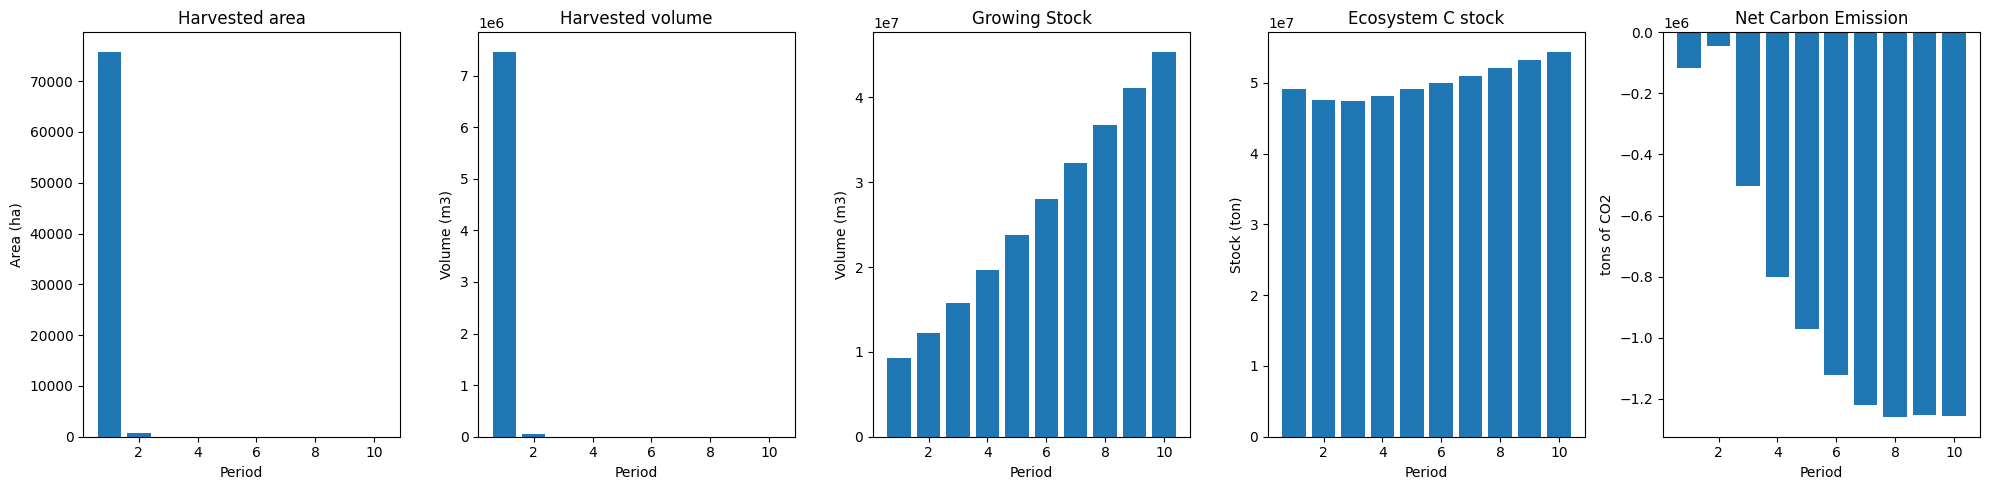

Plot saved to ./outputs/fig/redchris/redchris_min_em_no_cons_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7941
The economic indicator (the provincial government revenues) is:  270811
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


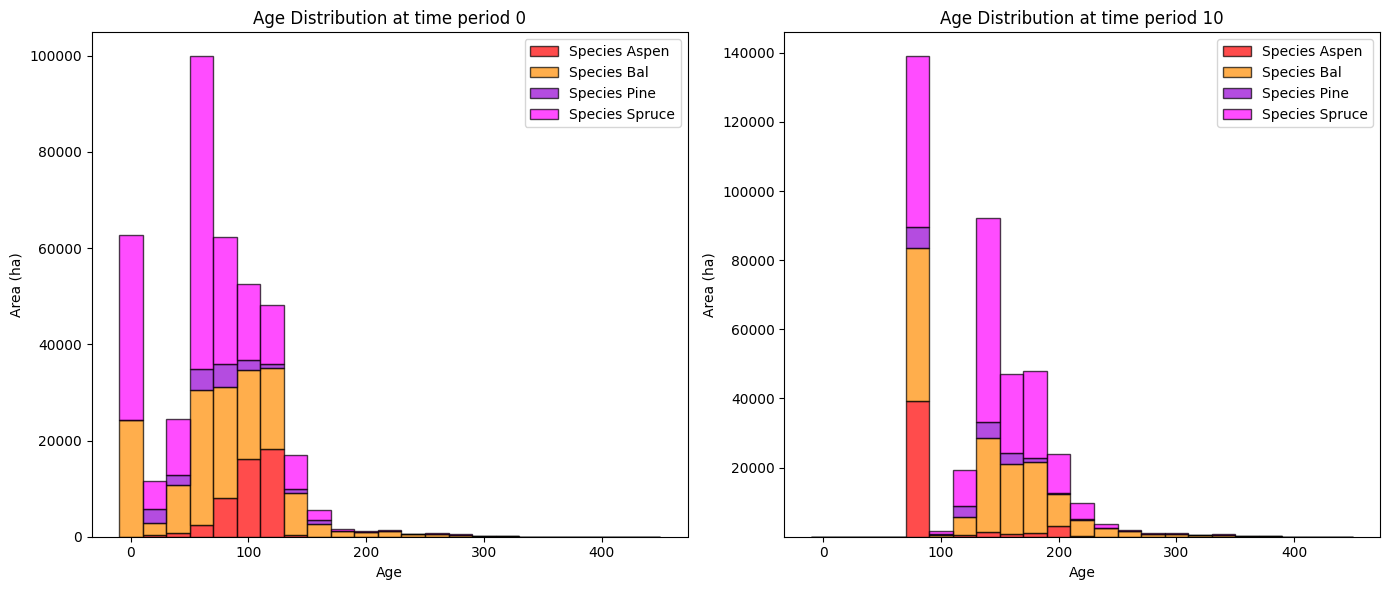

Plot saved to ./outputs/fig/redchris/redchris_min_em_no_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688   5571.817168   4626.503480
Pine     602.782616   4144.337128   3541.554512
Bal     4315.588546  35761.604279  31446.015733
Spruce  1072.814408  31059.143831  29986.329424

Overall diversity has **increased** by 69600.40 hectares from time period 0 to time period 10.


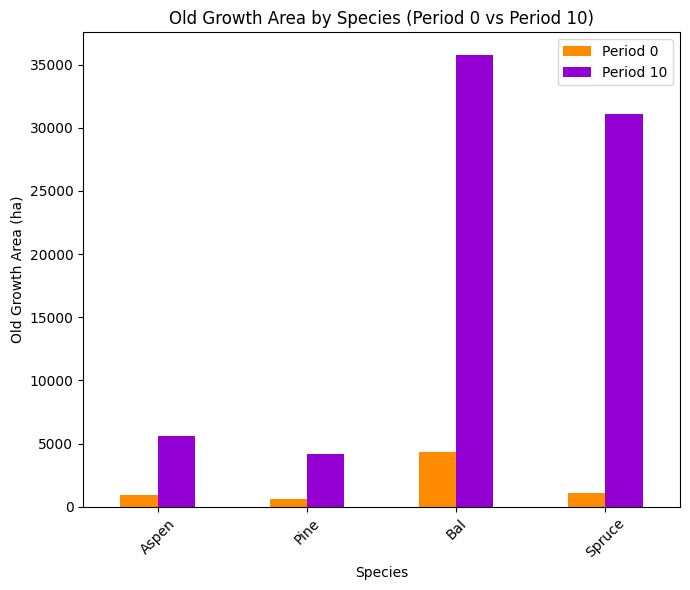

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_no_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.7657

Diversity has **decreased** by 11.91% from time 0 to time 10.


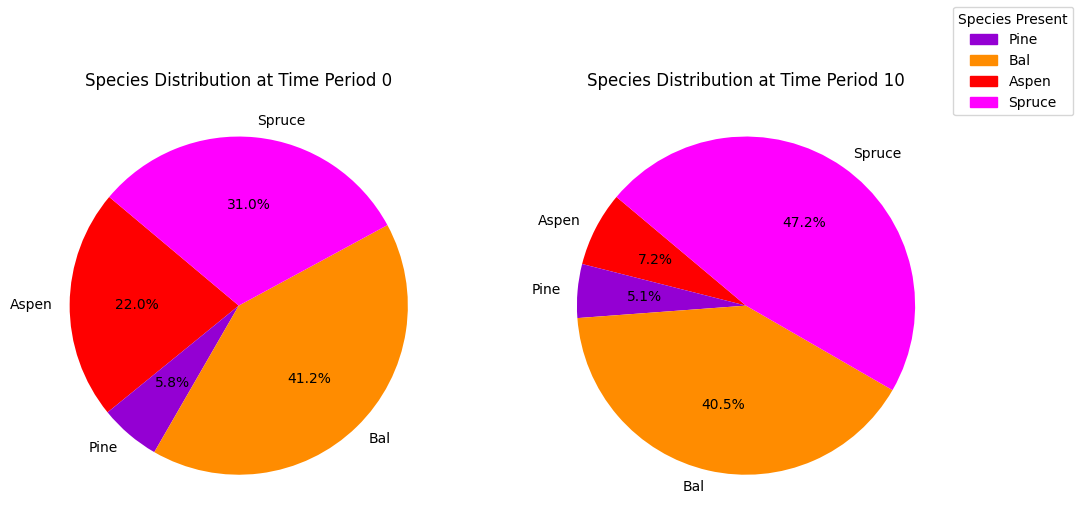

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_no_cons_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x8d629ebf
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.15s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00s



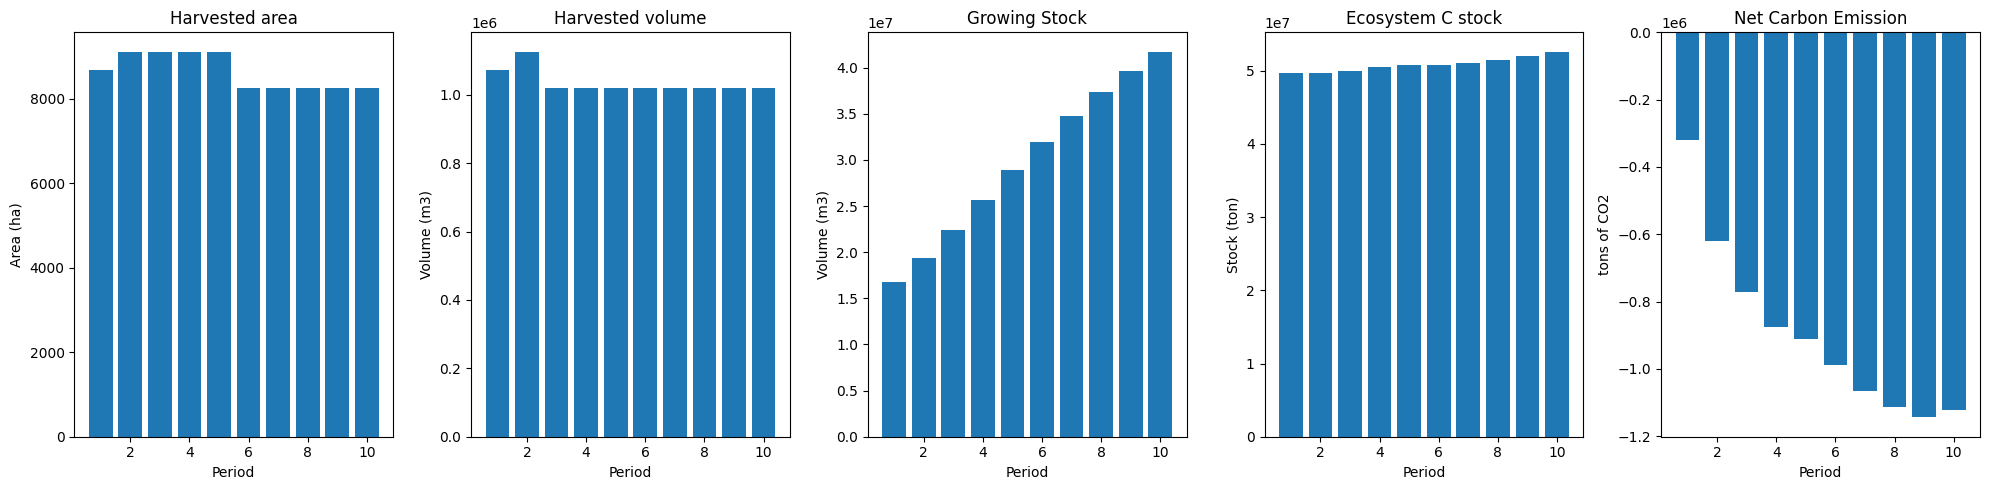

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10945
The economic indicator (the provincial government revenues) is:  373261
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


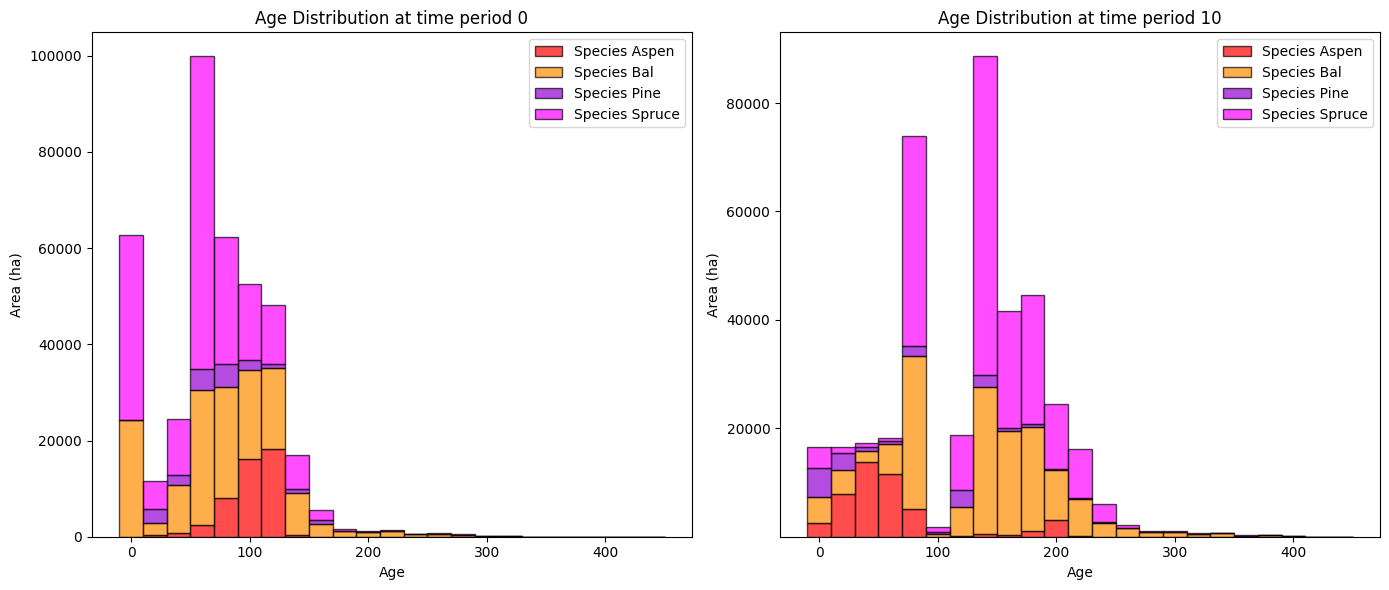

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688   4909.785142   3964.471454
Pine     602.782616   1772.814393   1170.031777
Bal     4315.588546  37139.500575  32823.912029
Spruce  1072.814408  37938.204945  36865.390537

Overall diversity has **increased** by 74823.81 hectares from time period 0 to time period 10.


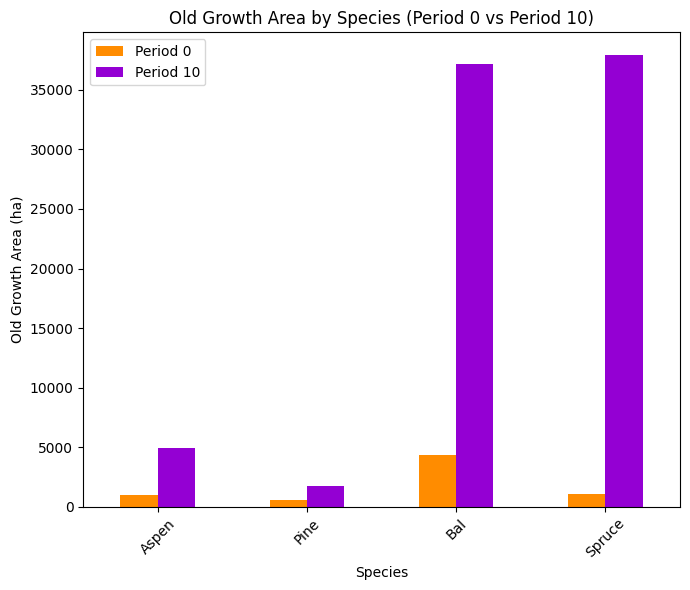

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.6474

Diversity has **decreased** by 23.74% from time 0 to time 10.


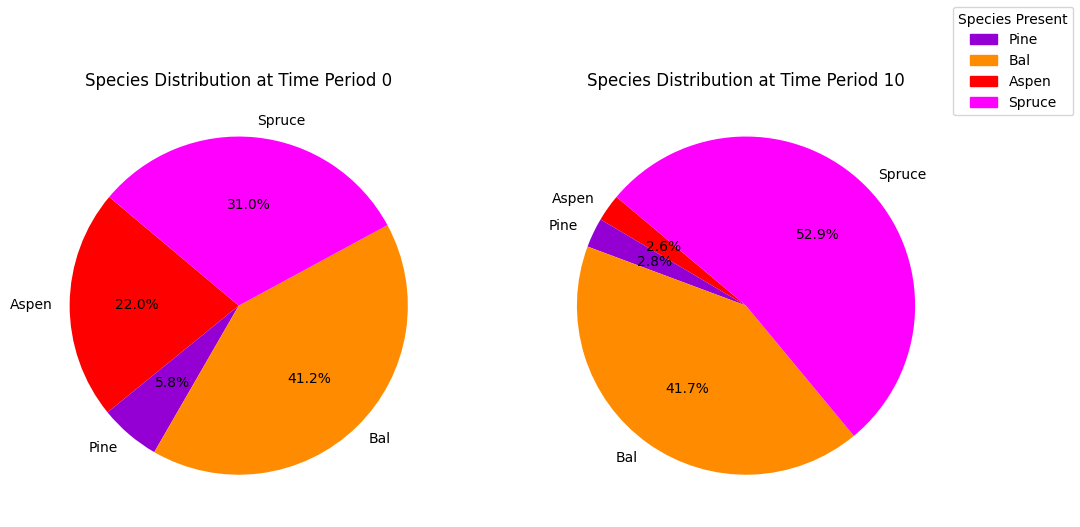

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_species_pie.pdf


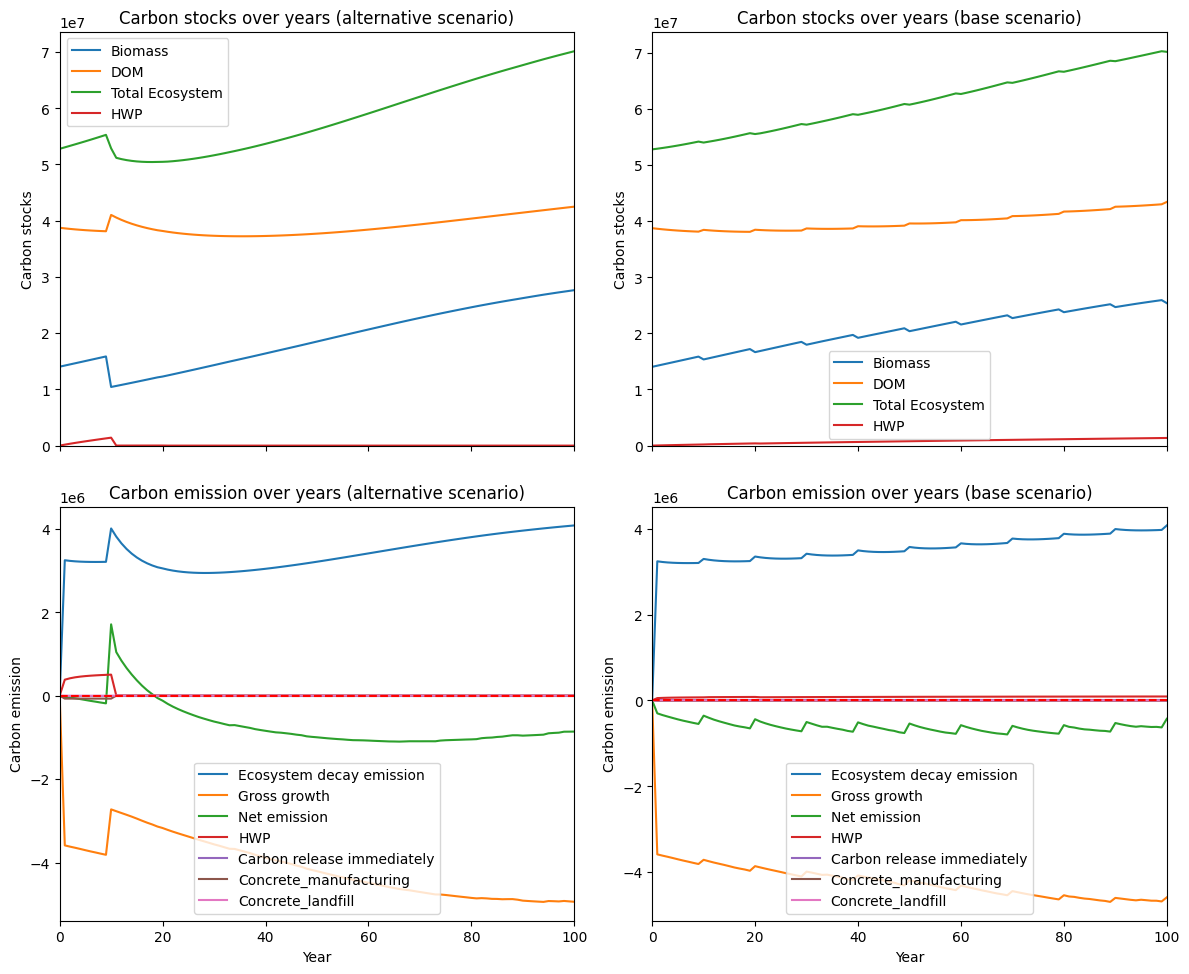

---------------------------------------------------------------------------------------
Net emission difference 15000183.990402756
Net emission base scenario 3229429.8133061714
Net emission alternative scenario -11770754.177096587
dollar_per_ton is:  0.6666584894157355
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Aspen   0.0   662.032026   662.032026
Pine    0.0  2371.522735  2371.522735
Bal     0.0 -1377.896296 -1377.896296
Spruce  0.0 -6879.061113 -6879.061113

Overall, the old growth area has **decreased** by -5223.40 hectares in the alternative scenario compared to the base scenario.


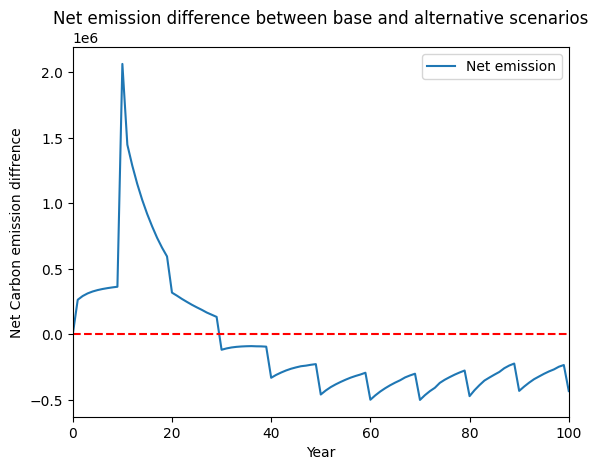

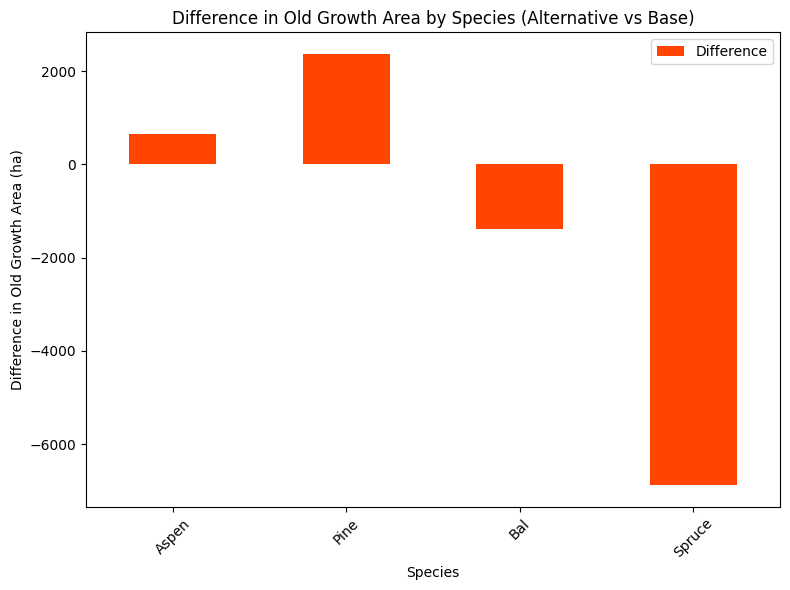

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_min_em_kpi_age_difference.pdf


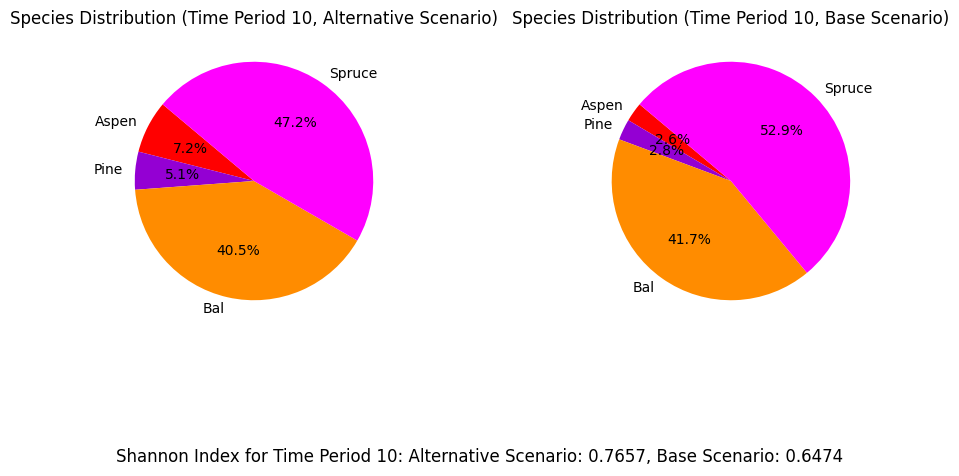

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_min_em_evenflow_cons...
running even flow constraints scenario
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3707 rows, 34533 columns and 445161 nonzeros
Model fingerprint: 0xa7d7b271
Coefficient statistics:
  Matrix range     [1e-02, 1e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 2009 rows and 2005 columns
Presolve time: 0.11s
Presolved: 1698 rows, 32528 columns, 415336 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.

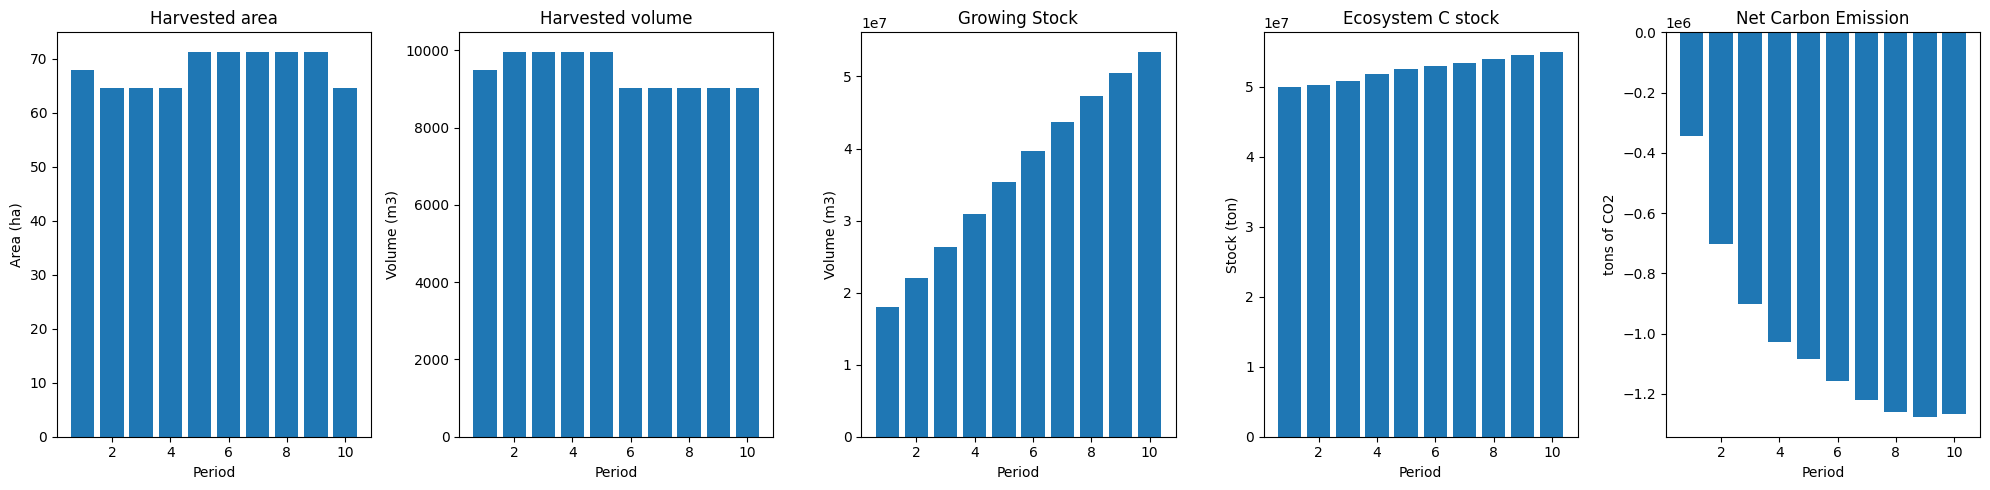

Plot saved to ./outputs/fig/redchris/redchris_min_em_evenflow_cons_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  99
The economic indicator (the provincial government revenues) is:  3405
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


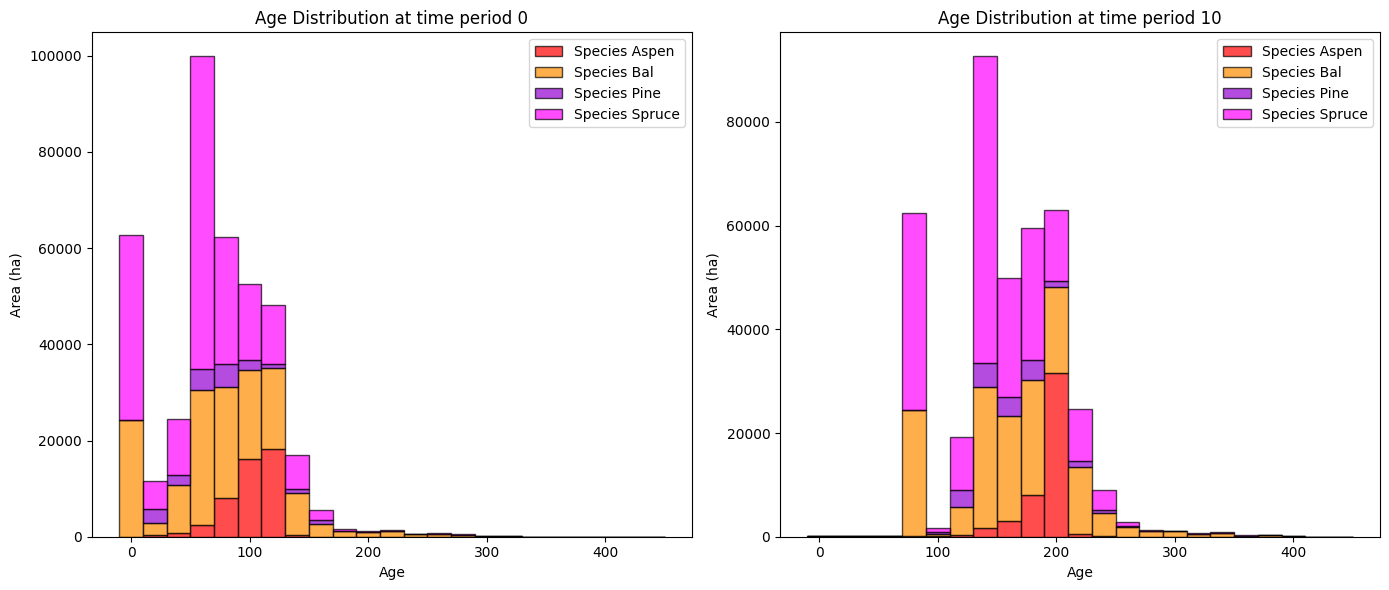

Plot saved to ./outputs/fig/redchris/redchris_min_em_evenflow_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  43919.348949  42974.035261
Pine     602.782616   9343.140807   8740.358190
Bal     4315.588546  54242.845266  49927.256720
Spruce  1072.814408  42096.061799  41023.247392

Overall diversity has **increased** by 142664.90 hectares from time period 0 to time period 10.


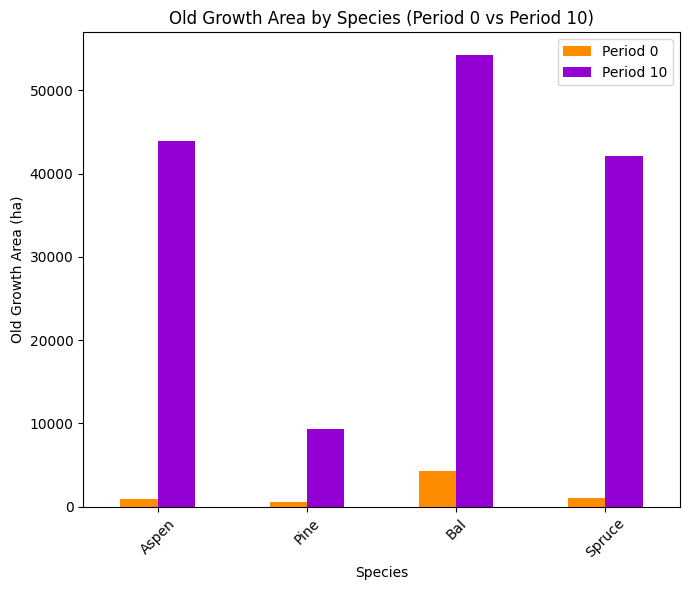

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_evenflow_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.8110

Diversity has **decreased** by 7.39% from time 0 to time 10.


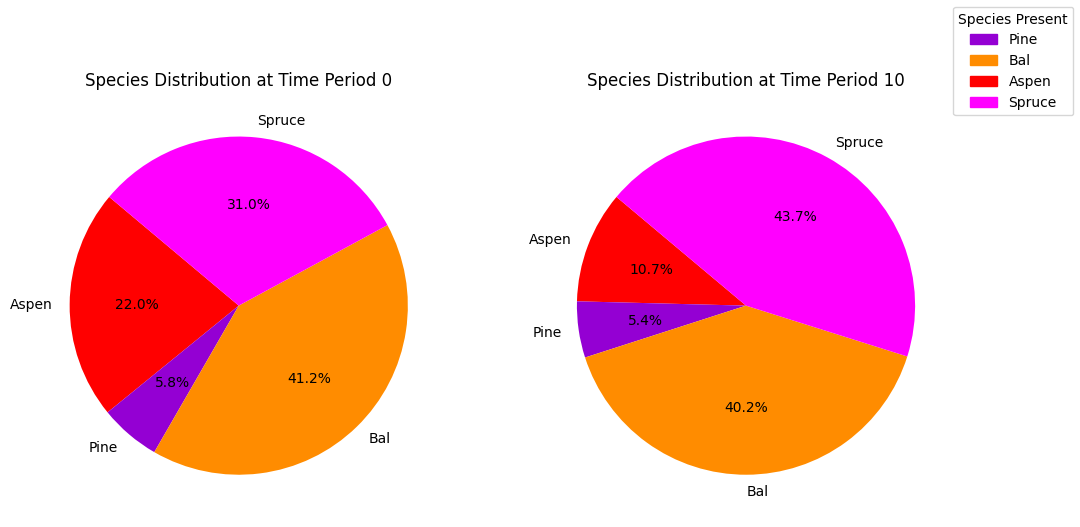

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_evenflow_cons_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x8d629ebf
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.14s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0

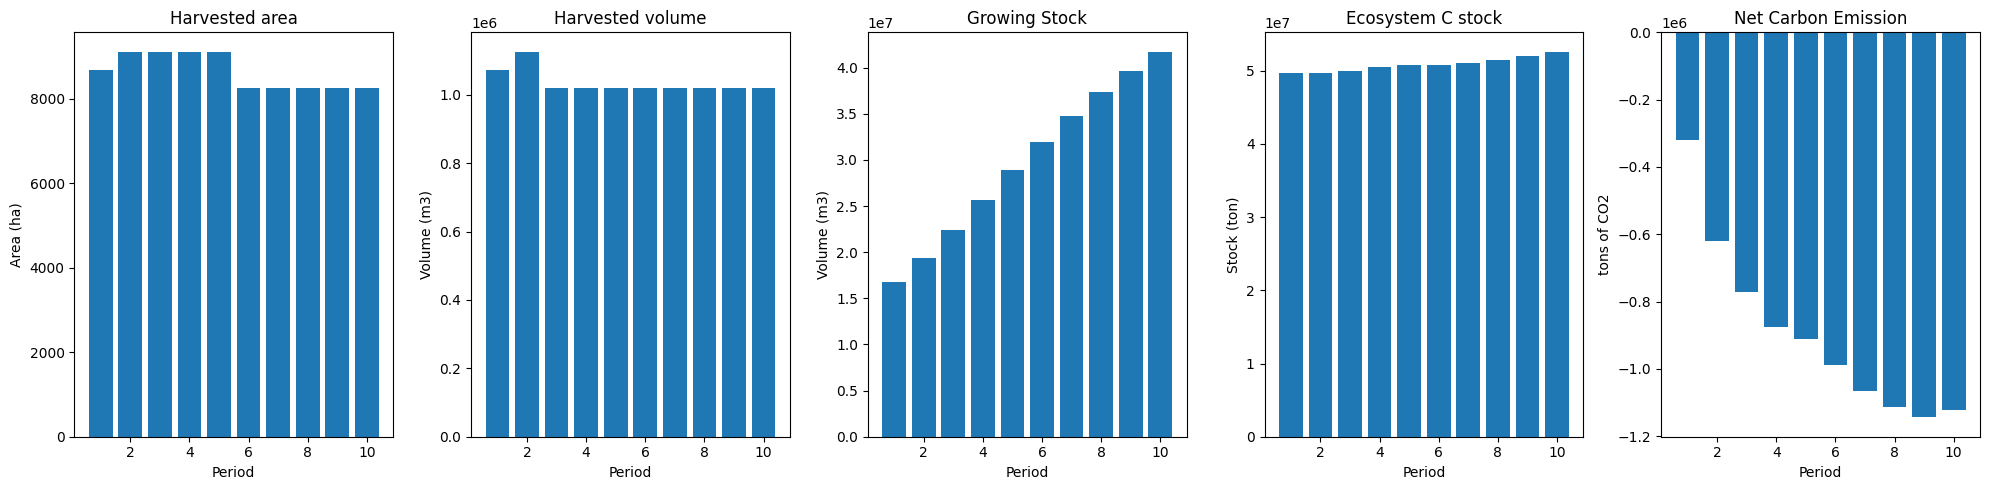

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10945
The economic indicator (the provincial government revenues) is:  373261
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


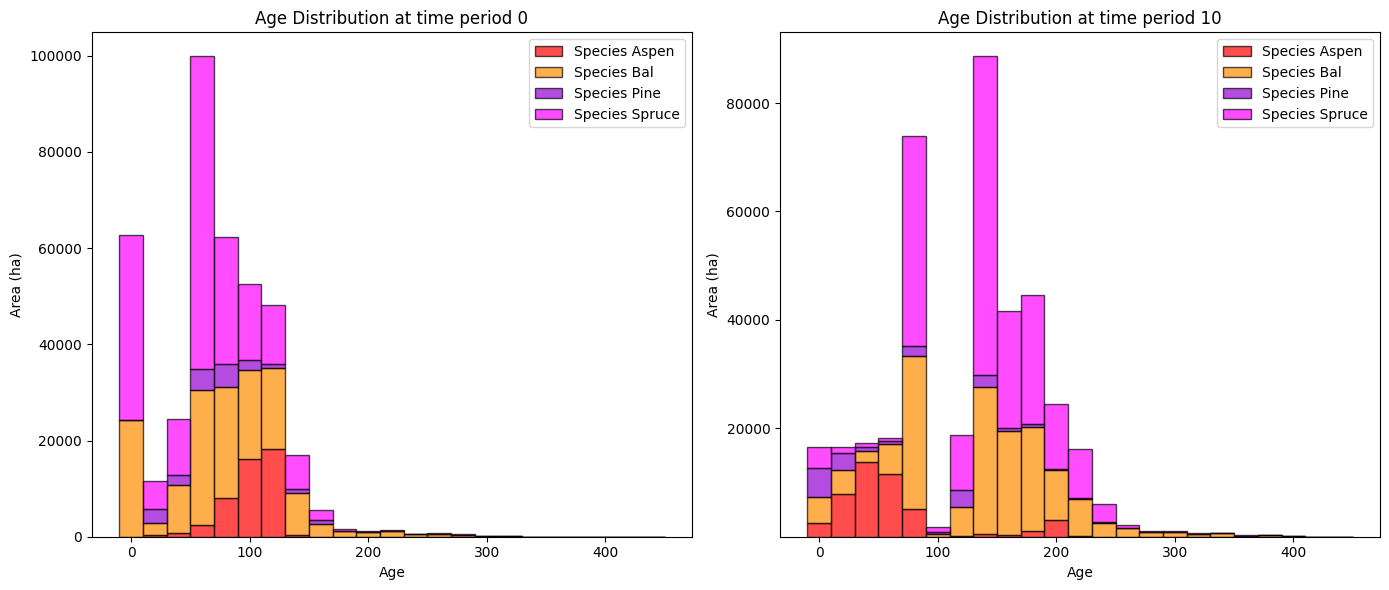

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688   4909.785142   3964.471454
Pine     602.782616   1772.814393   1170.031777
Bal     4315.588546  37139.500575  32823.912029
Spruce  1072.814408  37938.204945  36865.390537

Overall diversity has **increased** by 74823.81 hectares from time period 0 to time period 10.


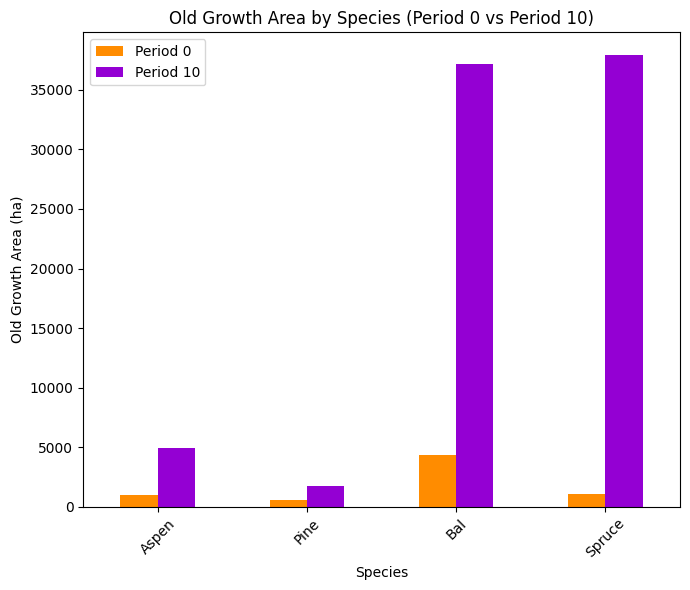

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.6474

Diversity has **decreased** by 23.74% from time 0 to time 10.


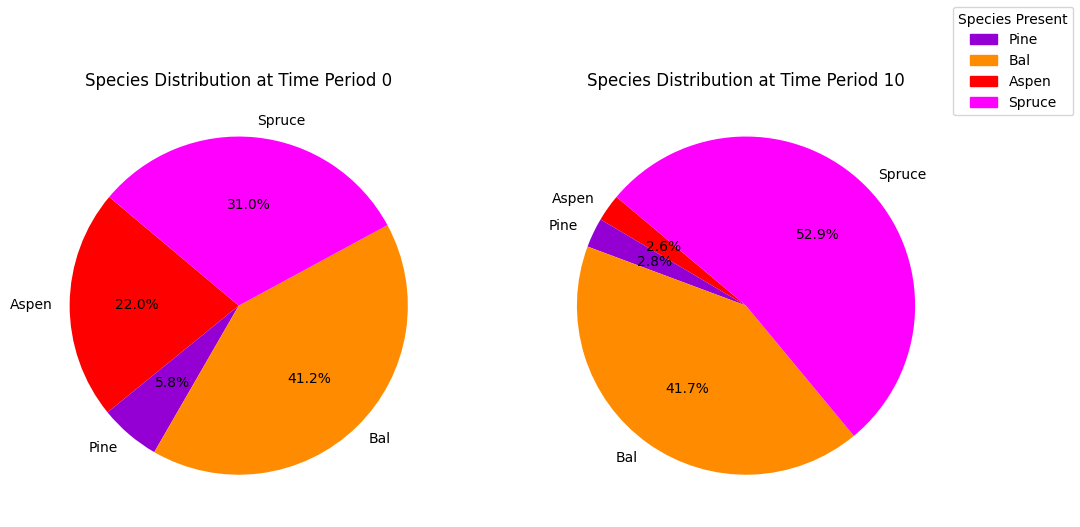

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_species_pie.pdf


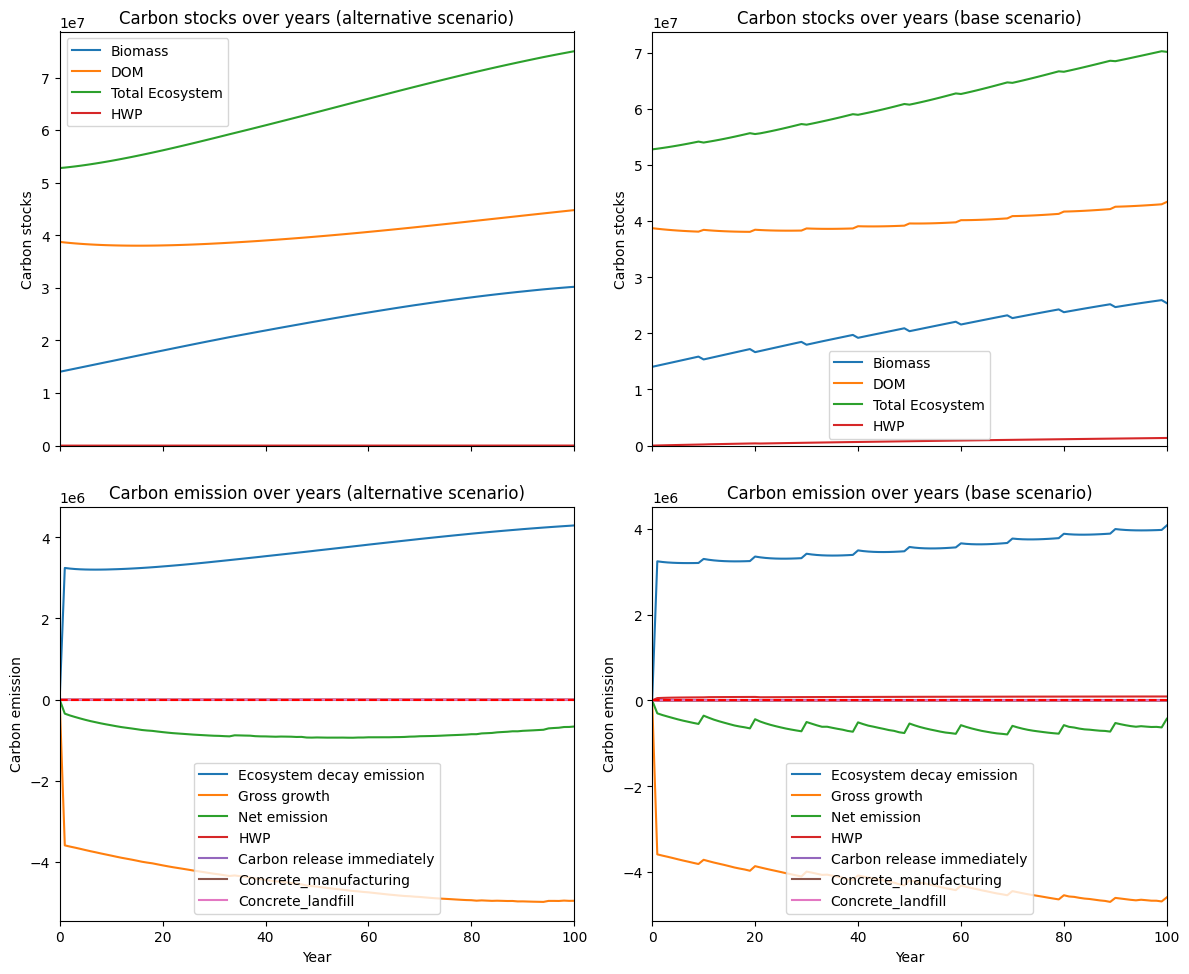

---------------------------------------------------------------------------------------
Net emission difference -3890176.833050059
Net emission base scenario -15660931.010146644
Net emission alternative scenario -11770754.177096587
dollar_per_ton is:  2.570577233158727
Comparison of Old Growth Areas (Alternative - Base)
          0            10    Difference
Aspen   0.0  39009.563807  39009.563807
Pine    0.0   7570.326414   7570.326414
Bal     0.0  17103.344691  17103.344691
Spruce  0.0   4157.856855   4157.856855

Overall, the old growth area has **increased** by 67841.09 hectares in the alternative scenario compared to the base scenario.


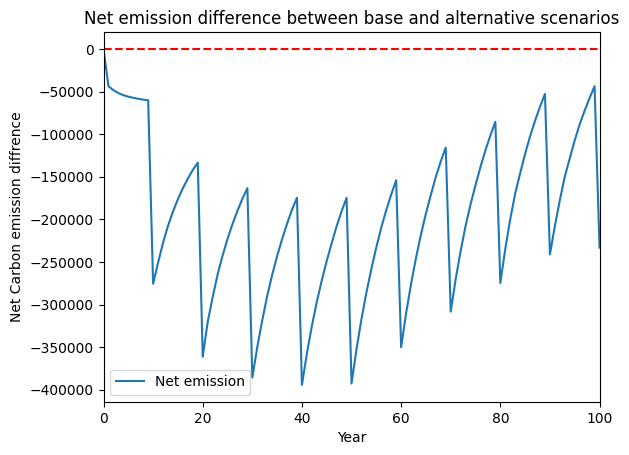

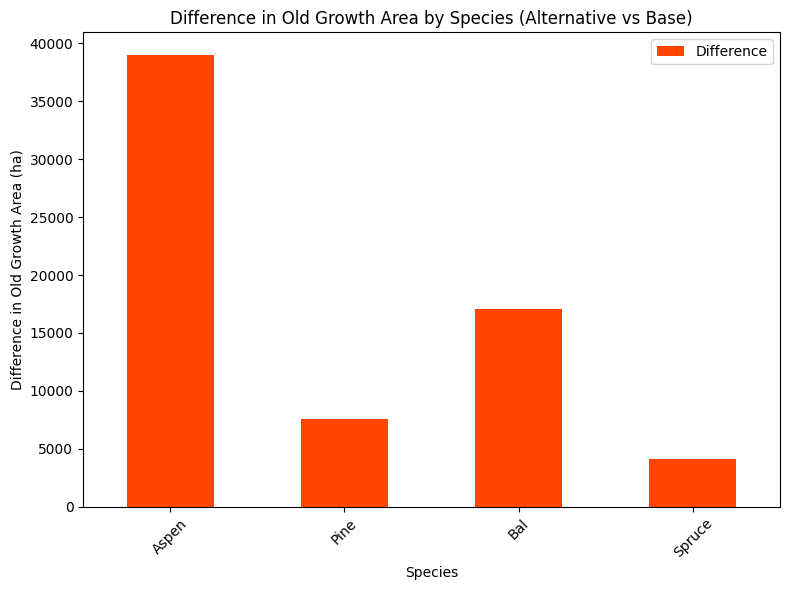

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_min_em_kpi_age_difference.pdf


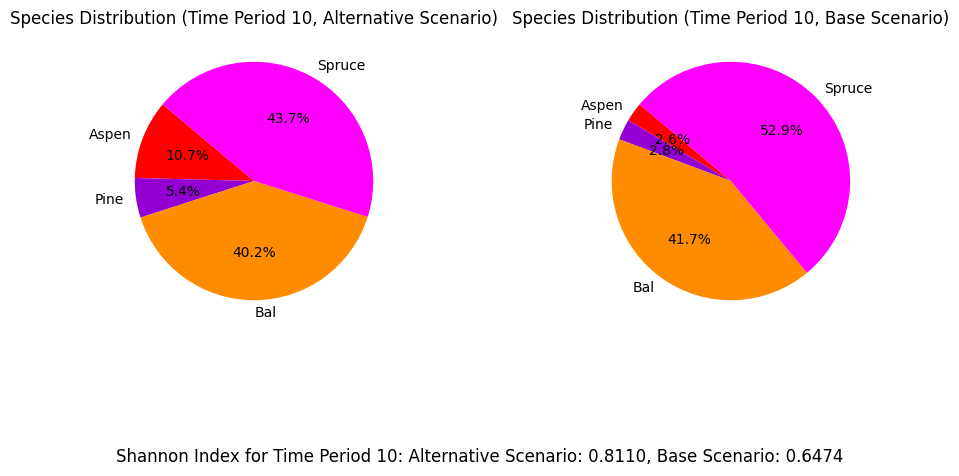

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_min_em_bau_redchrs...
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x8d629ebf
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.14s
Presolved: 1699 rows, 32528 column

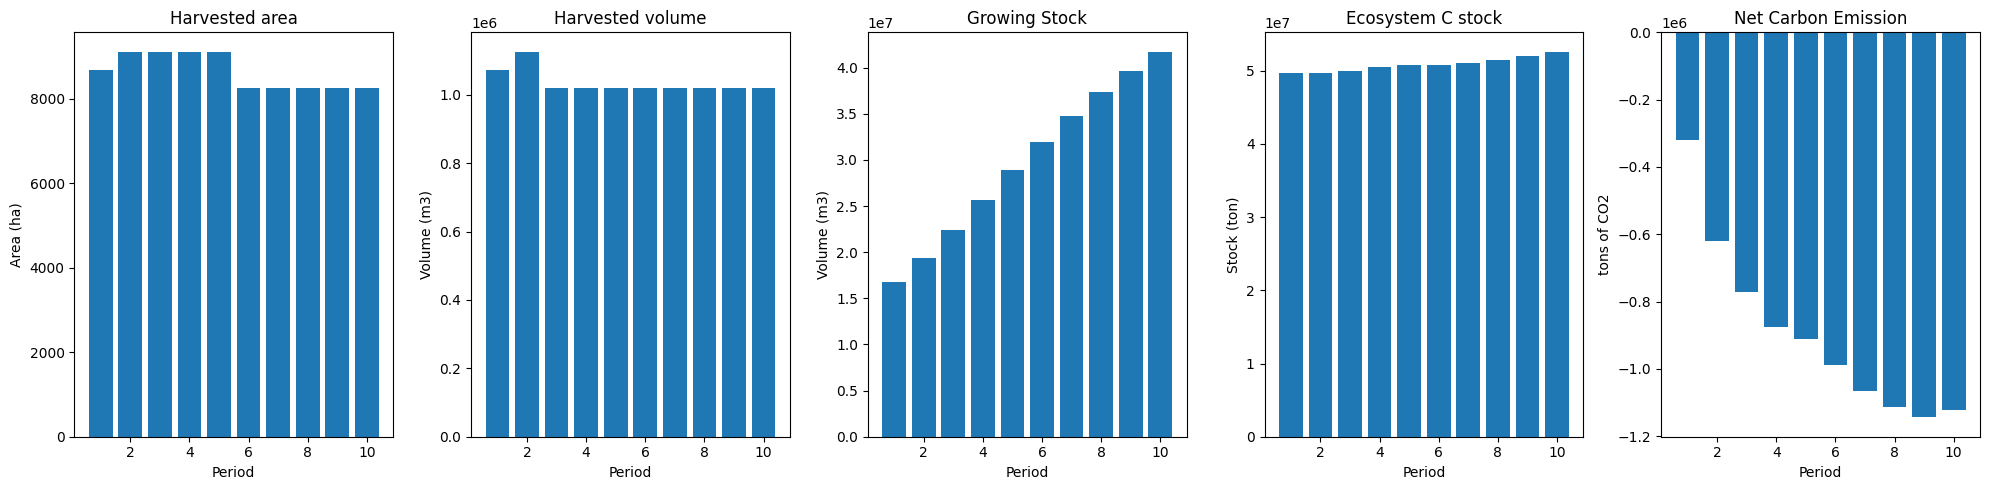

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10945
The economic indicator (the provincial government revenues) is:  373261
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


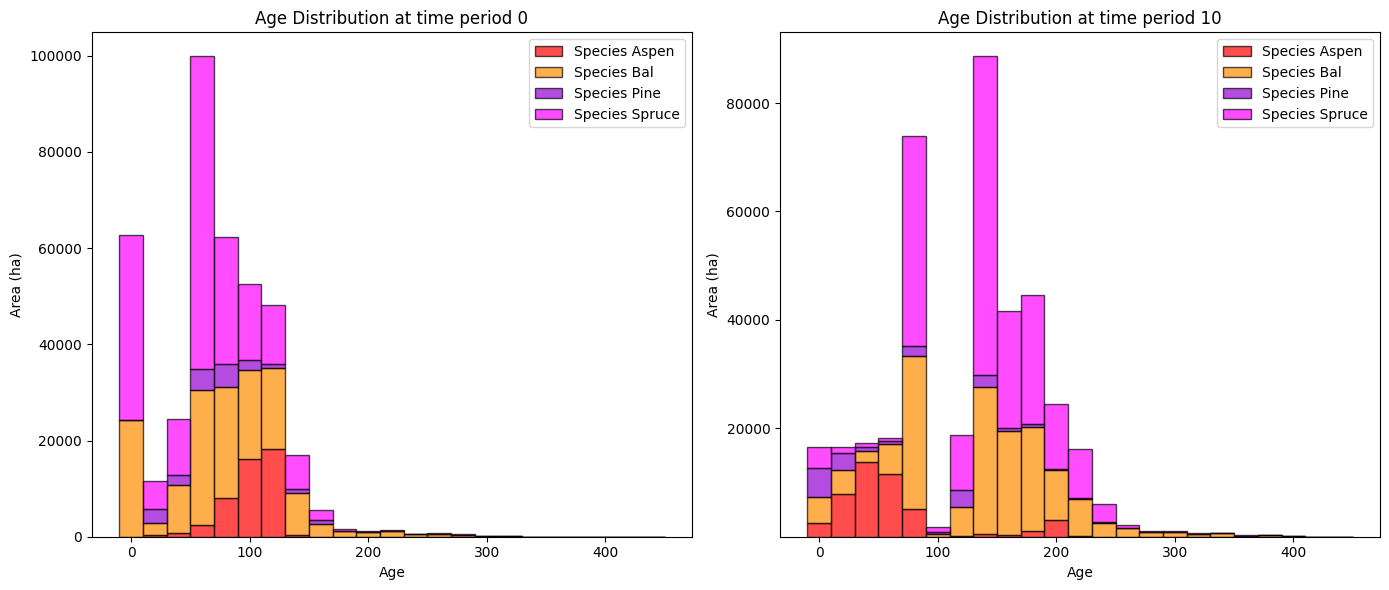

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688   4909.785142   3964.471454
Pine     602.782616   1772.814393   1170.031777
Bal     4315.588546  37139.500575  32823.912029
Spruce  1072.814408  37938.204945  36865.390537

Overall diversity has **increased** by 74823.81 hectares from time period 0 to time period 10.


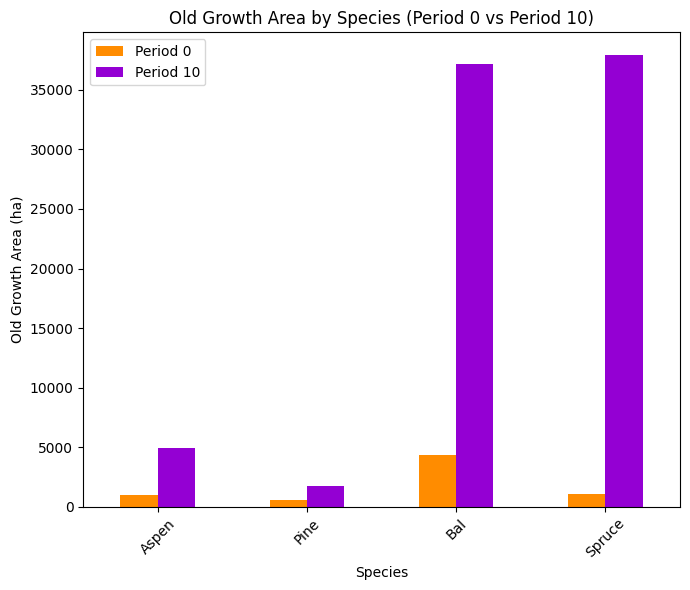

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.6474

Diversity has **decreased** by 23.74% from time 0 to time 10.


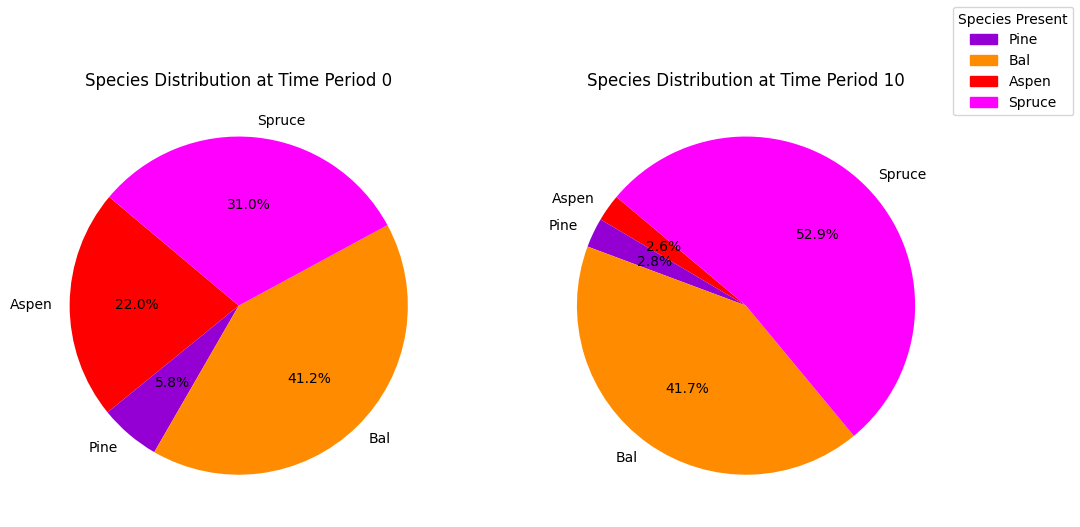

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x8d629ebf
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.12s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.0

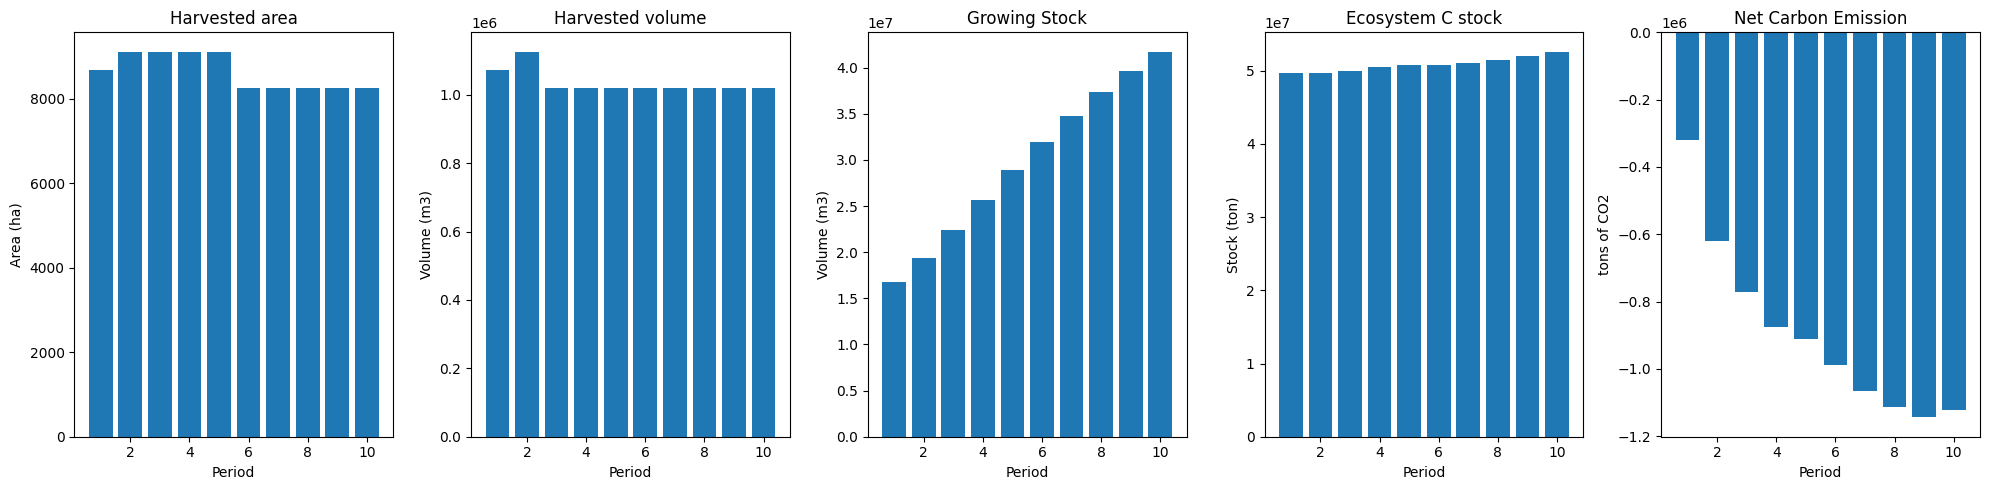

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10945
The economic indicator (the provincial government revenues) is:  373261
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


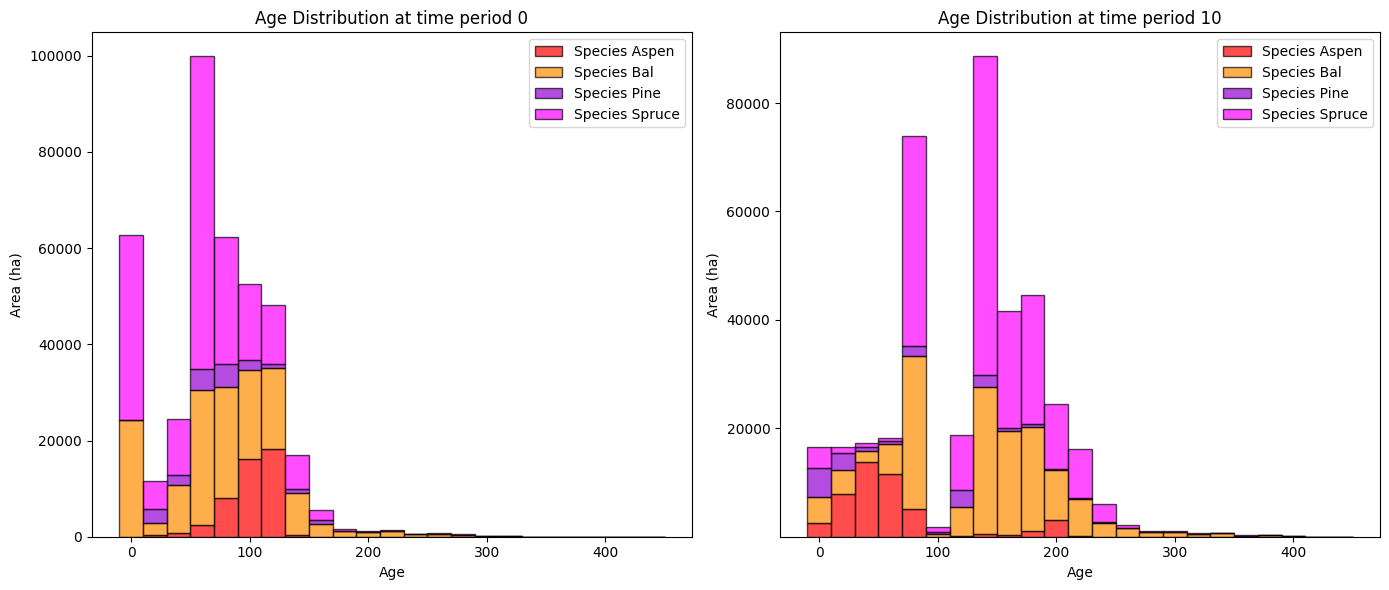

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688   4909.785142   3964.471454
Pine     602.782616   1772.814393   1170.031777
Bal     4315.588546  37139.500575  32823.912029
Spruce  1072.814408  37938.204945  36865.390537

Overall diversity has **increased** by 74823.81 hectares from time period 0 to time period 10.


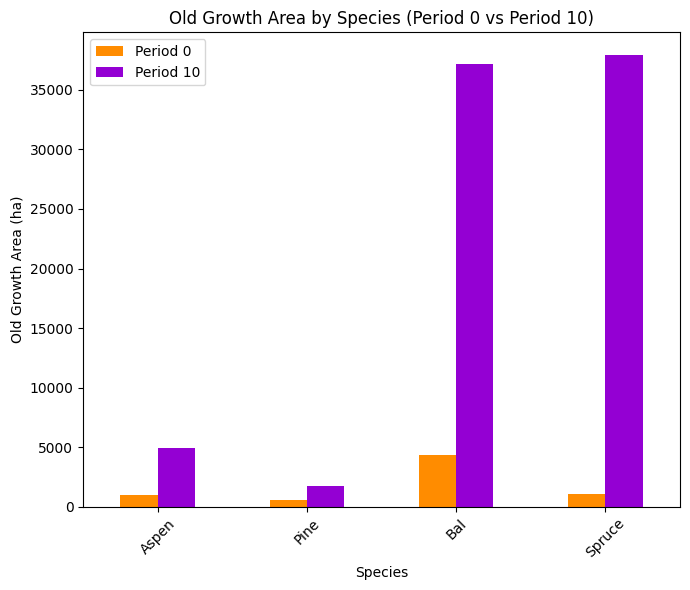

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.6474

Diversity has **decreased** by 23.74% from time 0 to time 10.


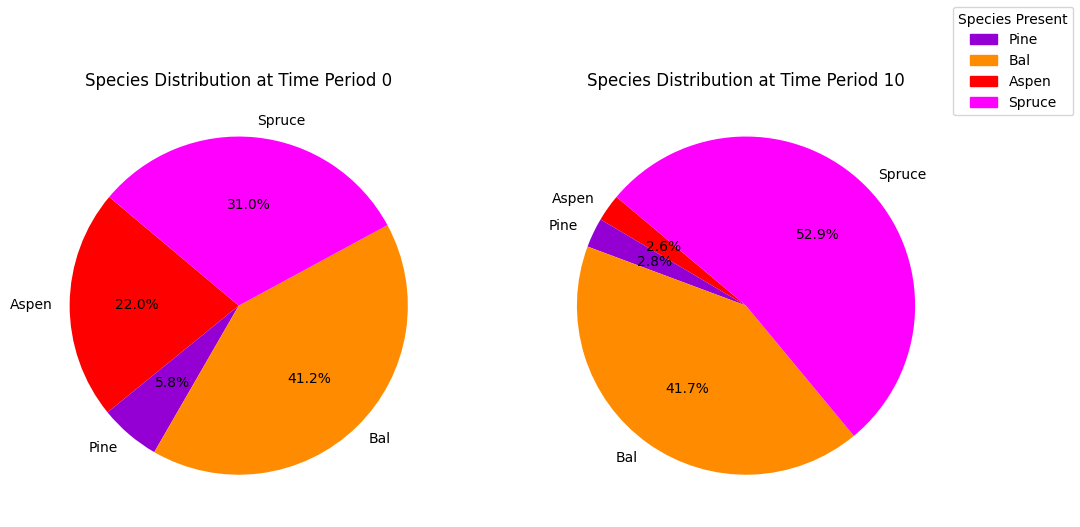

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_species_pie.pdf


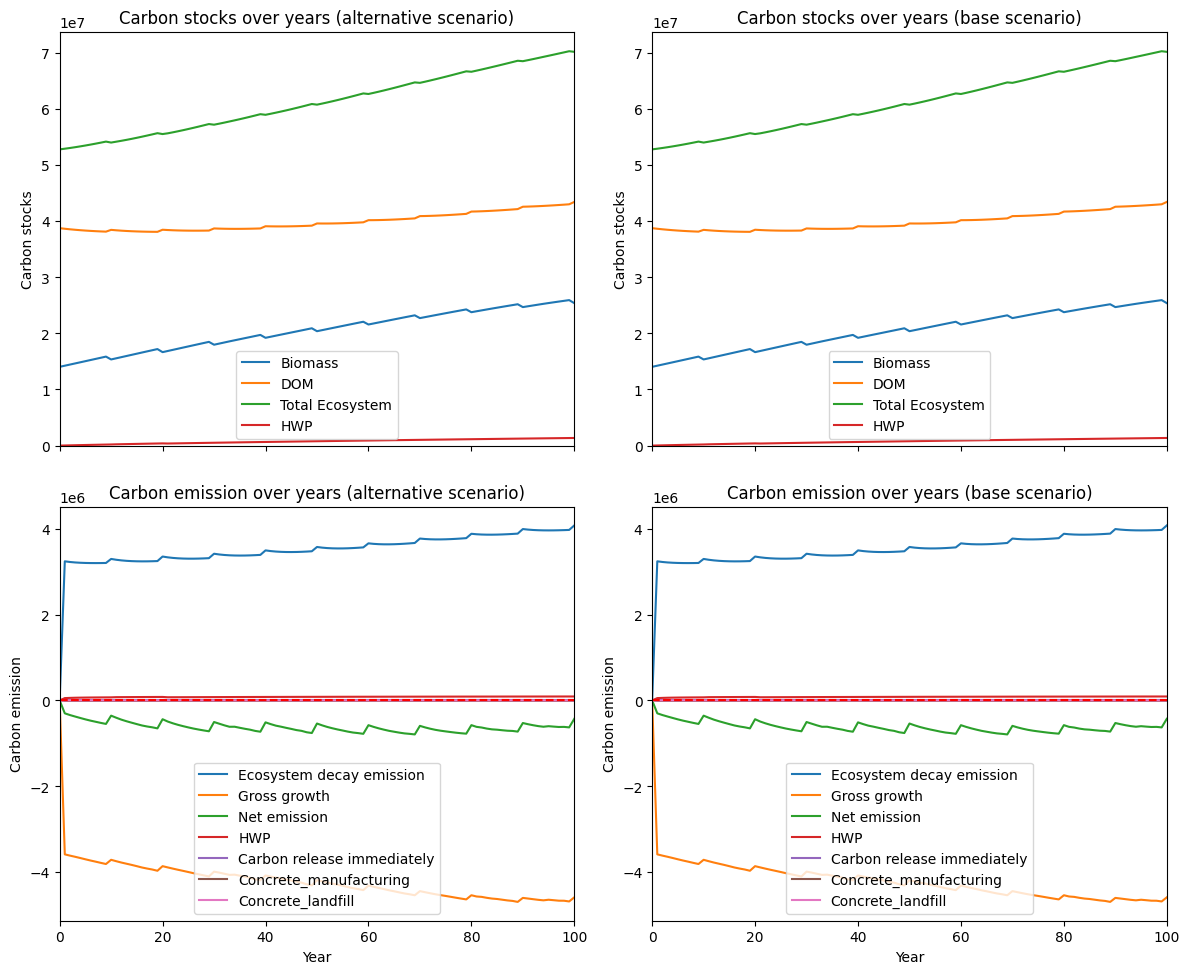

---------------------------------------------------------------------------------------
Net emission difference 0.0
Net emission base scenario -11770754.177096587
Net emission alternative scenario -11770754.177096587
dollar_per_ton is:  inf
Comparison of Old Growth Areas (Alternative - Base)
          0   10  Difference
Aspen   0.0  0.0         0.0
Pine    0.0  0.0         0.0
Bal     0.0  0.0         0.0
Spruce  0.0  0.0         0.0

Overall, the old growth area has **increased** by 0.00 hectares in the alternative scenario compared to the base scenario.


/media/data/project/eghasemi/nbds_mining/util_opt.py:1211: RuntimeWarning: divide by zero encountered in scalar divide
  dollar_per_ton = abs(budget_input / dif_scenario.iloc[:25]['Net emission'].sum())


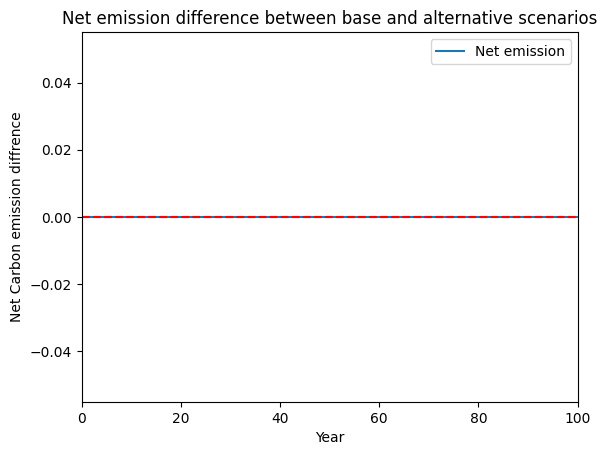

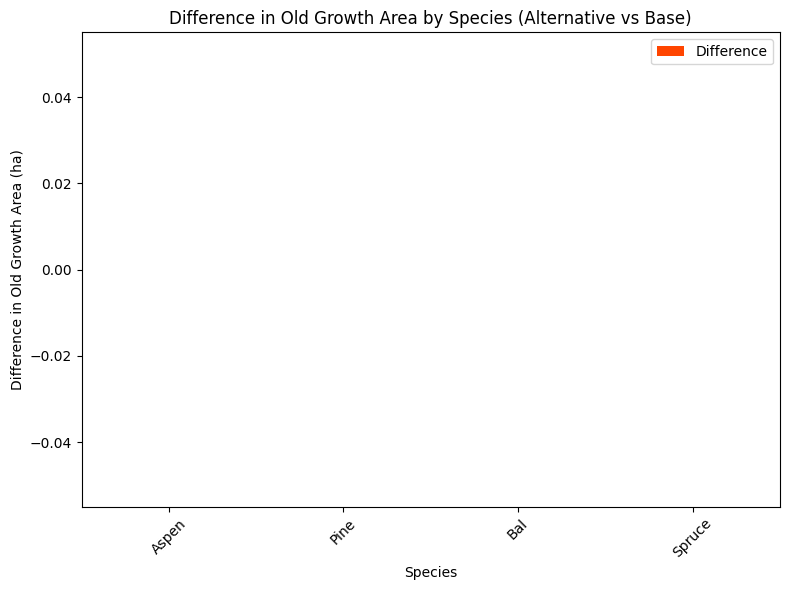

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_min_em_kpi_age_difference.pdf


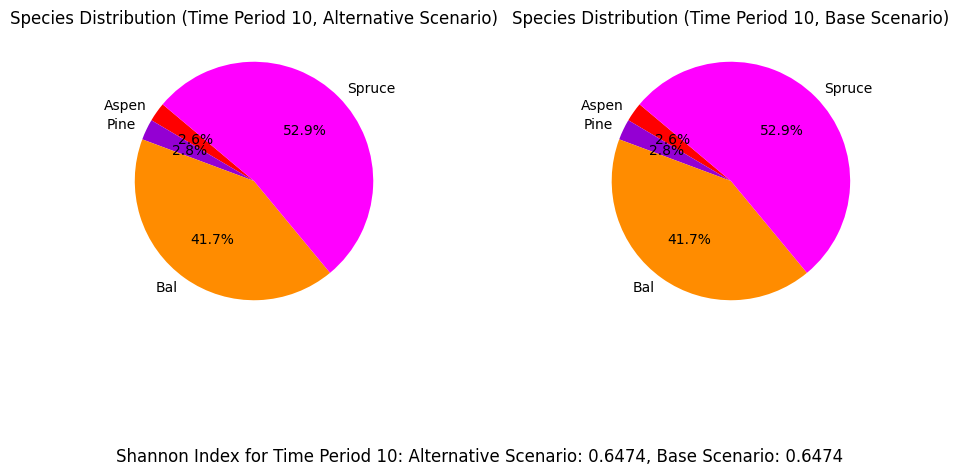

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_min_em_redchrs_AAC_90%...
running the scenario for the Red Chris mining site (90%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x96746e35
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.14s
Presolved: 1699 rows, 32529 column

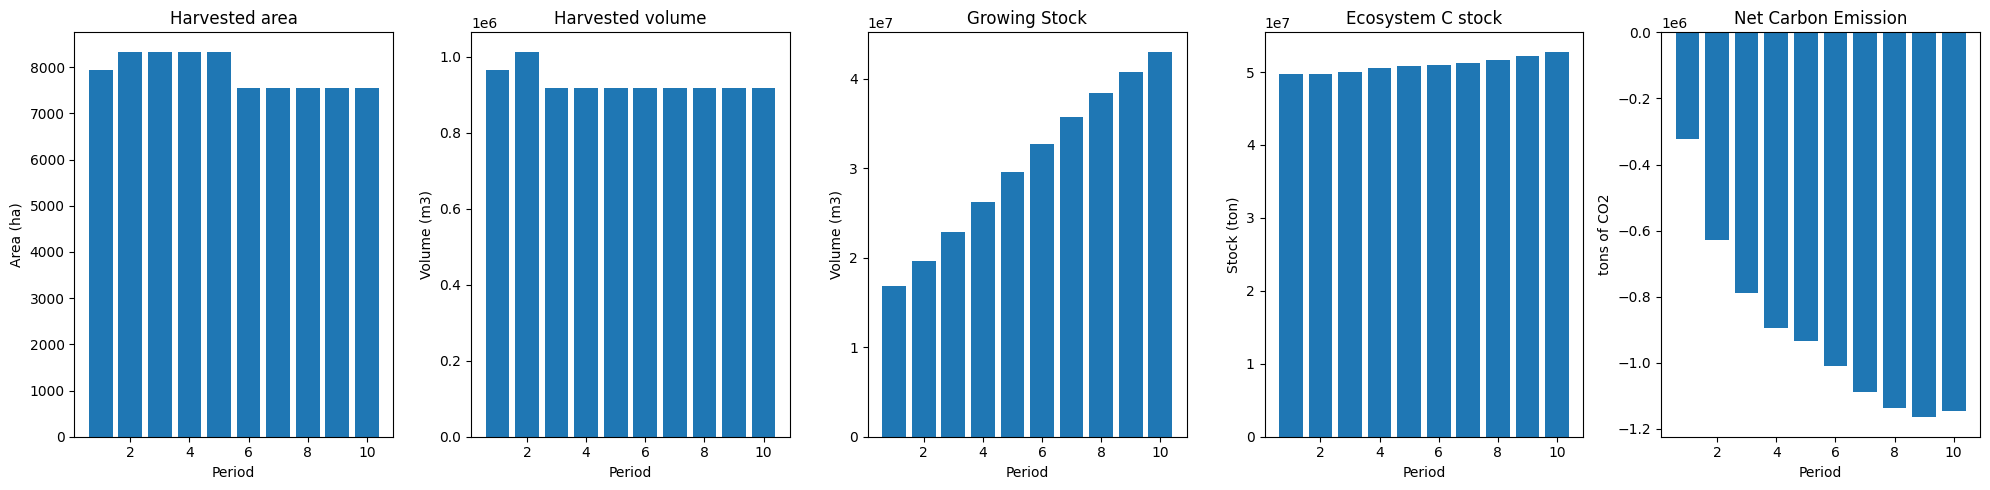

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_90%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  9850
The economic indicator (the provincial government revenues) is:  335935
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


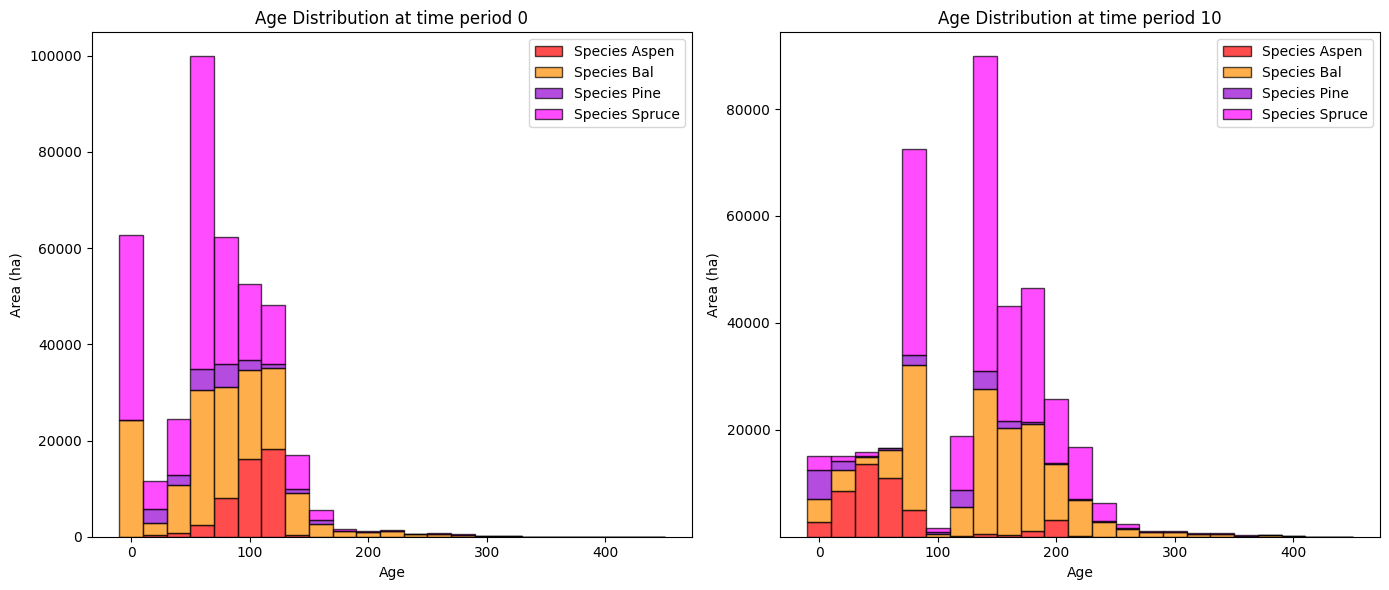

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_90%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688   4909.785142   3964.471454
Pine     602.782616   2288.371009   1685.588393
Bal     4315.588546  38696.344288  34380.755742
Spruce  1072.814408  39283.039610  38210.225202

Overall diversity has **increased** by 78241.04 hectares from time period 0 to time period 10.


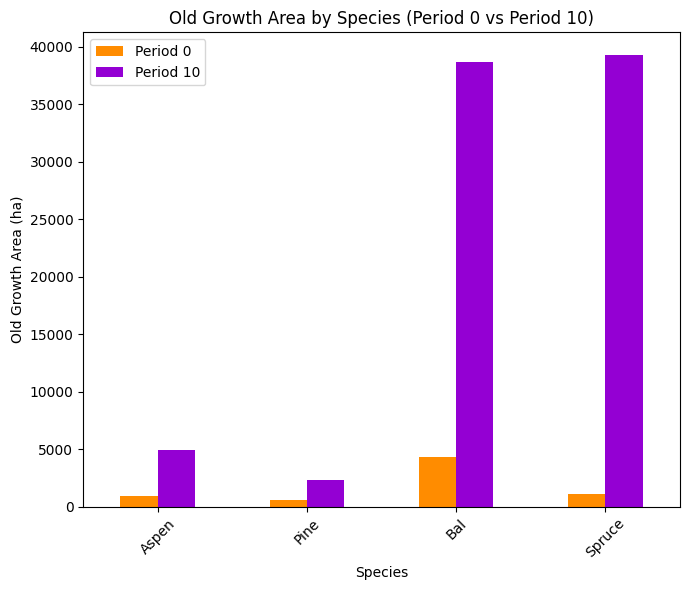

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_90%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.6559

Diversity has **decreased** by 22.90% from time 0 to time 10.


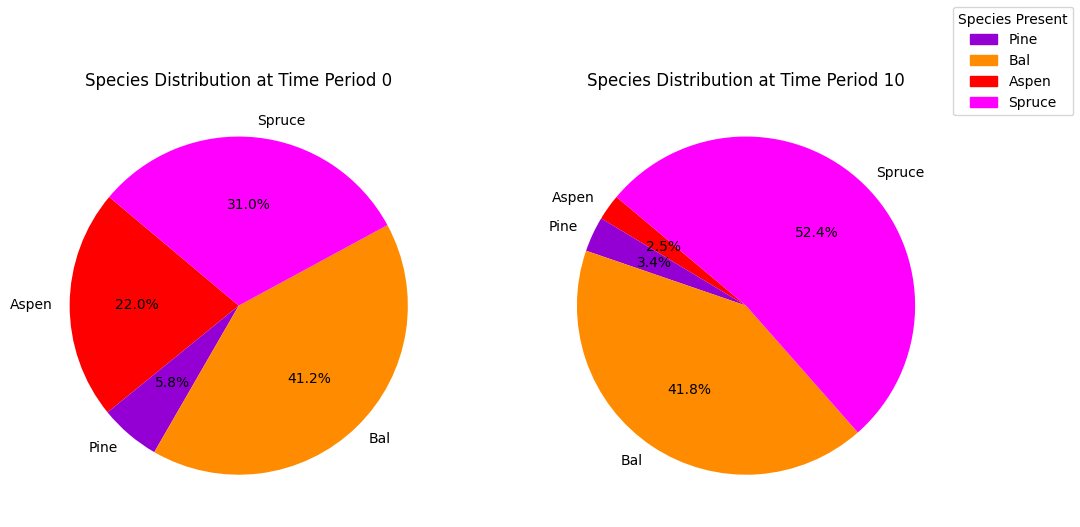

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_90%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x8d629ebf
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.12s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

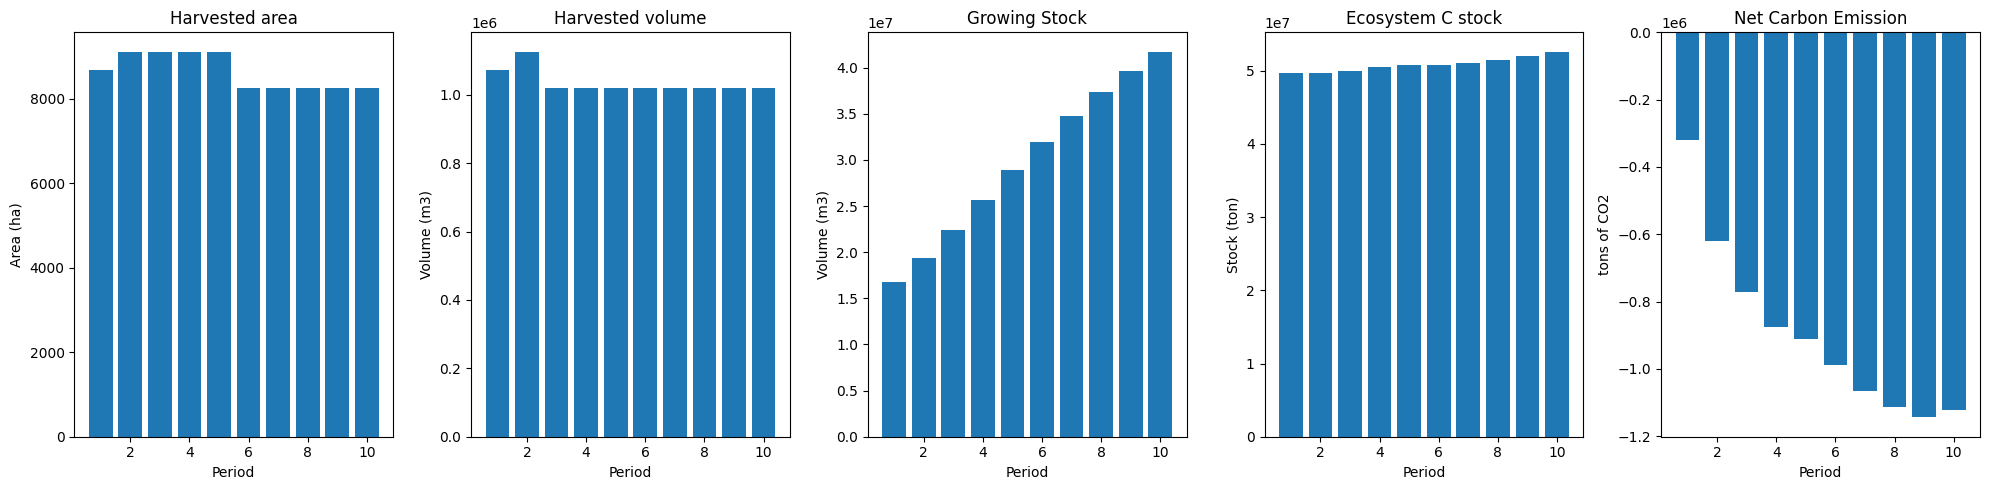

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10945
The economic indicator (the provincial government revenues) is:  373261
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


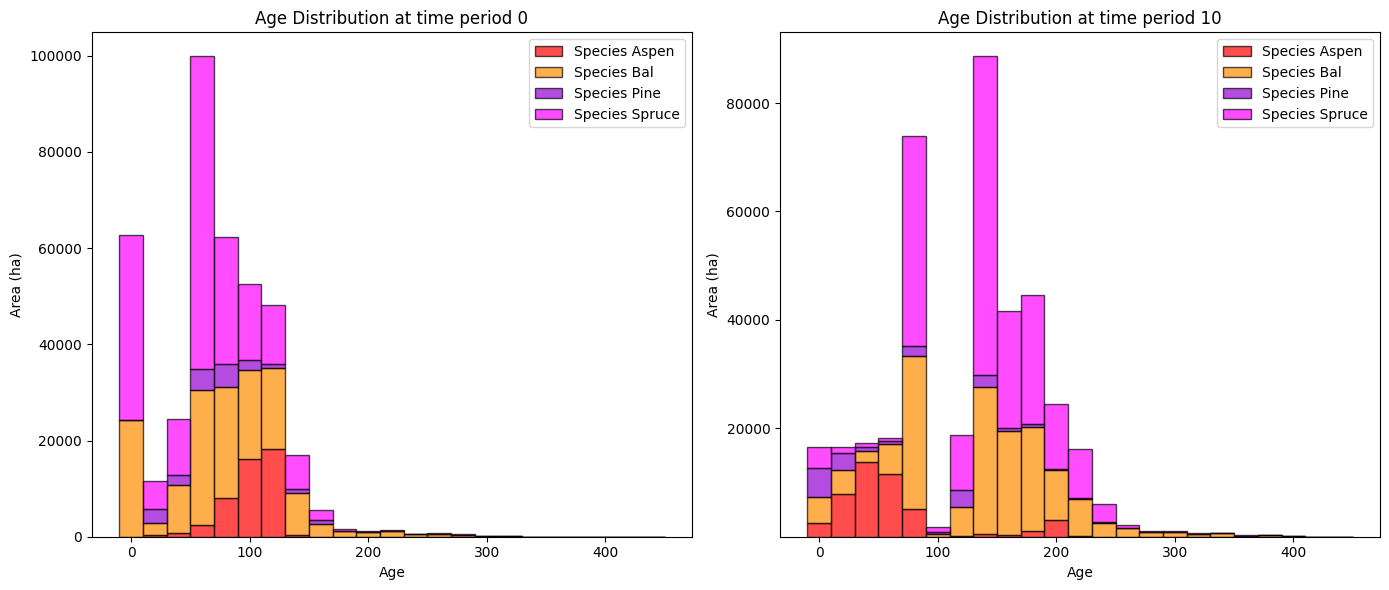

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688   4909.785142   3964.471454
Pine     602.782616   1772.814393   1170.031777
Bal     4315.588546  37139.500575  32823.912029
Spruce  1072.814408  37938.204945  36865.390537

Overall diversity has **increased** by 74823.81 hectares from time period 0 to time period 10.


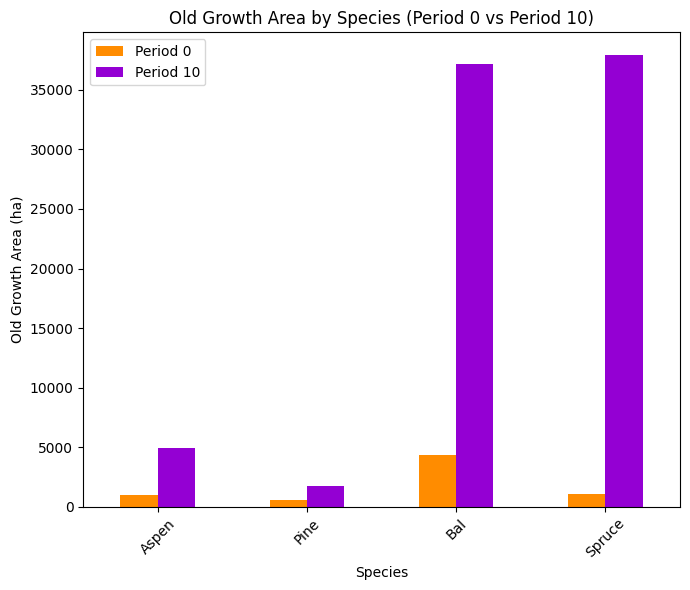

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.6474

Diversity has **decreased** by 23.74% from time 0 to time 10.


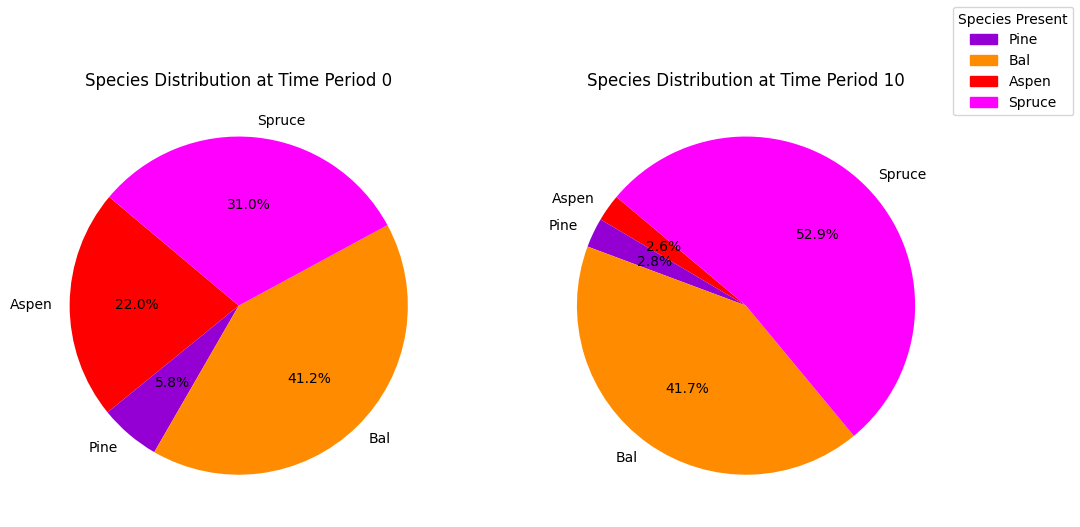

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_species_pie.pdf


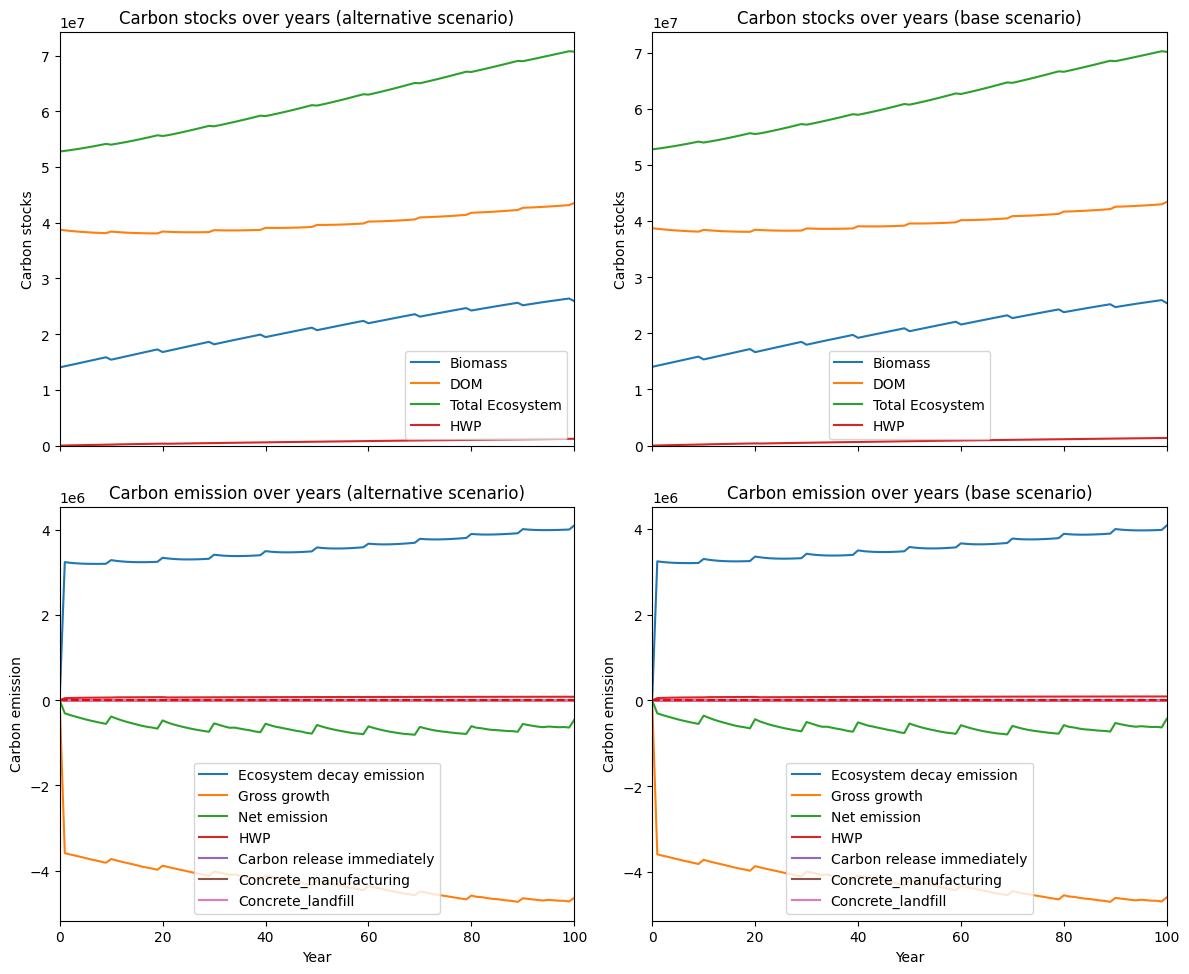

---------------------------------------------------------------------------------------
Net emission difference -380375.96142489824
Net emission base scenario -12151130.138521483
Net emission alternative scenario -11770754.177096587
dollar_per_ton is:  26.2897790978687
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Aspen   0.0     0.000000     0.000000
Pine    0.0   515.556616   515.556616
Bal     0.0  1556.843713  1556.843713
Spruce  0.0  1344.834665  1344.834665

Overall, the old growth area has **increased** by 3417.23 hectares in the alternative scenario compared to the base scenario.


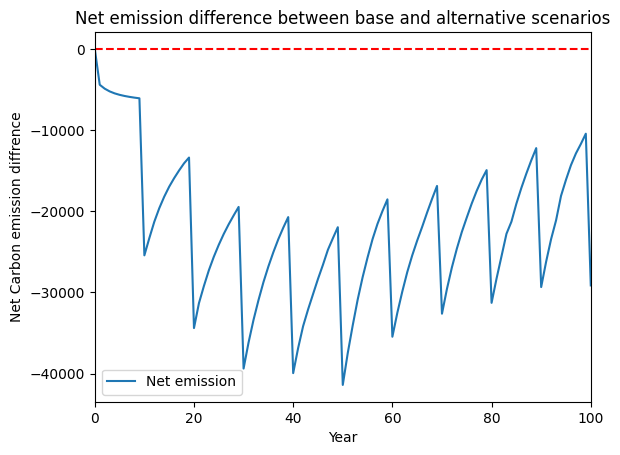

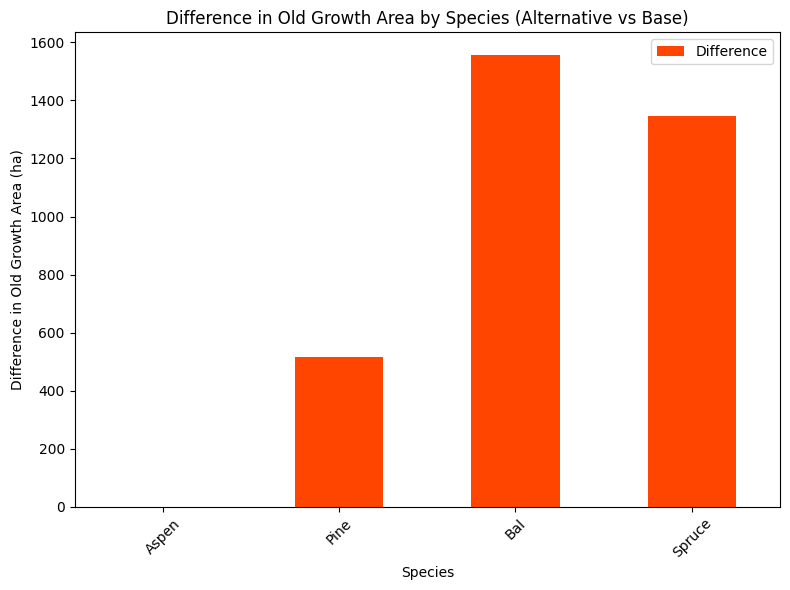

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_min_em_kpi_age_difference.pdf


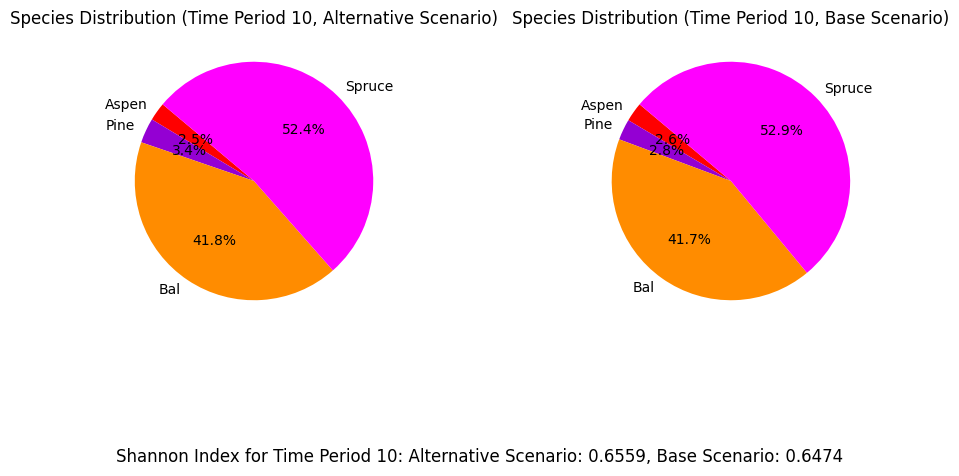

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_min_em_redchrs_AAC_80%...
running the scenario for the Red Chris mining site (80%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xe72b4d9b
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.17s
Presolved: 1699 rows, 32529 column

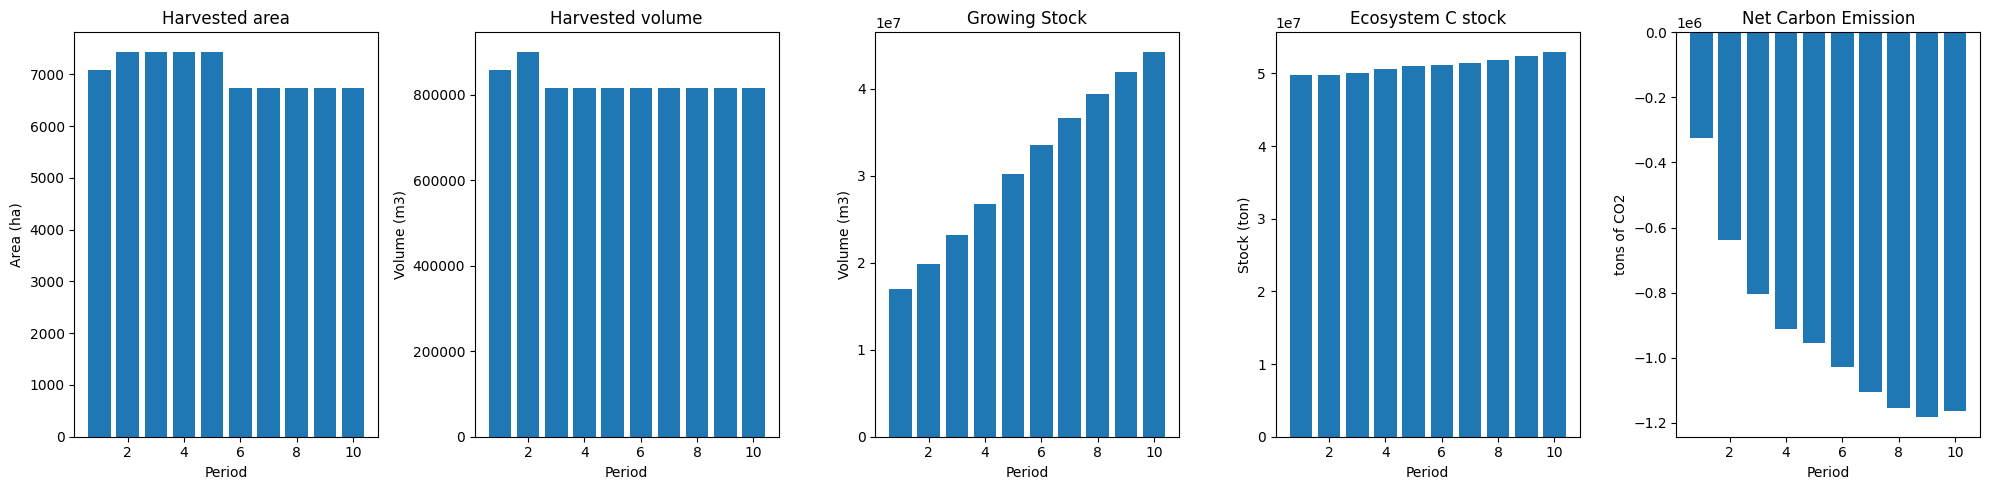

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_80%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  8756
The economic indicator (the provincial government revenues) is:  298609
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


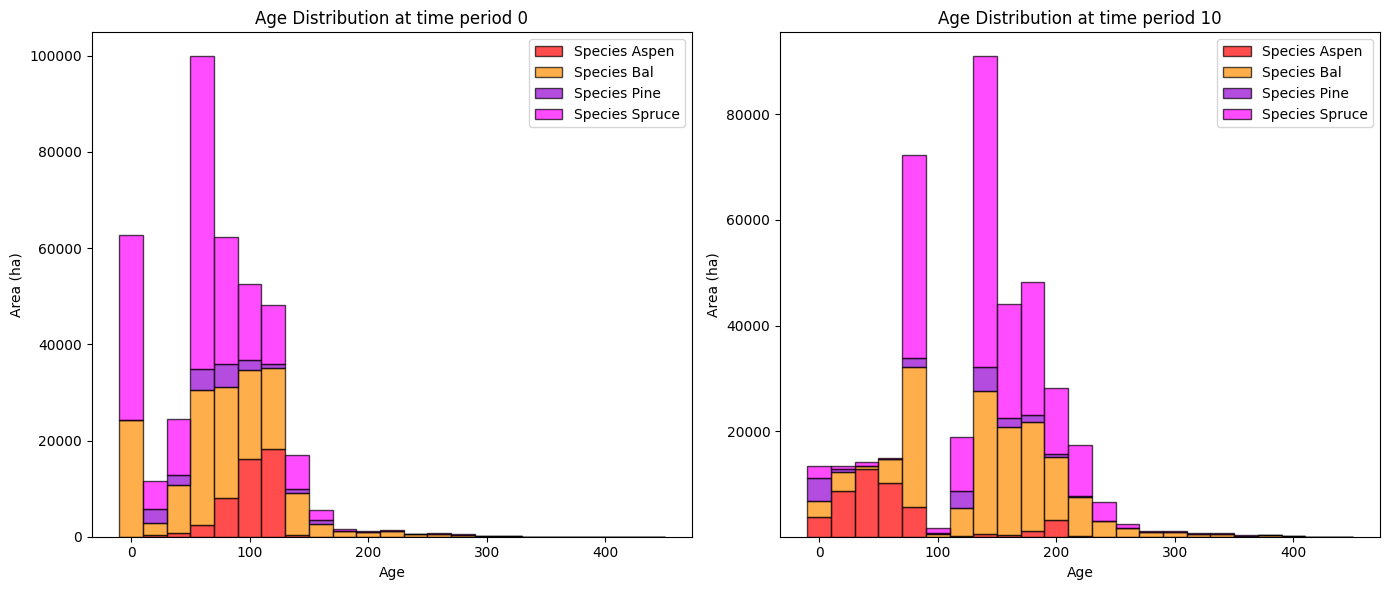

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_80%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688   4909.785142   3964.471454
Pine     602.782616   4103.542075   3500.759459
Bal     4315.588546  41063.081156  36747.492610
Spruce  1072.814408  39923.531263  38850.716855

Overall diversity has **increased** by 83063.44 hectares from time period 0 to time period 10.


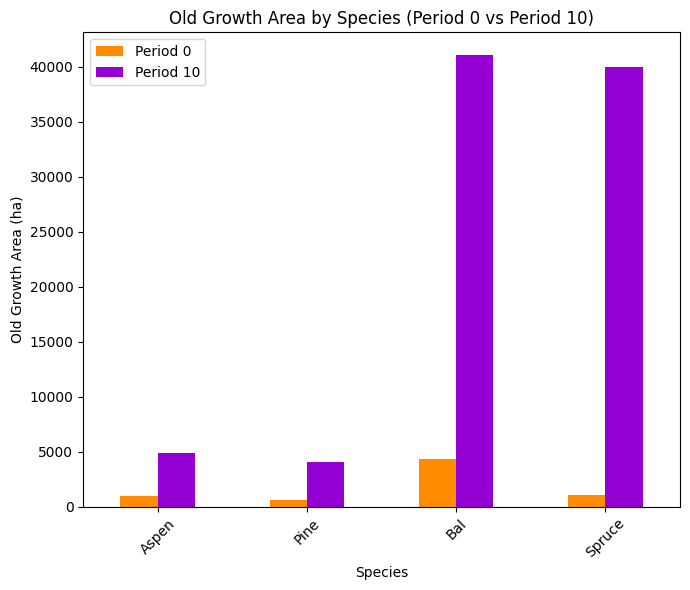

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_80%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.6728

Diversity has **decreased** by 21.20% from time 0 to time 10.


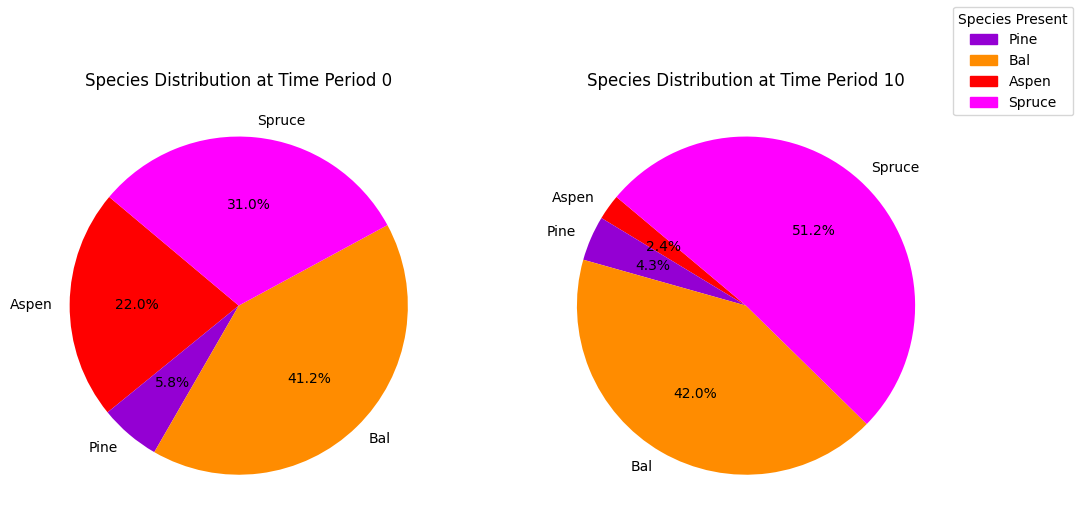

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_80%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x8d629ebf
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.17s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

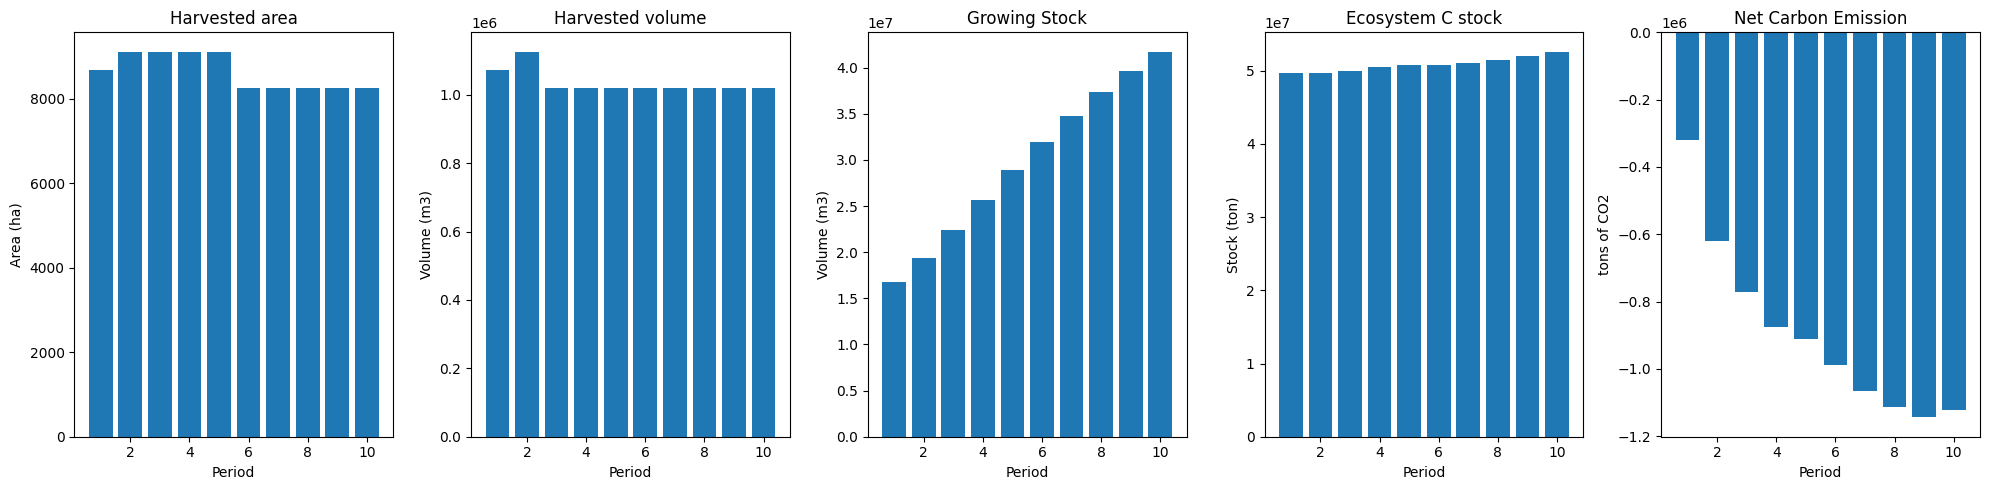

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10945
The economic indicator (the provincial government revenues) is:  373261
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


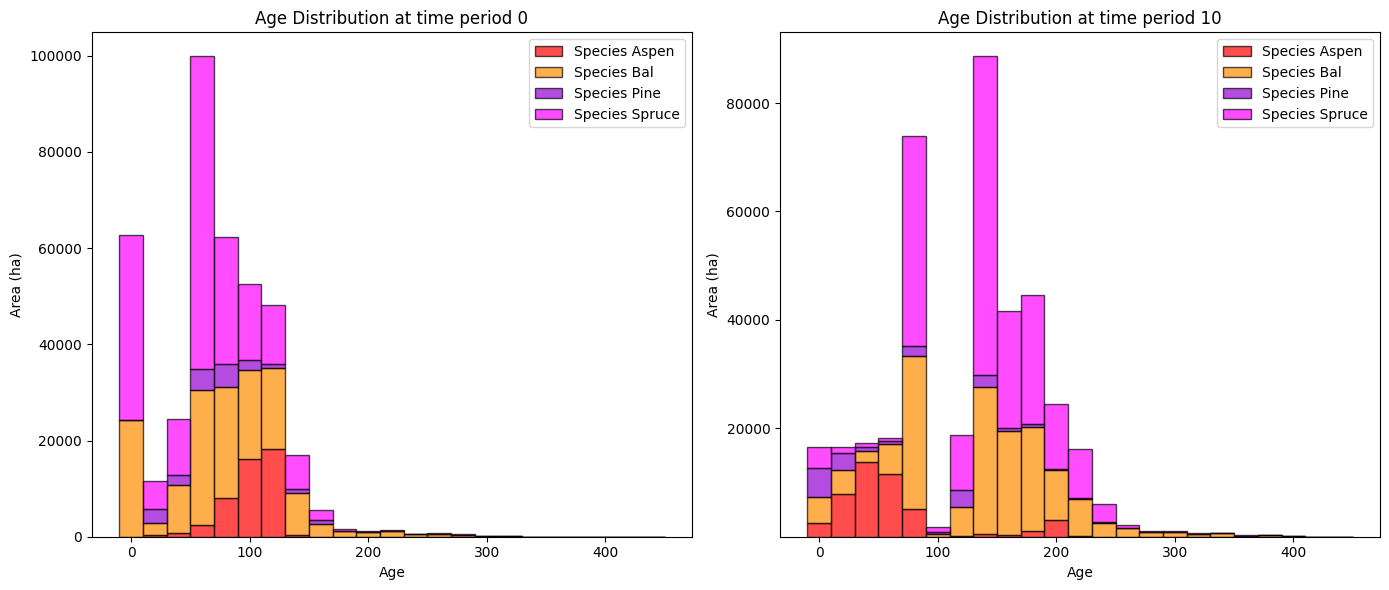

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688   4909.785142   3964.471454
Pine     602.782616   1772.814393   1170.031777
Bal     4315.588546  37139.500575  32823.912029
Spruce  1072.814408  37938.204945  36865.390537

Overall diversity has **increased** by 74823.81 hectares from time period 0 to time period 10.


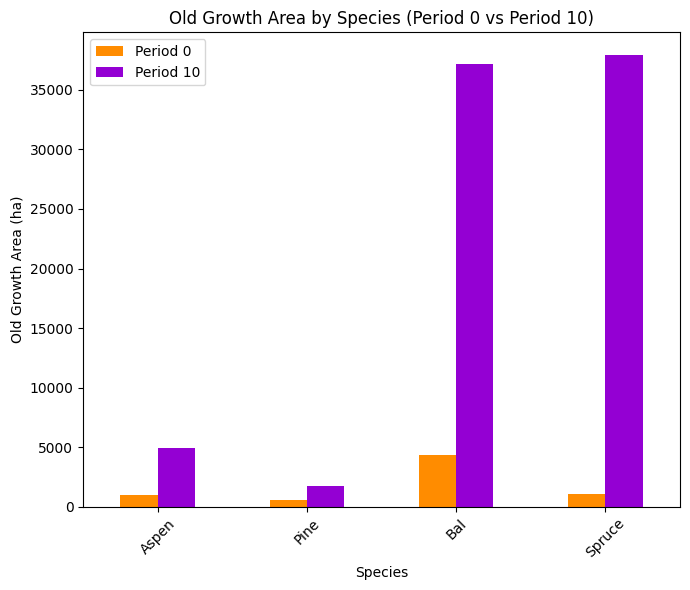

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.6474

Diversity has **decreased** by 23.74% from time 0 to time 10.


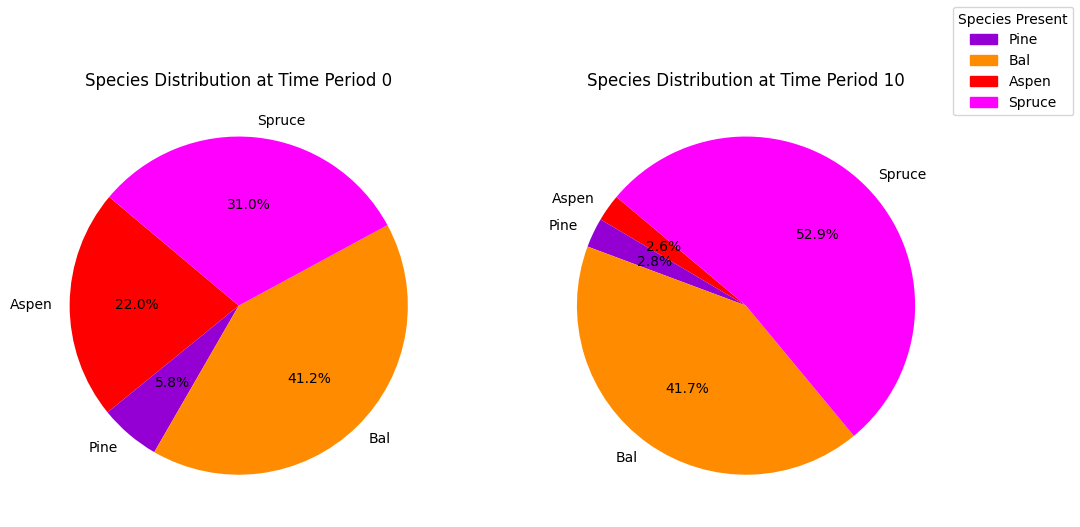

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_species_pie.pdf


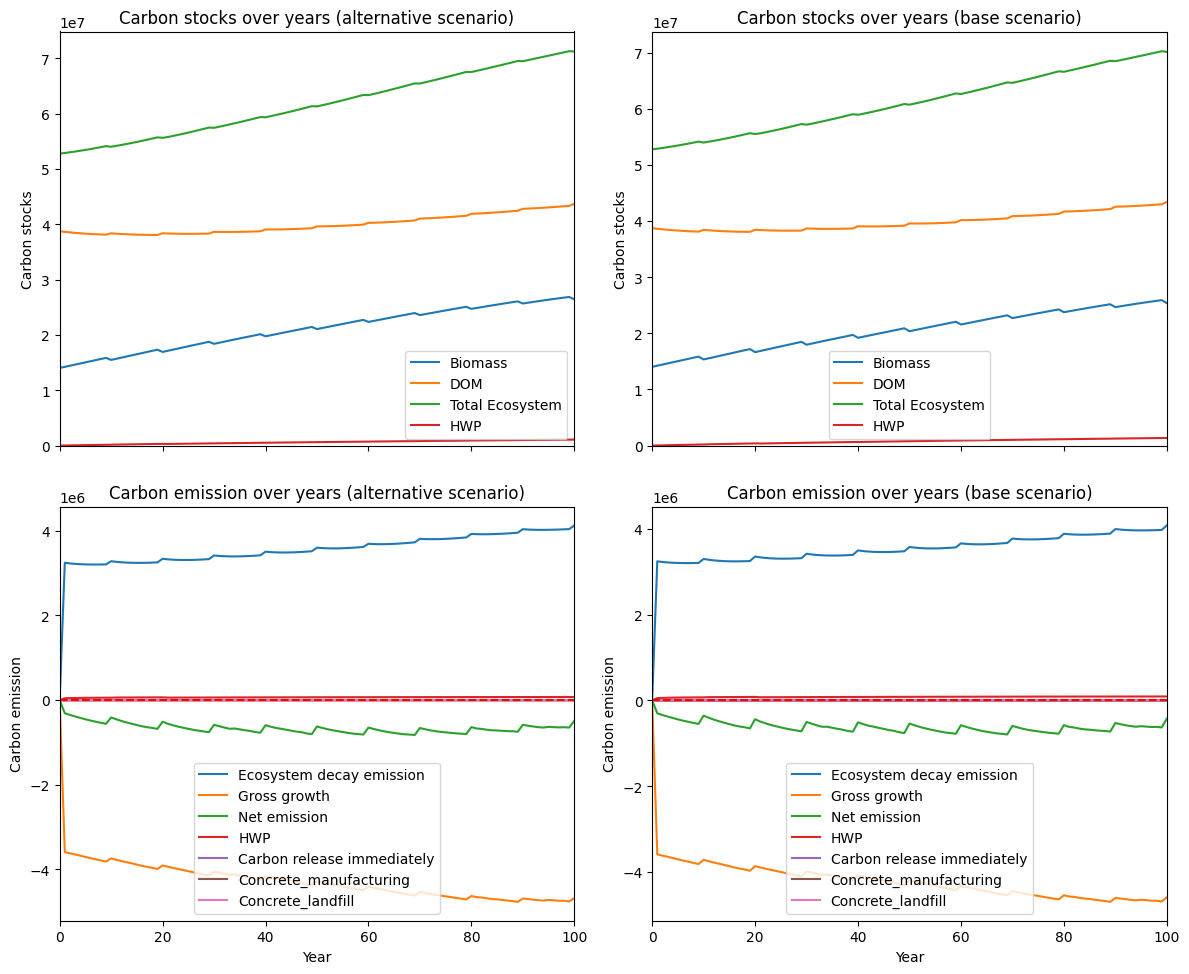

---------------------------------------------------------------------------------------
Net emission difference -796180.0123750563
Net emission base scenario -12566934.189471643
Net emission alternative scenario -11770754.177096587
dollar_per_ton is:  12.559973680034187
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Aspen   0.0     0.000000     0.000000
Pine    0.0  2330.727682  2330.727682
Bal     0.0  3923.580581  3923.580581
Spruce  0.0  1985.326318  1985.326318

Overall, the old growth area has **increased** by 8239.63 hectares in the alternative scenario compared to the base scenario.


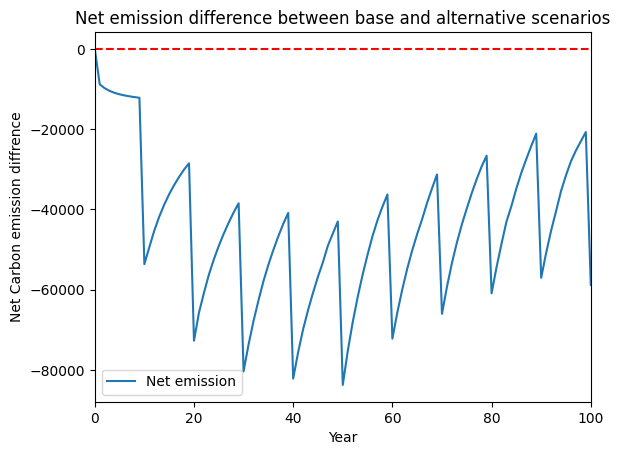

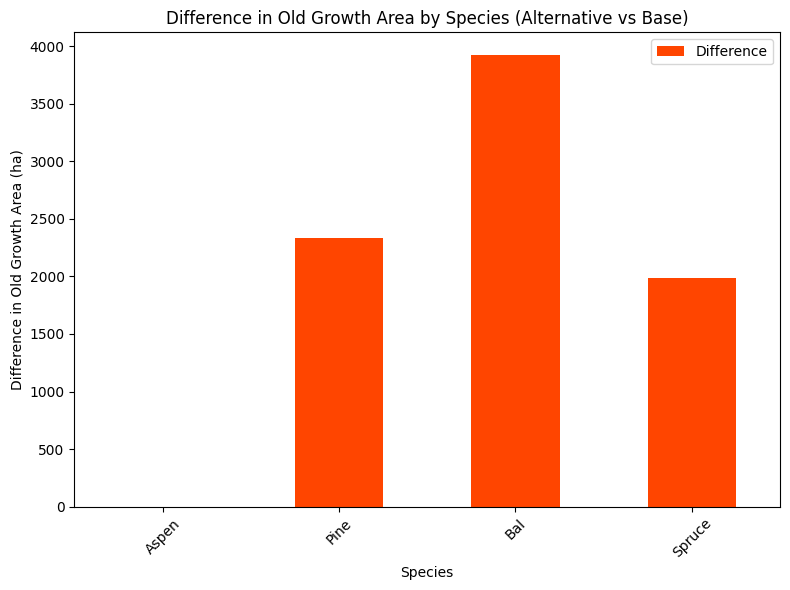

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_min_em_kpi_age_difference.pdf


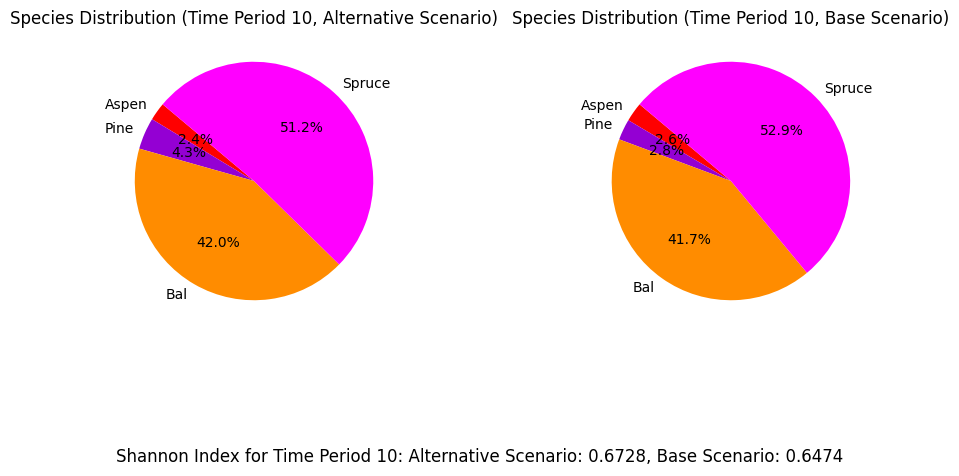

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_min_em_redchrs_AAC_70%...
running the scenario for the Red Chris mining site (70%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xf8a46192
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.13s
Presolved: 1699 rows, 32529 column

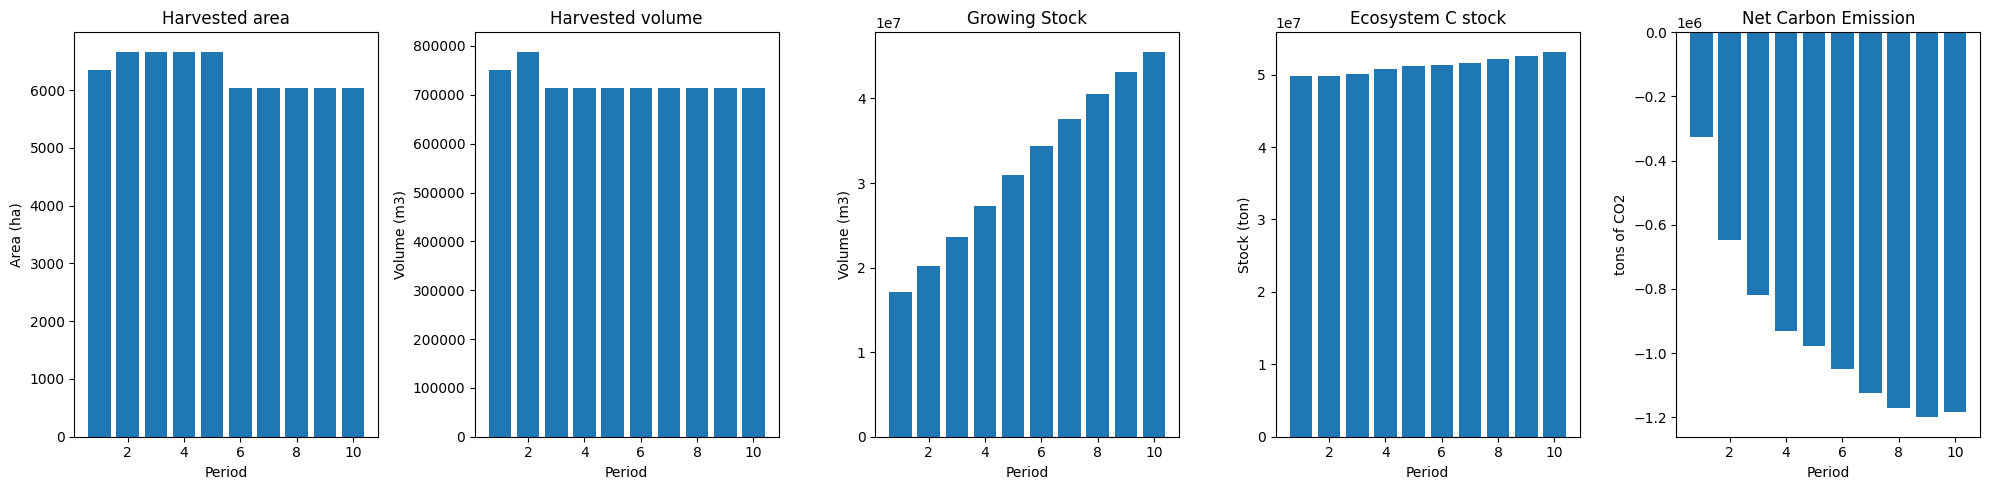

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_70%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7661
The economic indicator (the provincial government revenues) is:  261283
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


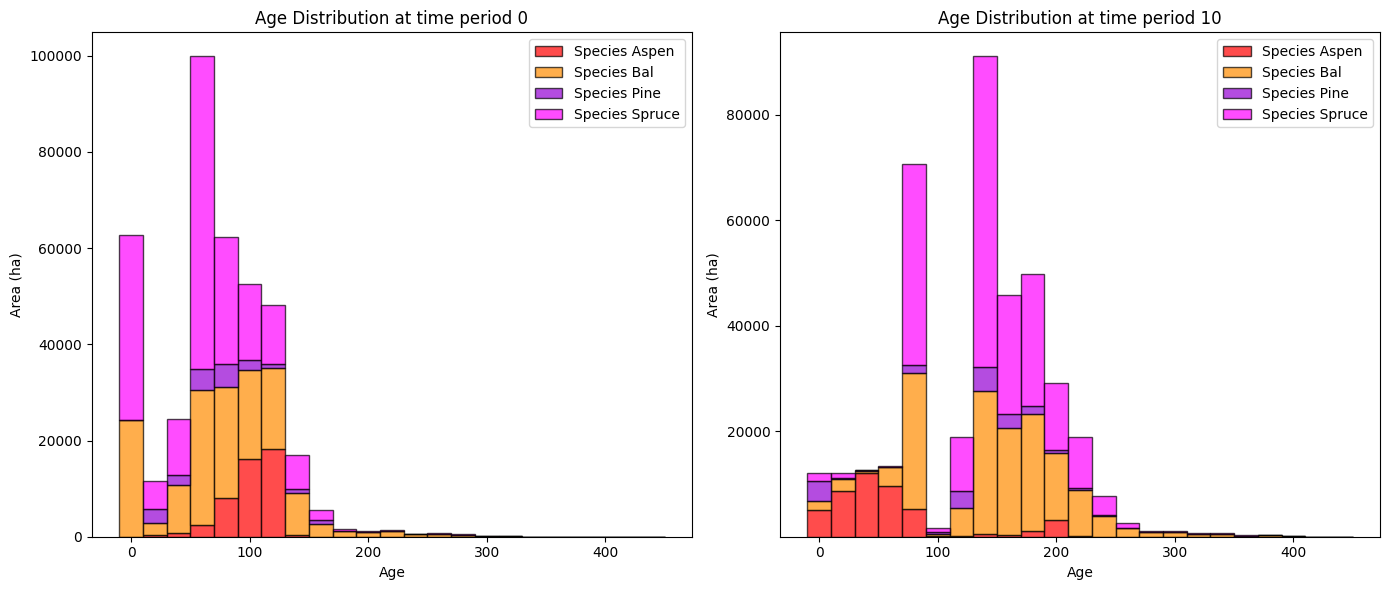

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_70%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688   4909.785142   3964.471454
Pine     602.782616   4737.395443   4134.612827
Bal     4315.588546  45266.794266  40951.205720
Spruce  1072.814408  40370.556463  39297.742055

Overall diversity has **increased** by 88348.03 hectares from time period 0 to time period 10.


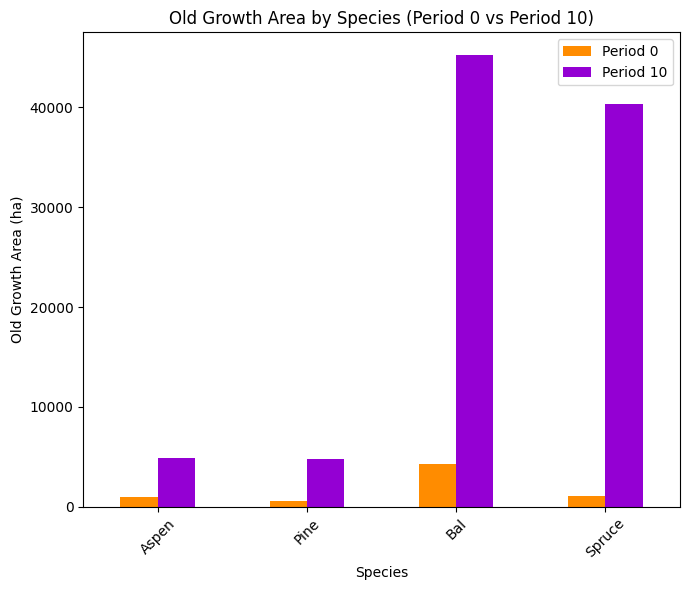

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_70%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.6763

Diversity has **decreased** by 20.86% from time 0 to time 10.


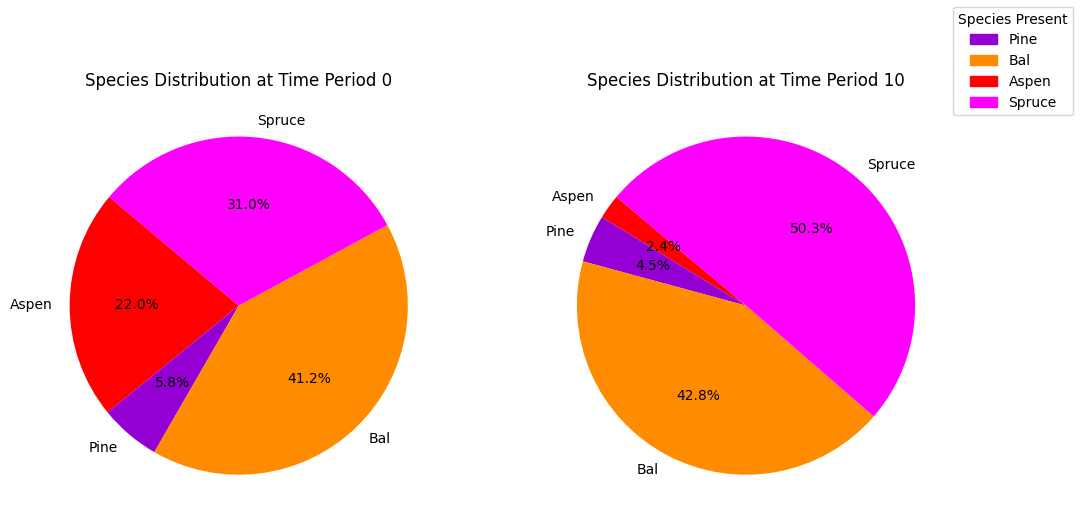

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_70%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x8d629ebf
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.13s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

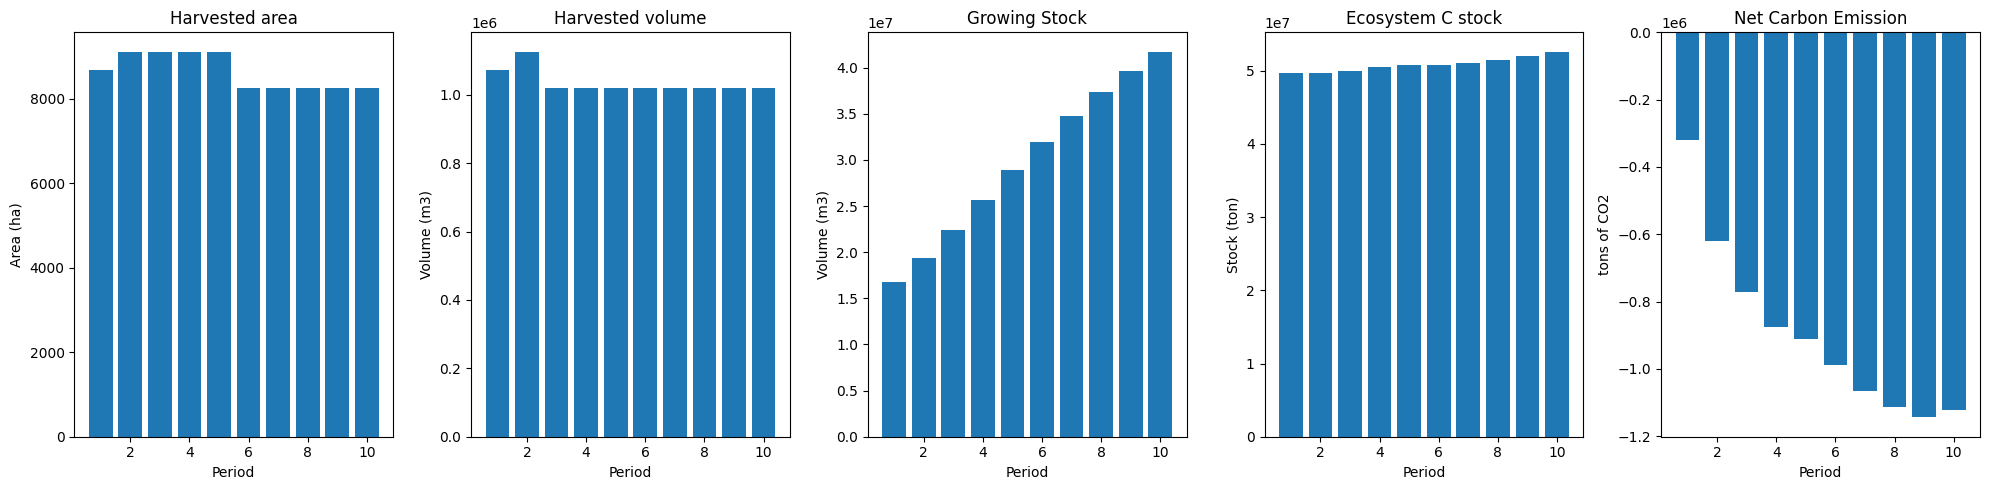

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10945
The economic indicator (the provincial government revenues) is:  373261
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


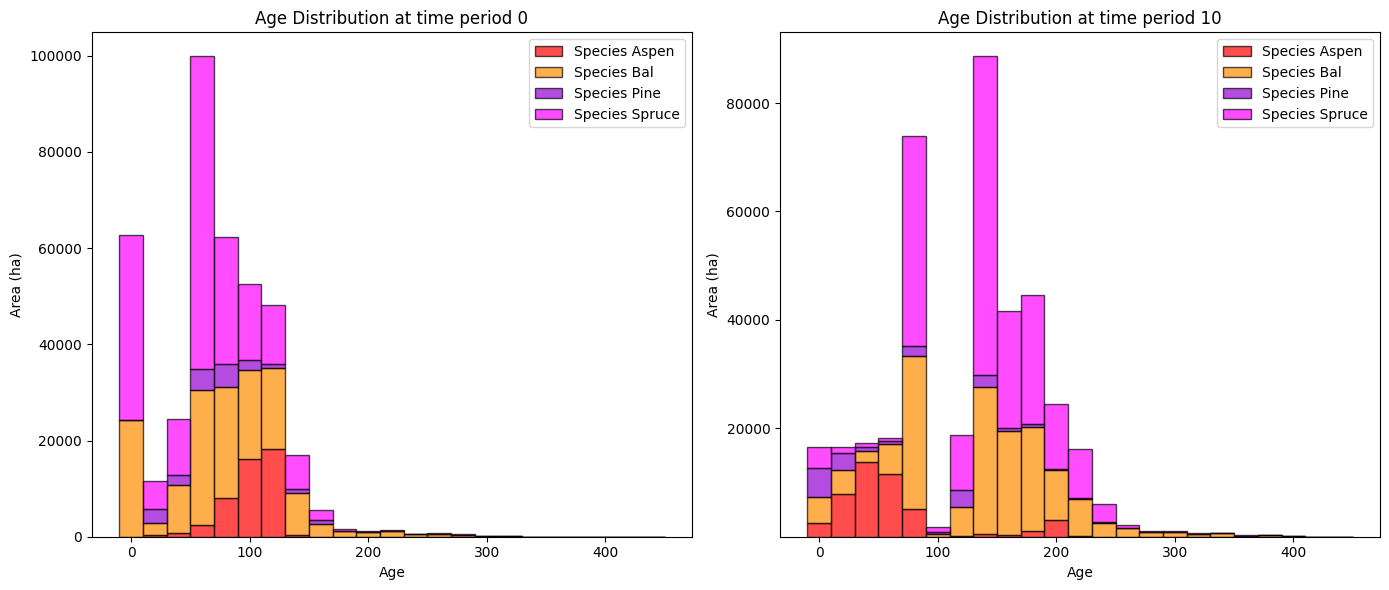

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688   4909.785142   3964.471454
Pine     602.782616   1772.814393   1170.031777
Bal     4315.588546  37139.500575  32823.912029
Spruce  1072.814408  37938.204945  36865.390537

Overall diversity has **increased** by 74823.81 hectares from time period 0 to time period 10.


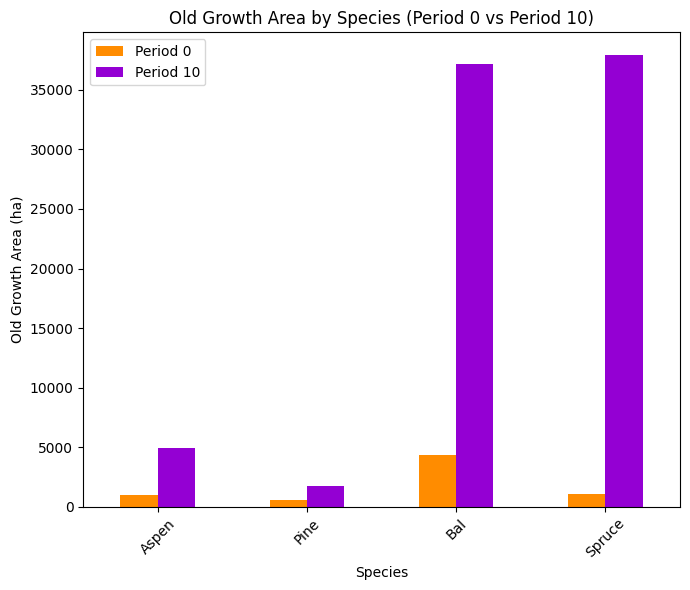

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.6474

Diversity has **decreased** by 23.74% from time 0 to time 10.


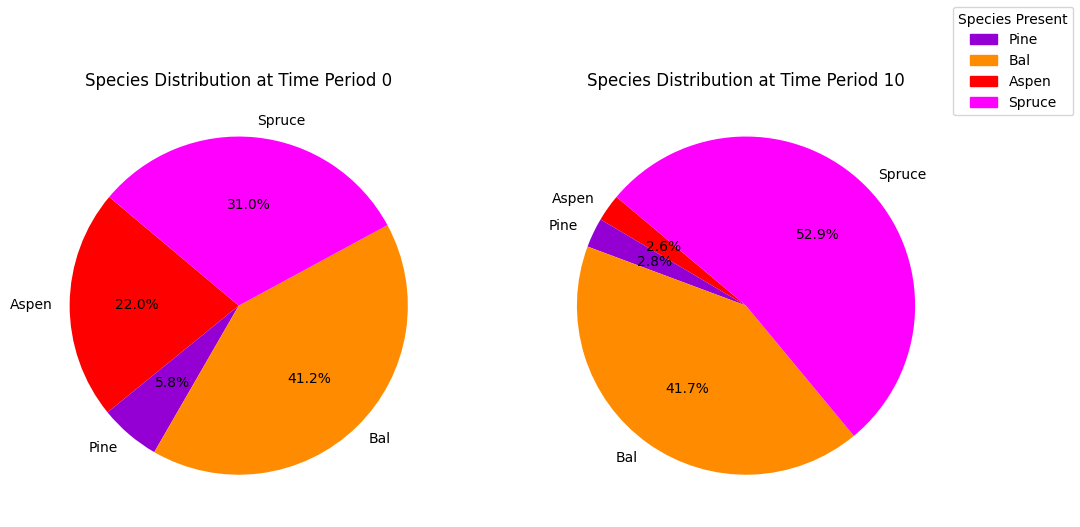

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_species_pie.pdf


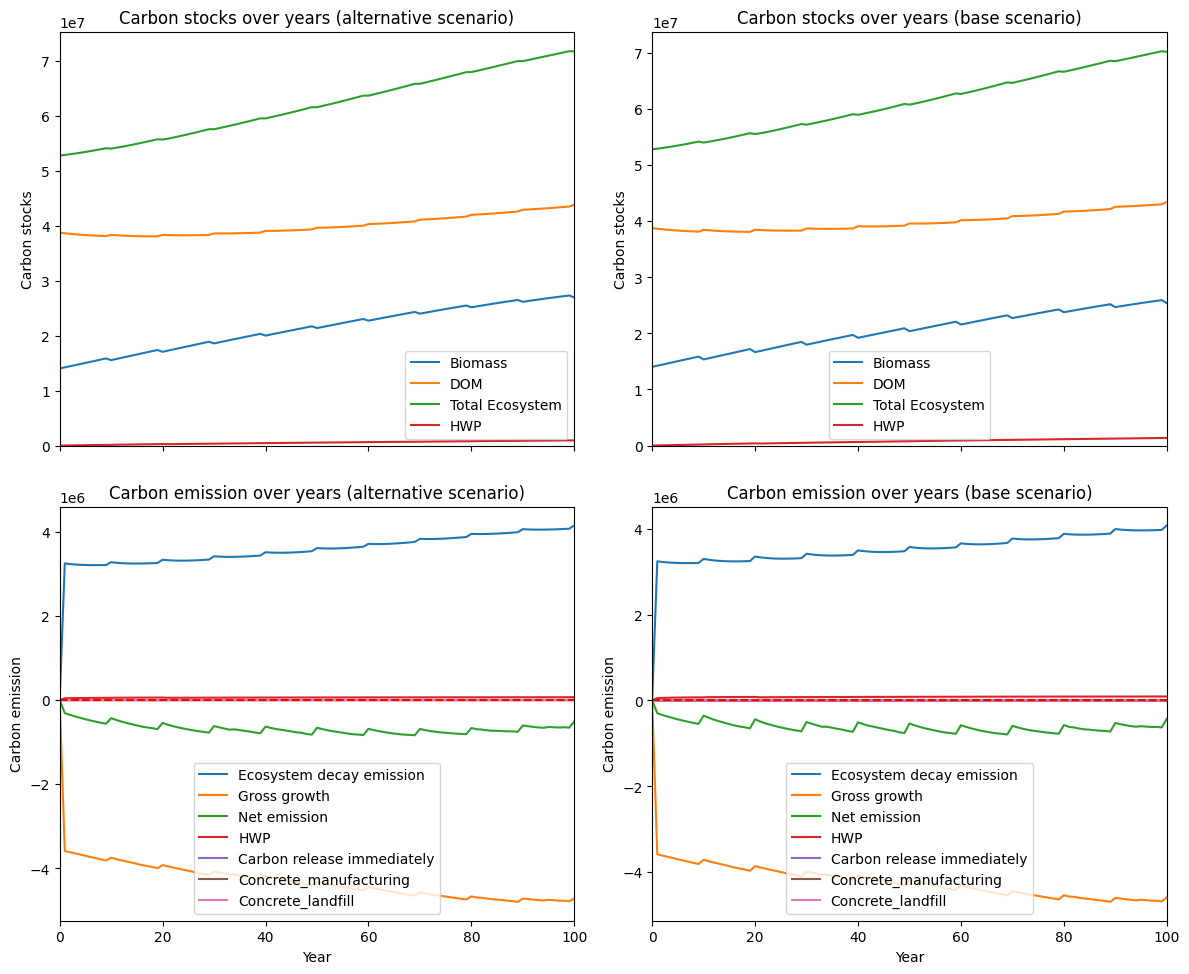

---------------------------------------------------------------------------------------
Net emission difference -1171923.964182986
Net emission base scenario -12942678.14127957
Net emission alternative scenario -11770754.177096587
dollar_per_ton is:  8.532976801930628
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Aspen   0.0     0.000000     0.000000
Pine    0.0  2964.581050  2964.581050
Bal     0.0  8127.293692  8127.293692
Spruce  0.0  2432.351518  2432.351518

Overall, the old growth area has **increased** by 13524.23 hectares in the alternative scenario compared to the base scenario.


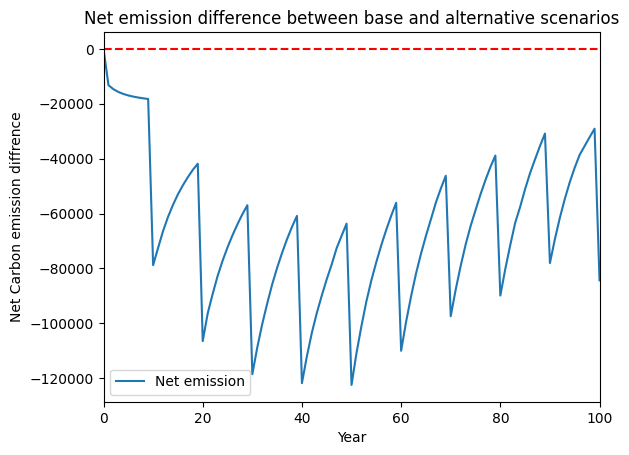

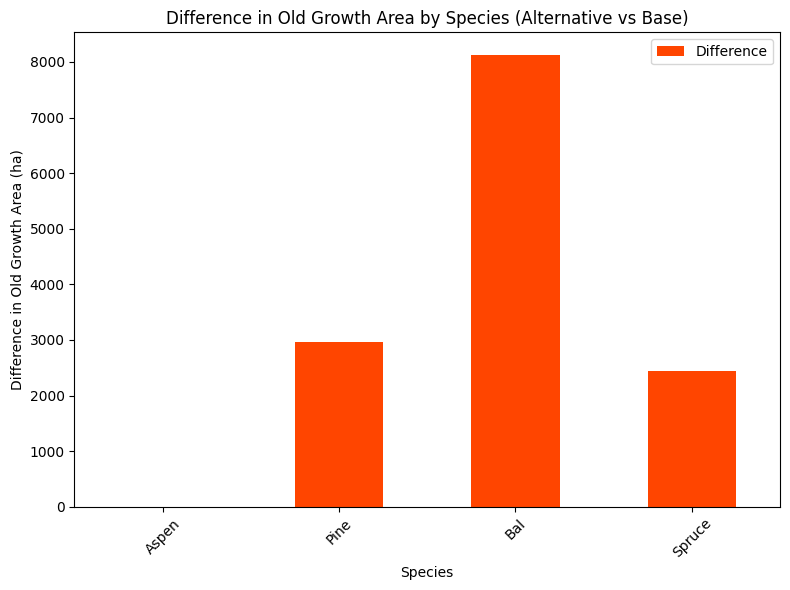

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_min_em_kpi_age_difference.pdf


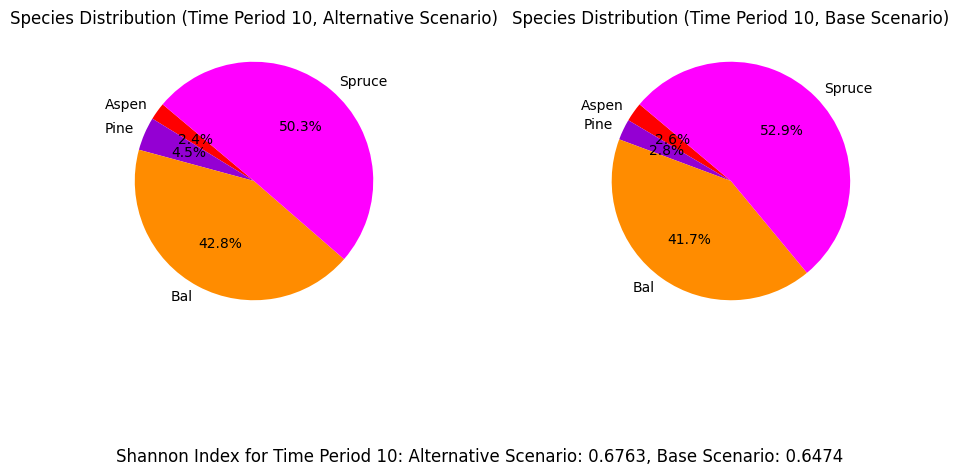

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_min_em_redchrs_AAC_60%...
running the scenario for the Red Chris mining site (60%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xc05503c1
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.13s
Presolved: 1699 rows, 32529 column

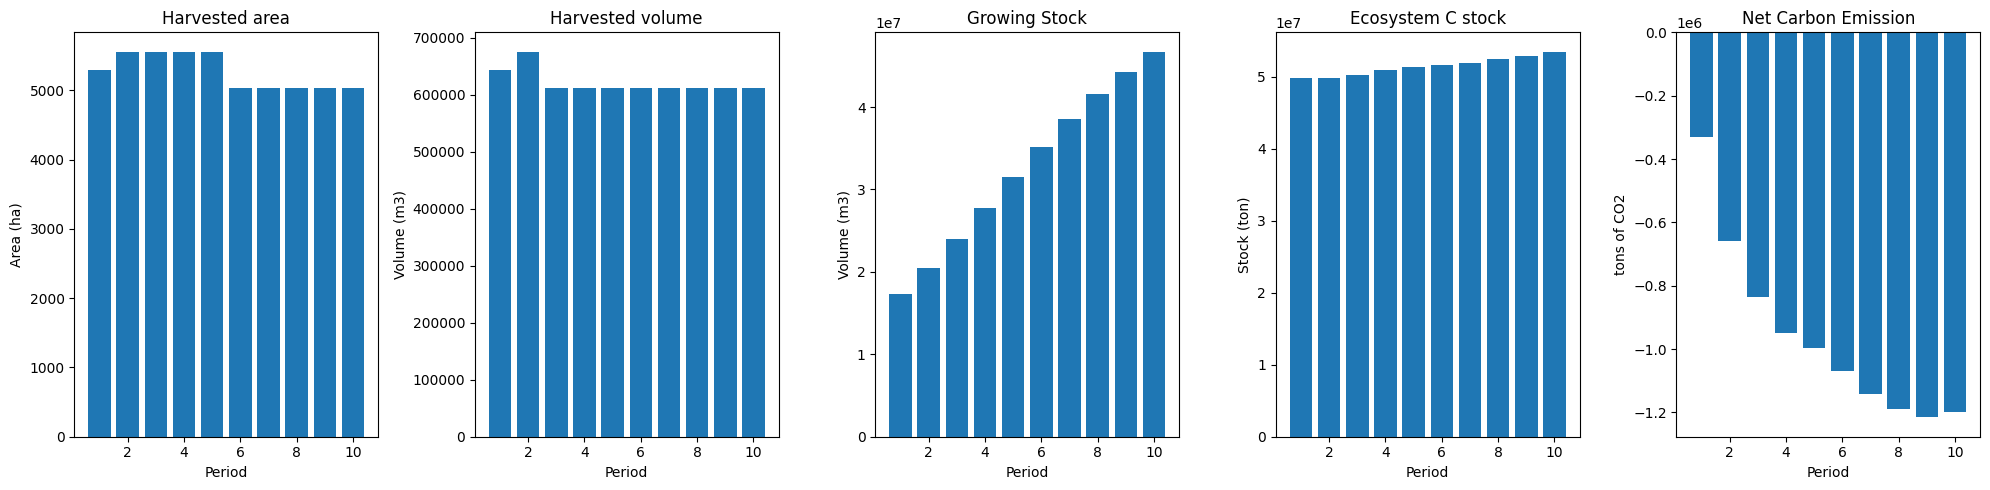

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_60%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  6567
The economic indicator (the provincial government revenues) is:  223956
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


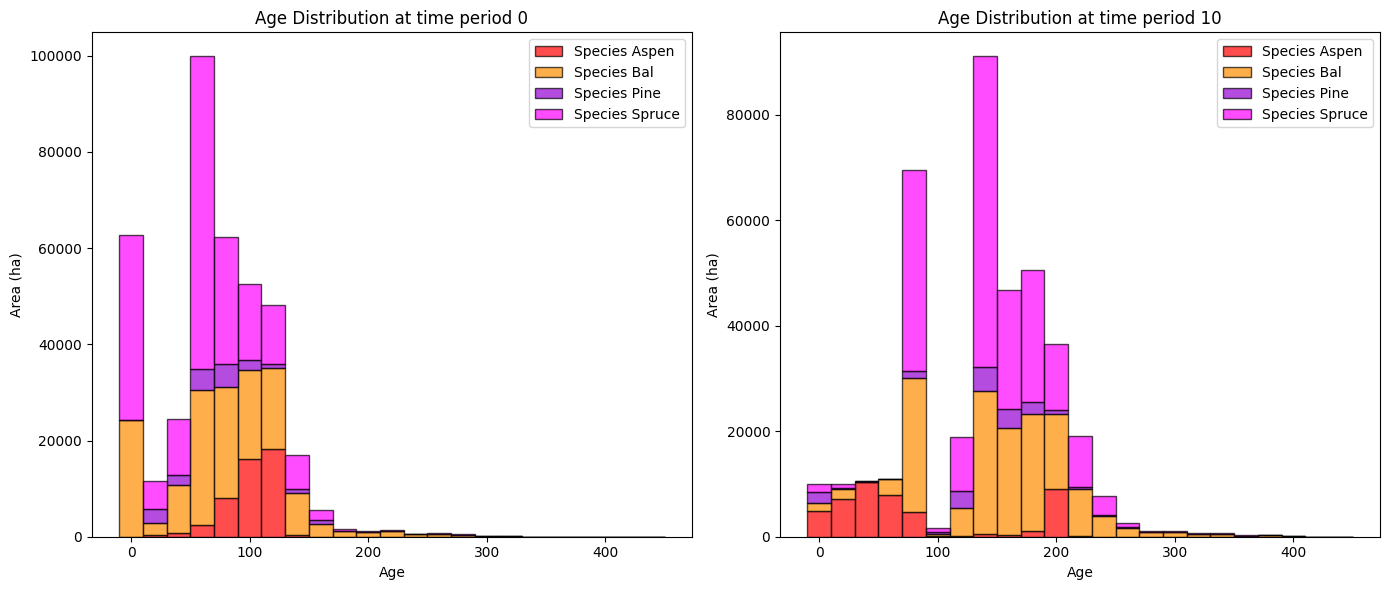

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_60%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  10795.609503   9850.295815
Pine     602.782616   6130.758207   5527.975590
Bal     4315.588546  46730.232588  42414.644042
Spruce  1072.814408  40416.753086  39343.938678

Overall diversity has **increased** by 97136.85 hectares from time period 0 to time period 10.


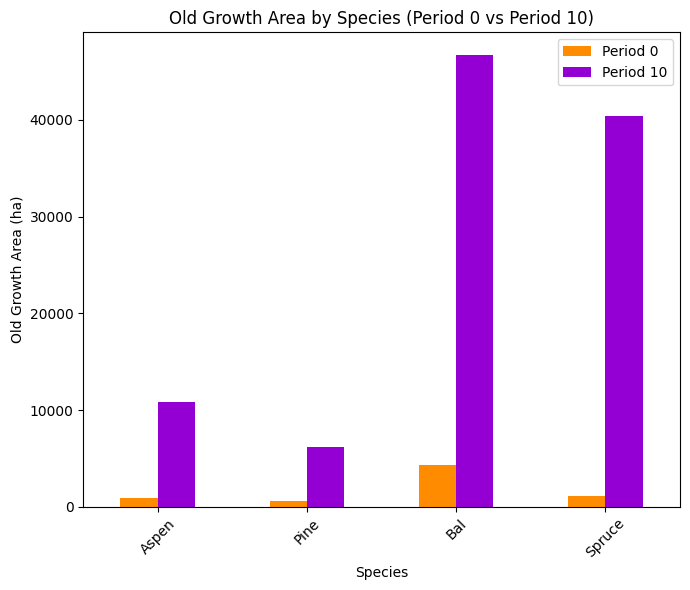

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_60%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.7074

Diversity has **decreased** by 17.74% from time 0 to time 10.


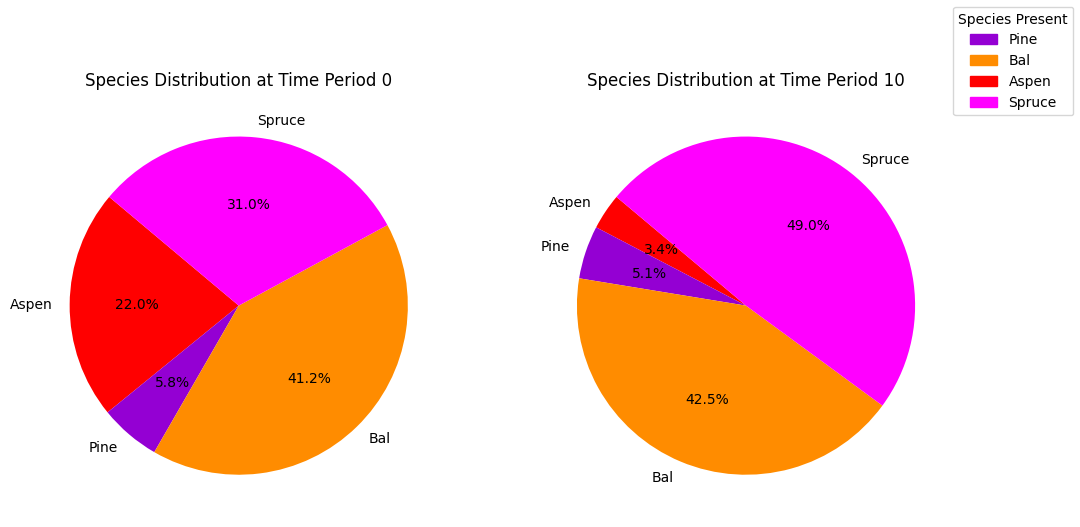

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_60%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x8d629ebf
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.13s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

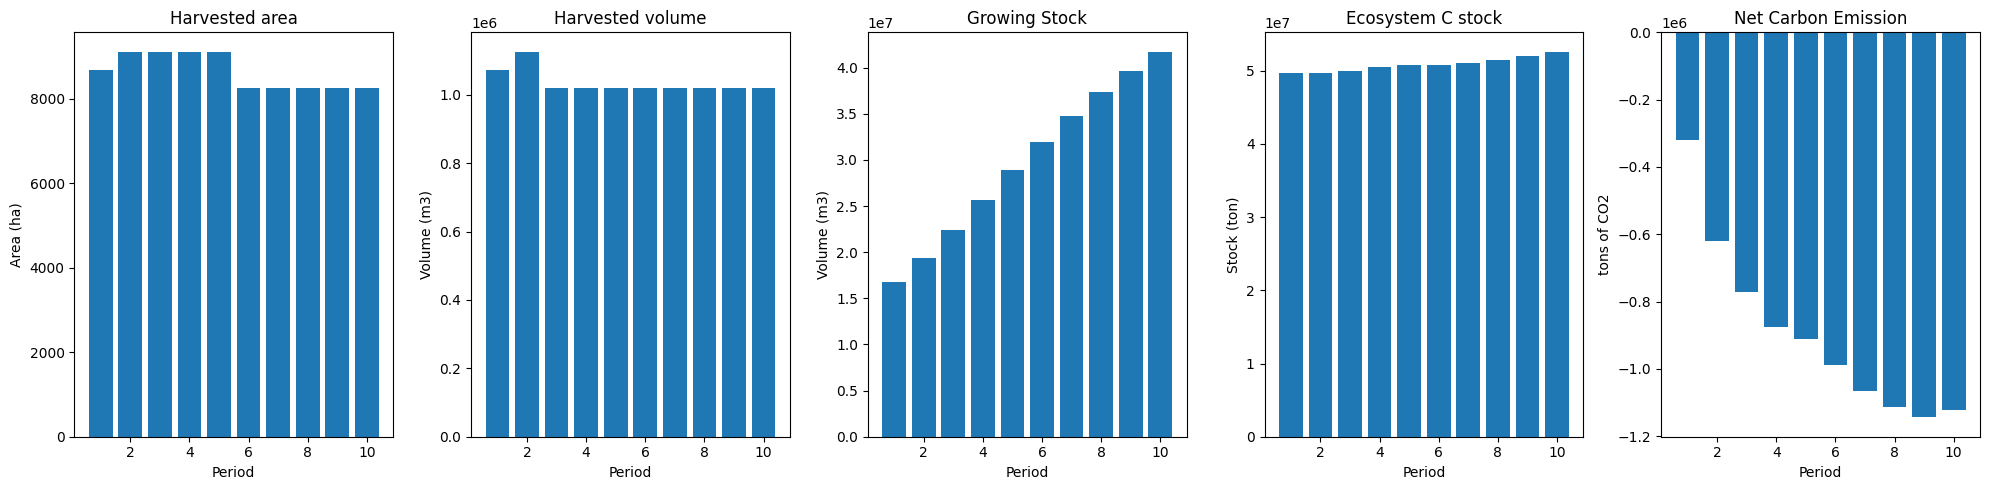

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10945
The economic indicator (the provincial government revenues) is:  373261
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


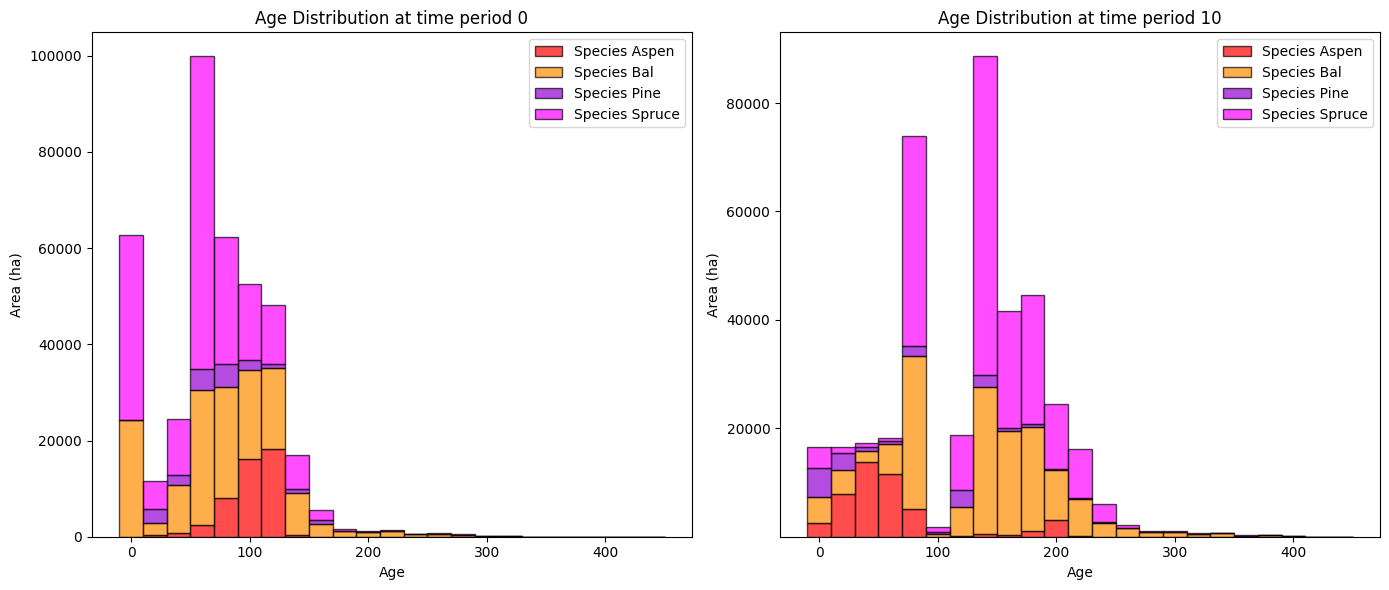

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688   4909.785142   3964.471454
Pine     602.782616   1772.814393   1170.031777
Bal     4315.588546  37139.500575  32823.912029
Spruce  1072.814408  37938.204945  36865.390537

Overall diversity has **increased** by 74823.81 hectares from time period 0 to time period 10.


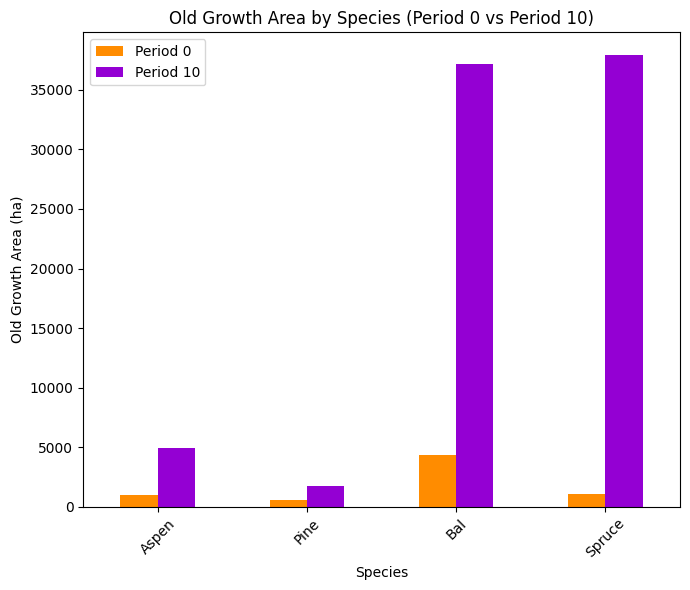

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.6474

Diversity has **decreased** by 23.74% from time 0 to time 10.


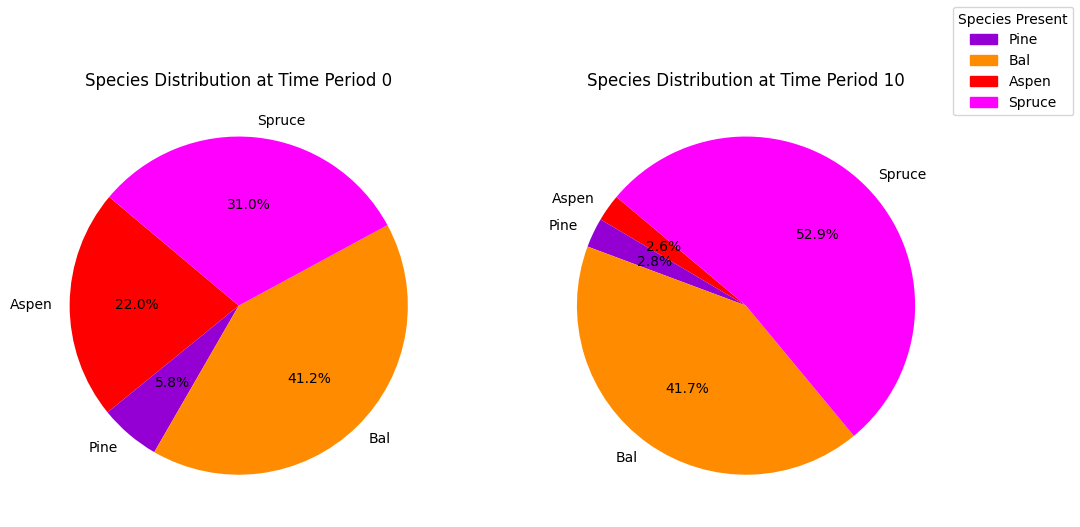

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_species_pie.pdf


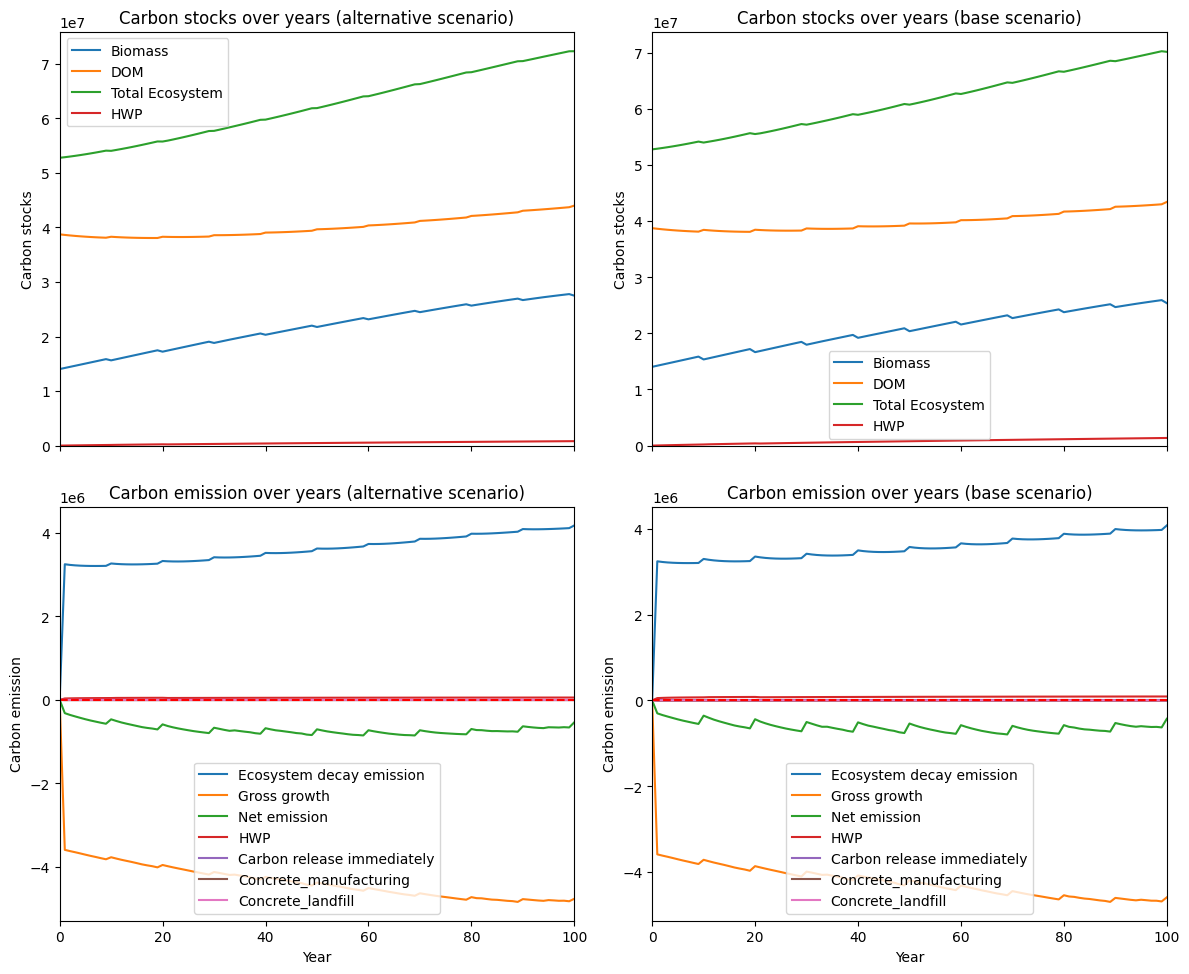

---------------------------------------------------------------------------------------
Net emission difference -1616625.3384568233
Net emission base scenario -13387379.515553411
Net emission alternative scenario -11770754.177096587
dollar_per_ton is:  6.185725141204125
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Aspen   0.0  5885.824361  5885.824361
Pine    0.0  4357.943813  4357.943813
Bal     0.0  9590.732013  9590.732013
Spruce  0.0  2478.548142  2478.548142

Overall, the old growth area has **increased** by 22313.05 hectares in the alternative scenario compared to the base scenario.


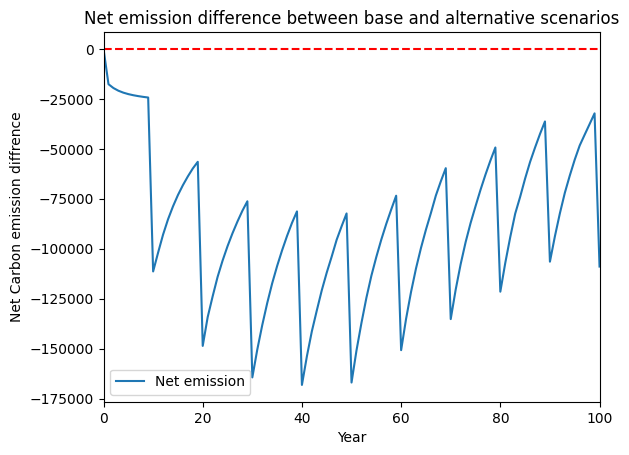

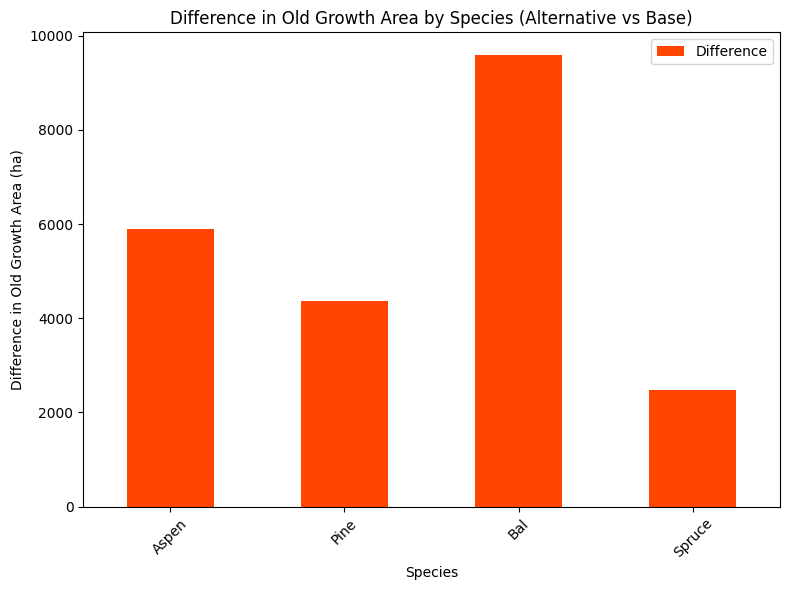

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_min_em_kpi_age_difference.pdf


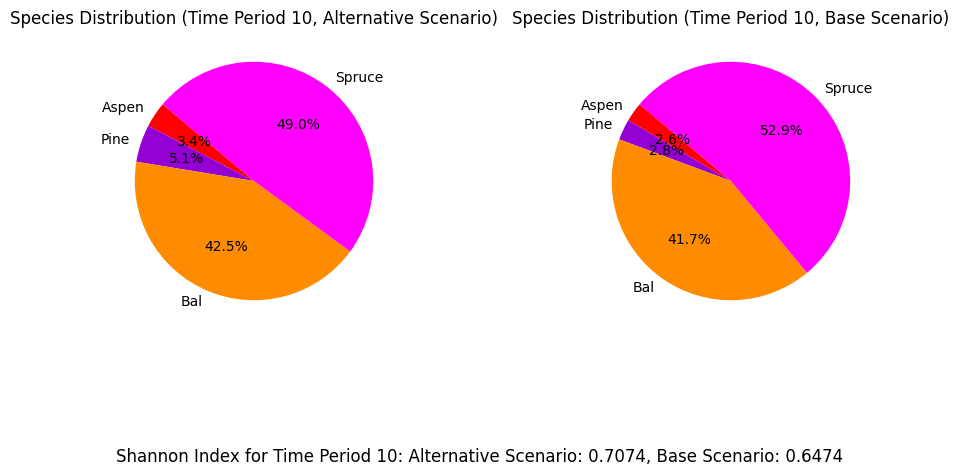

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_min_em_redchrs_AAC_50%...
running the scenario for the Red Chris mining site (50%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xadb115c9
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.13s
Presolved: 1699 rows, 32529 column

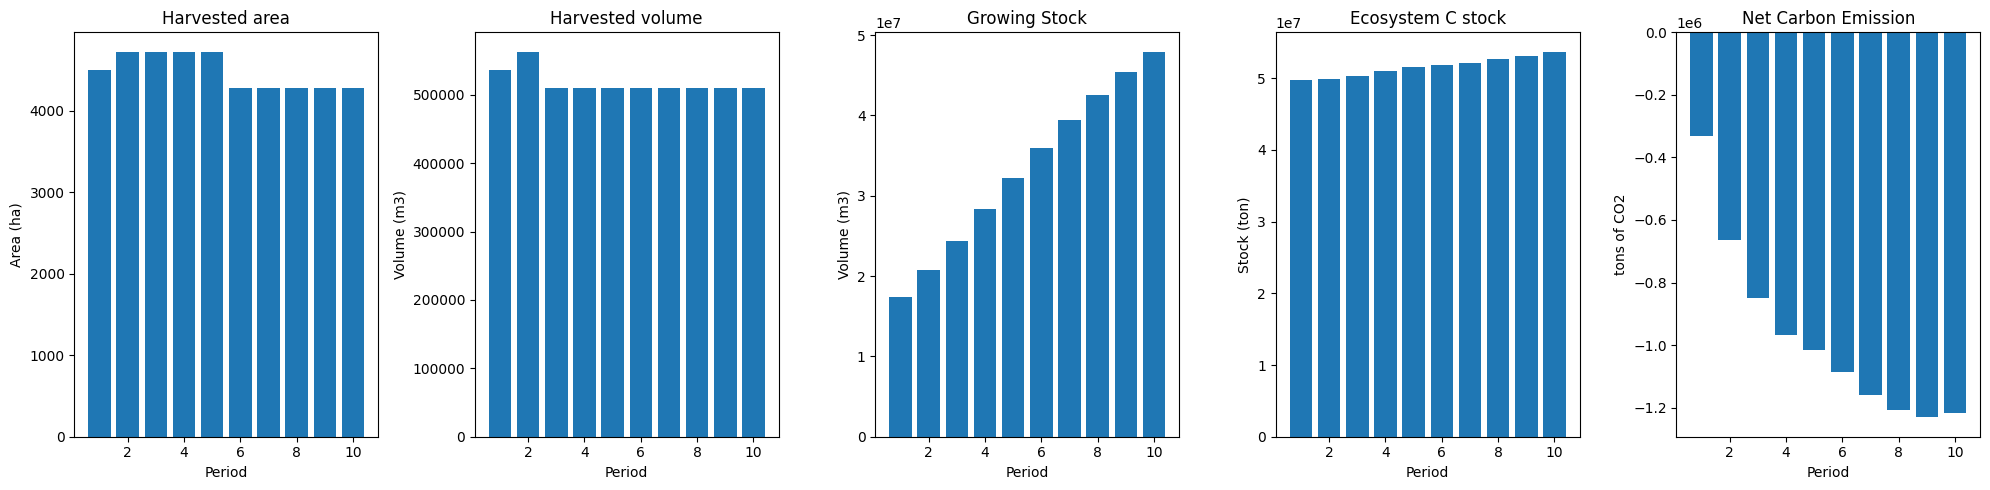

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_50%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  5472
The economic indicator (the provincial government revenues) is:  186630
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


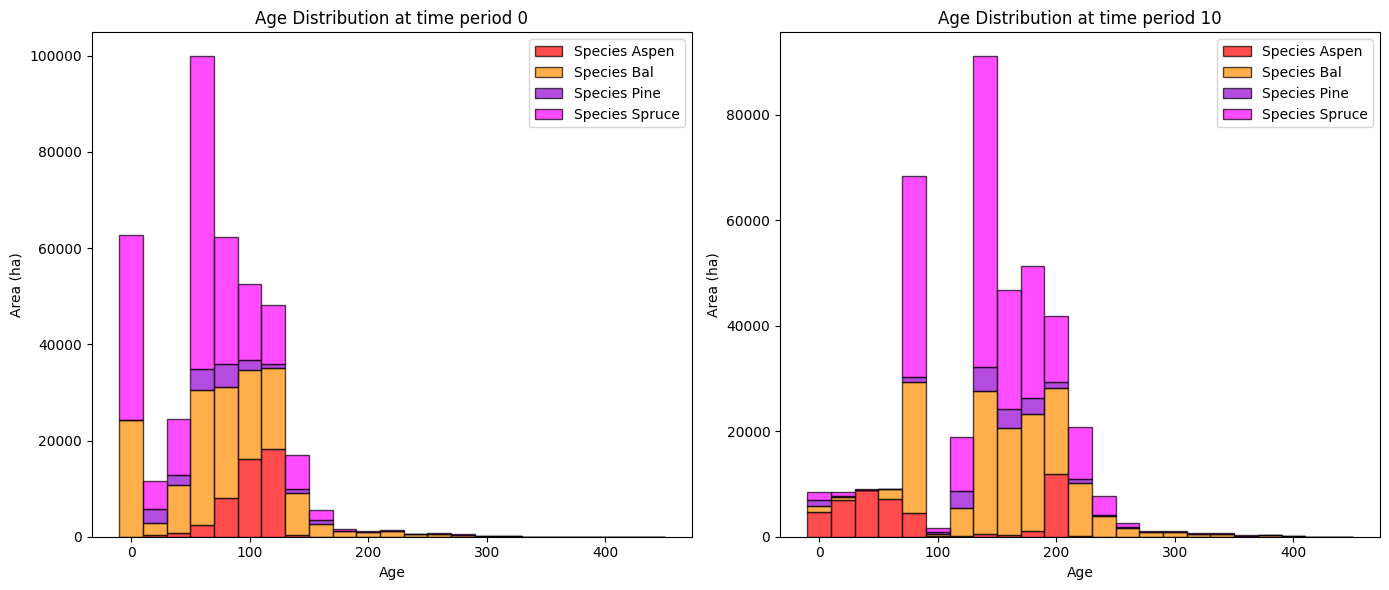

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_50%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  13617.325195  12672.011508
Pine     602.782616   7430.774363   6827.991747
Bal     4315.588546  50023.841817  45708.253271
Spruce  1072.814408  40445.696984  39372.882576

Overall diversity has **increased** by 104581.14 hectares from time period 0 to time period 10.


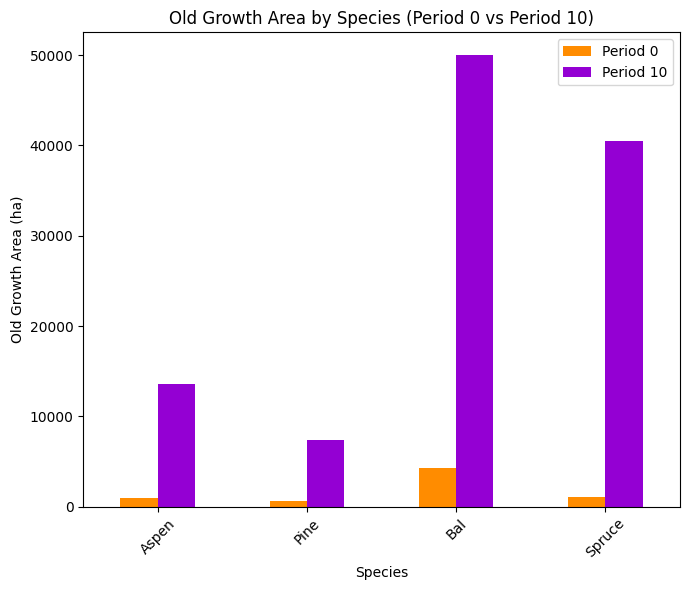

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_50%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.7208

Diversity has **decreased** by 16.41% from time 0 to time 10.


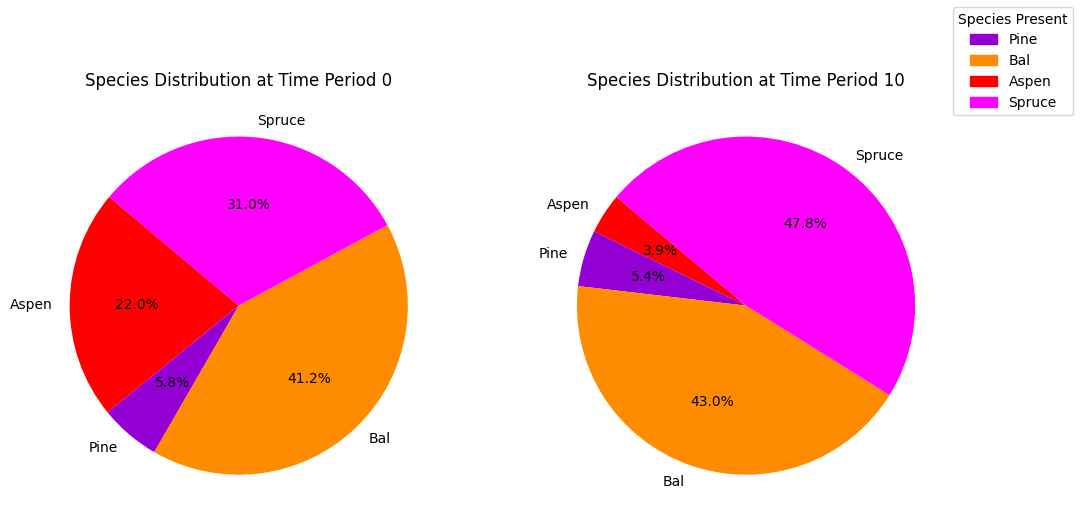

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_50%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x8d629ebf
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.13s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

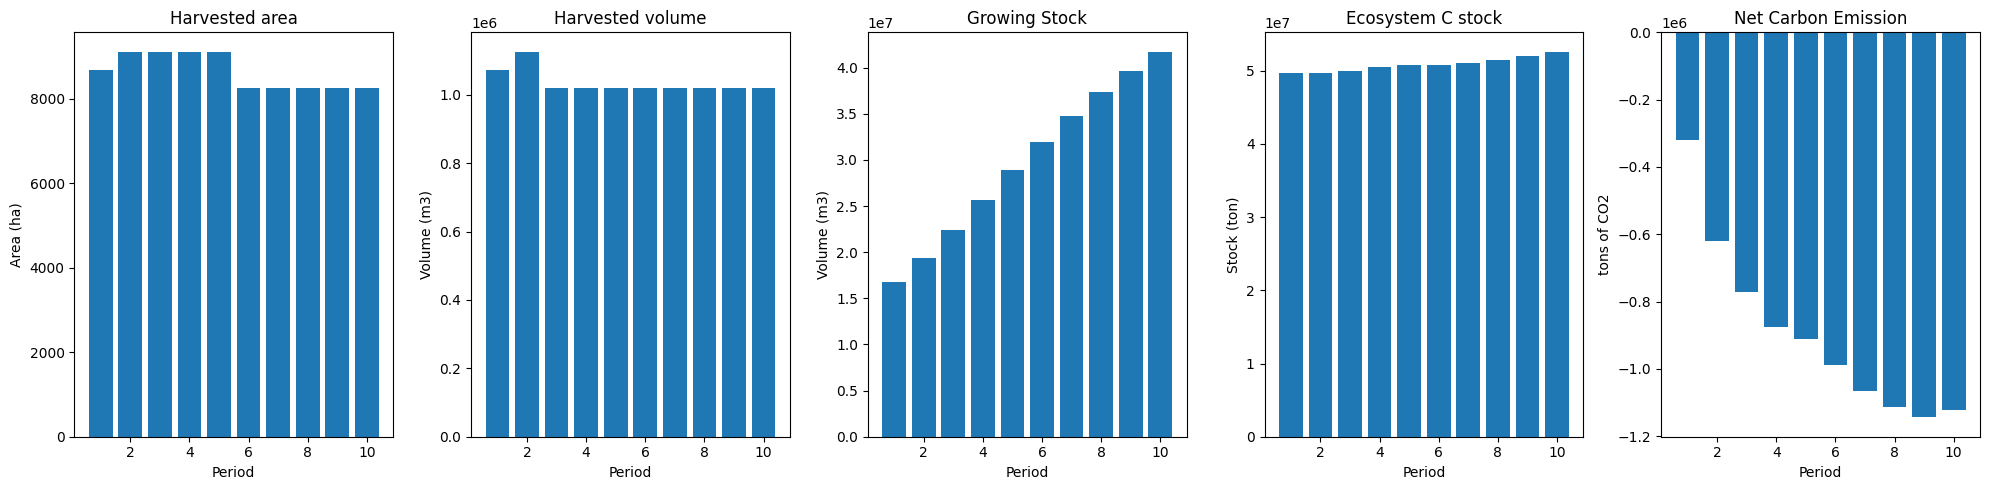

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10945
The economic indicator (the provincial government revenues) is:  373261
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


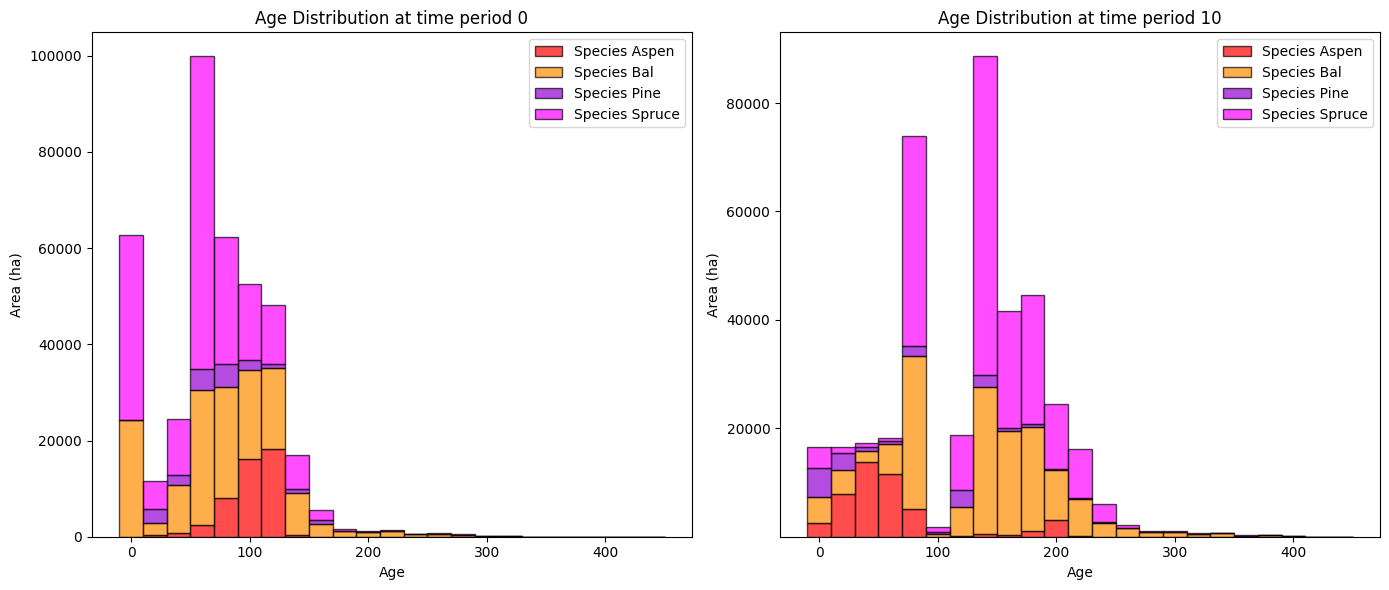

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688   4909.785142   3964.471454
Pine     602.782616   1772.814393   1170.031777
Bal     4315.588546  37139.500575  32823.912029
Spruce  1072.814408  37938.204945  36865.390537

Overall diversity has **increased** by 74823.81 hectares from time period 0 to time period 10.


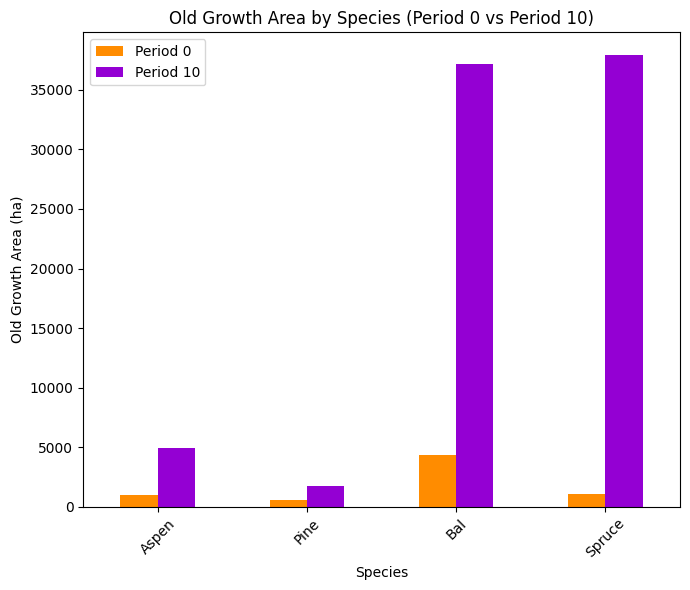

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.6474

Diversity has **decreased** by 23.74% from time 0 to time 10.


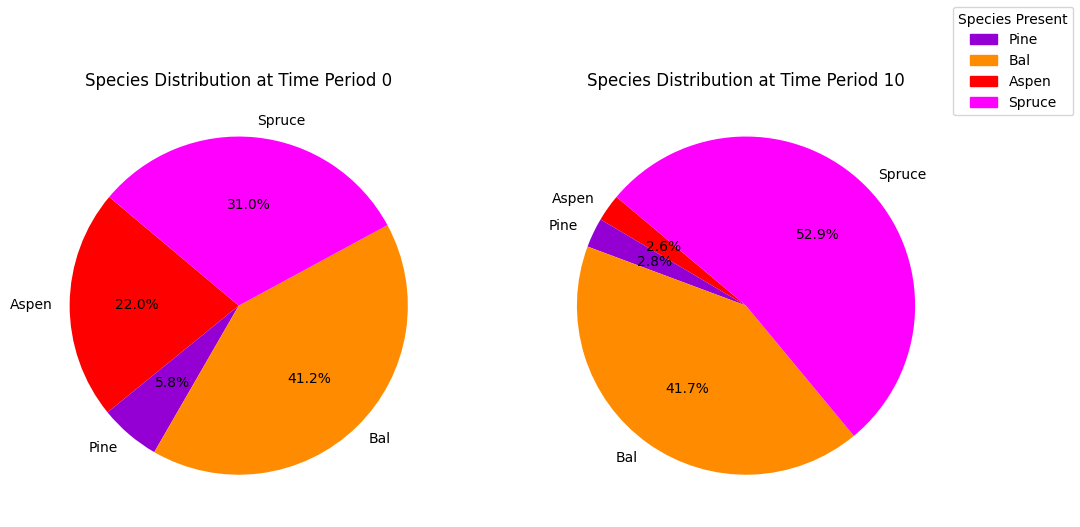

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_species_pie.pdf


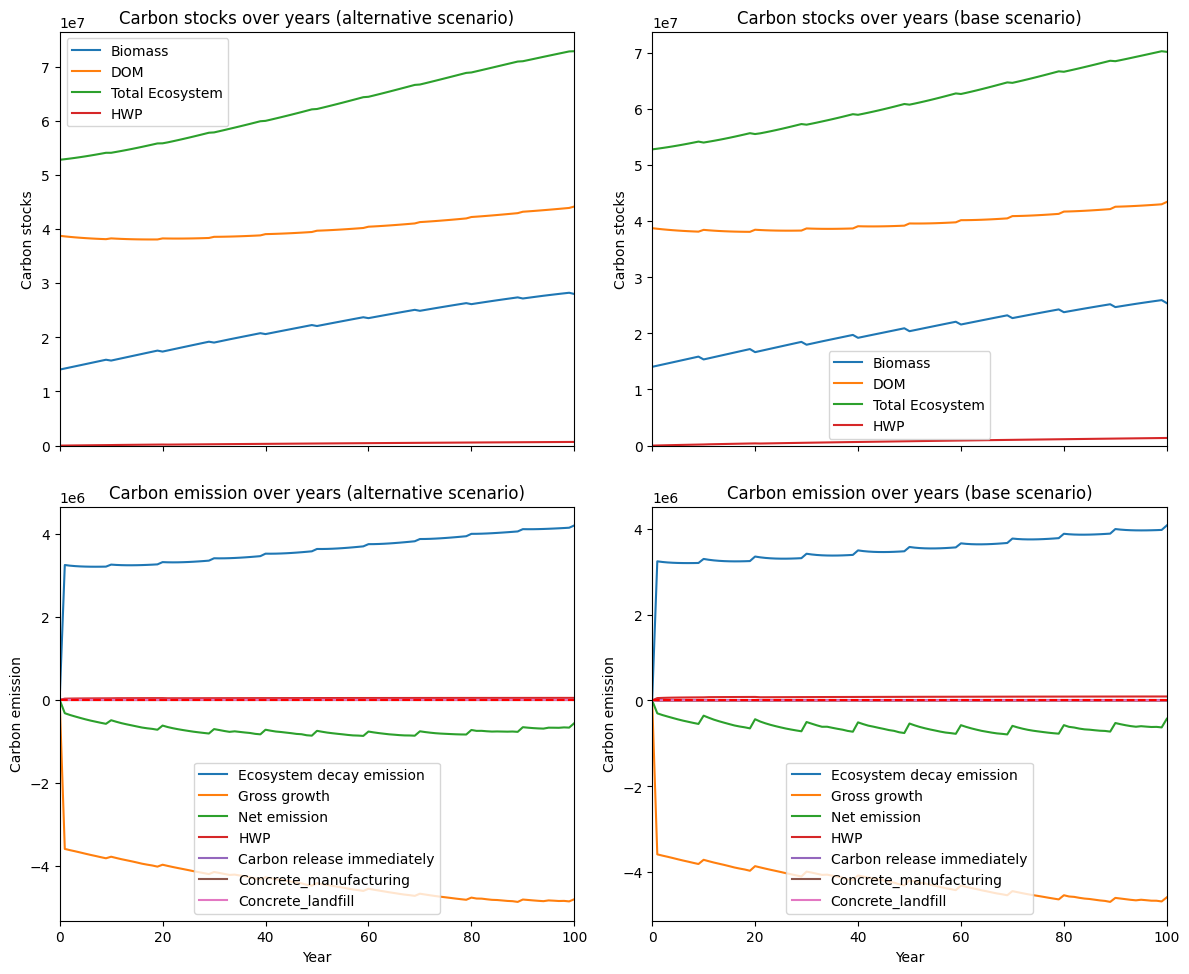

---------------------------------------------------------------------------------------
Net emission difference -1981822.0800754554
Net emission base scenario -13752576.25717204
Net emission alternative scenario -11770754.177096587
dollar_per_ton is:  5.045861634369954
Comparison of Old Growth Areas (Alternative - Base)
          0            10    Difference
Aspen   0.0   8707.540054   8707.540054
Pine    0.0   5657.959970   5657.959970
Bal     0.0  12884.341242  12884.341242
Spruce  0.0   2507.492039   2507.492039

Overall, the old growth area has **increased** by 29757.33 hectares in the alternative scenario compared to the base scenario.


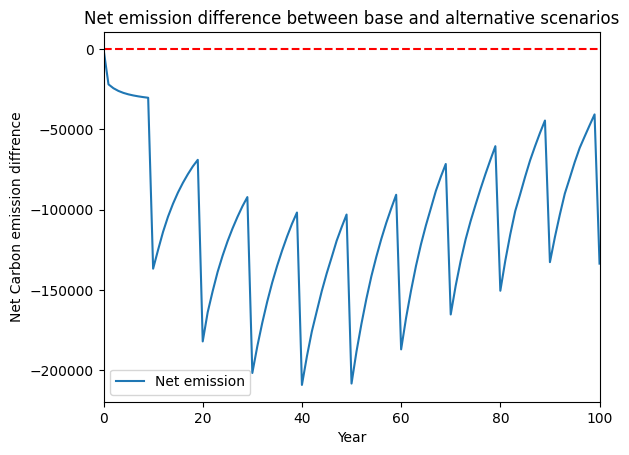

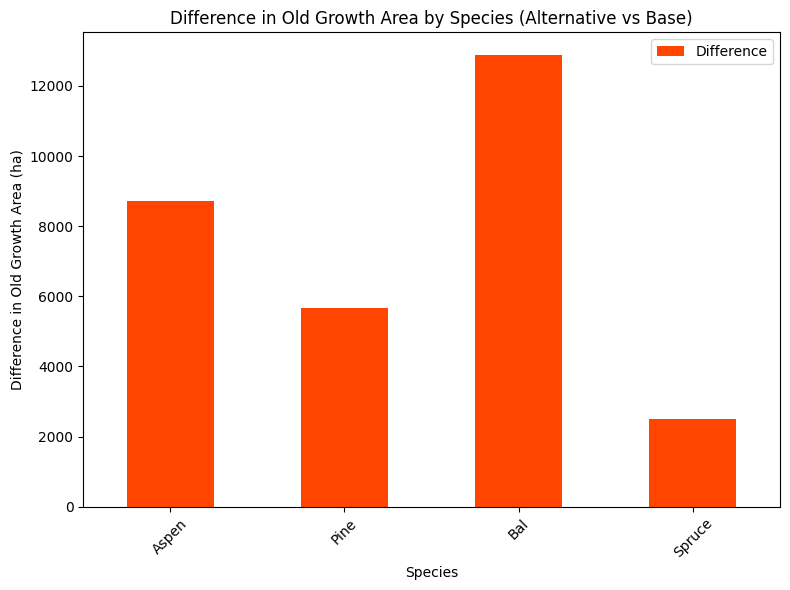

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_min_em_kpi_age_difference.pdf


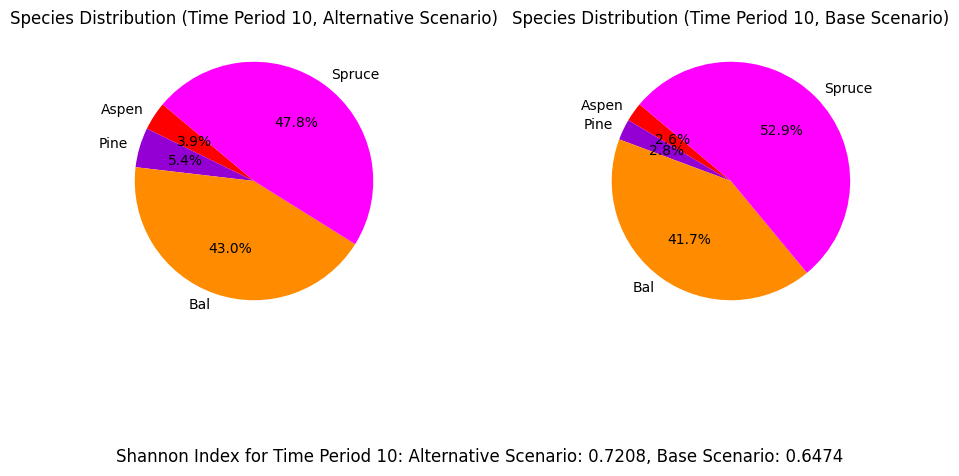

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_min_em_redchrs_AAC_40%...
running the scenario for the Red Chris mining site (40%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x60c09643
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.15s
Presolved: 1699 rows, 32529 column

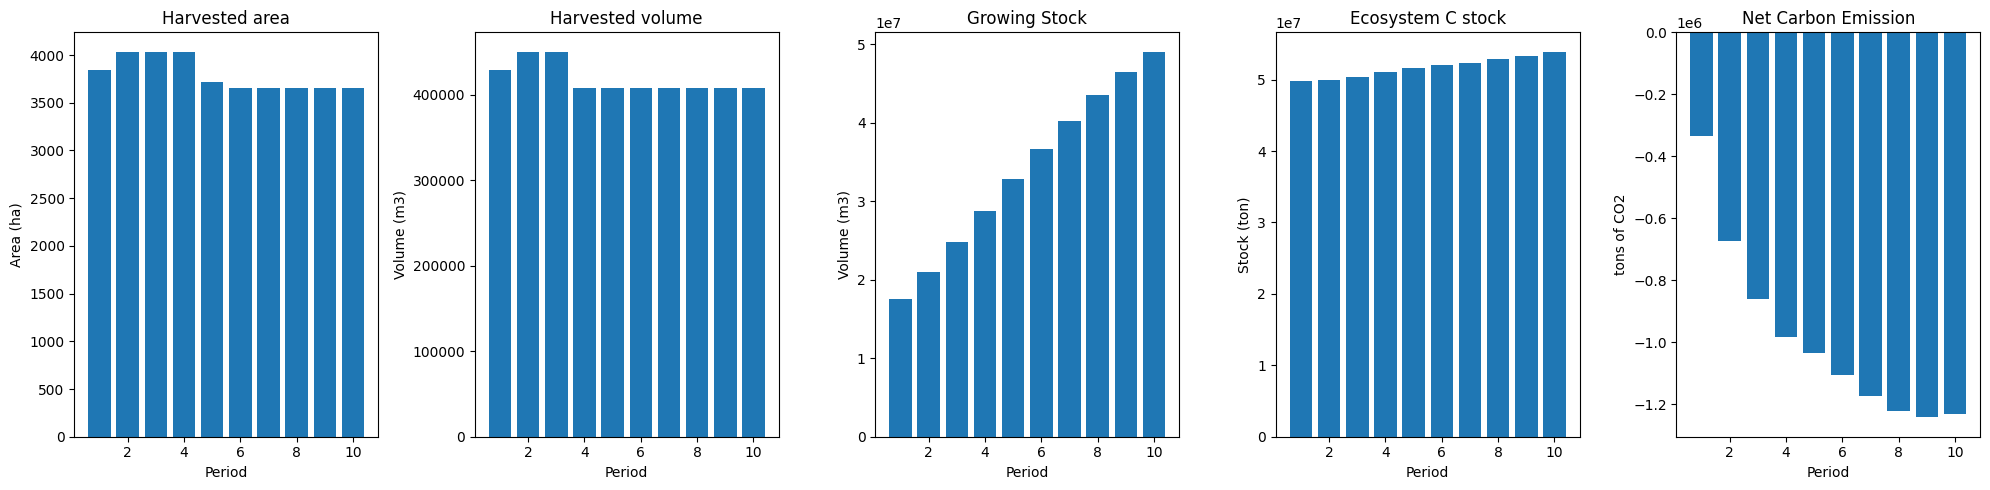

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_40%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  4423
The economic indicator (the provincial government revenues) is:  150851
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


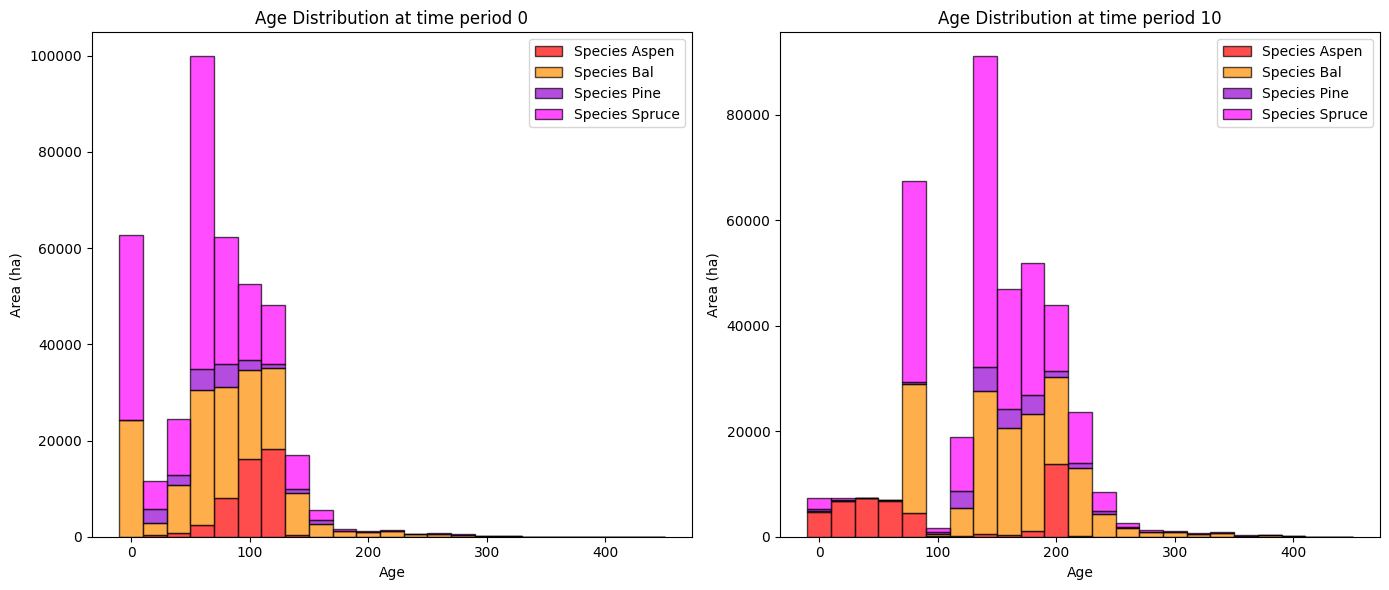

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_40%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  15659.147340  14713.833652
Pine     602.782616   8633.338568   8030.555951
Bal     4315.588546  53475.633375  49160.044829
Spruce  1072.814408  40448.915905  39376.101498

Overall diversity has **increased** by 111280.54 hectares from time period 0 to time period 10.


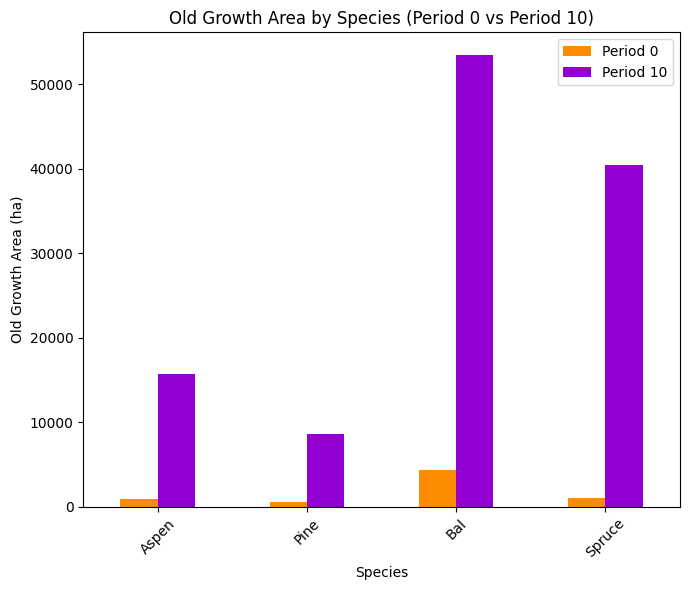

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_40%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.7305

Diversity has **decreased** by 15.43% from time 0 to time 10.


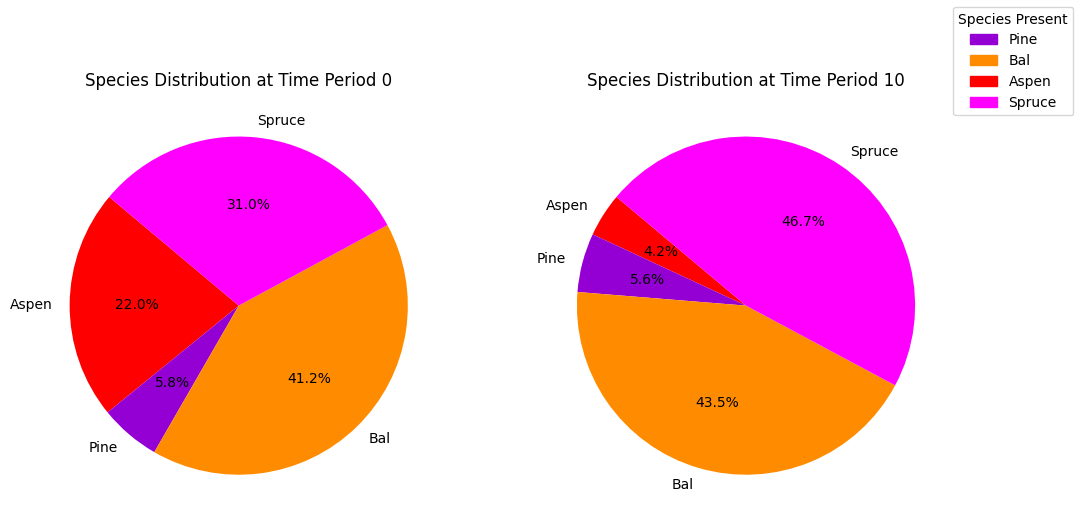

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_40%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x8d629ebf
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.14s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

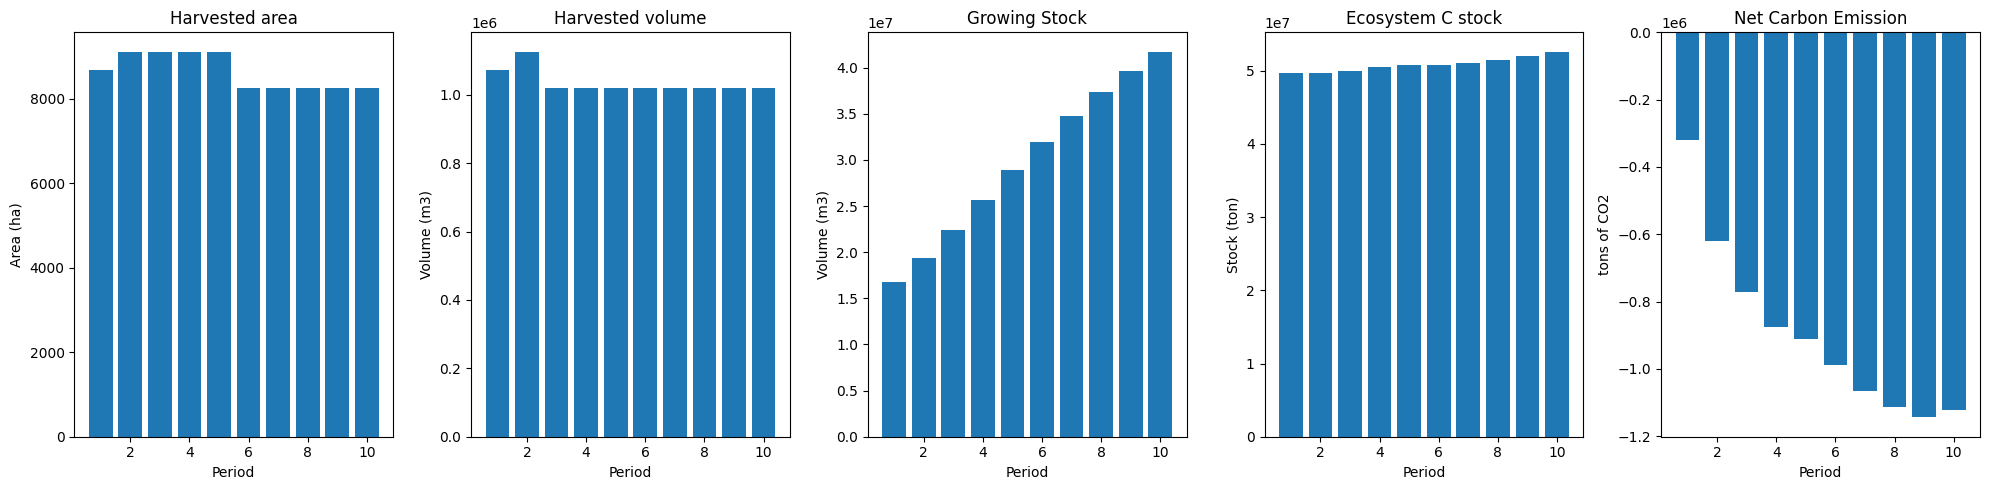

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10945
The economic indicator (the provincial government revenues) is:  373261
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


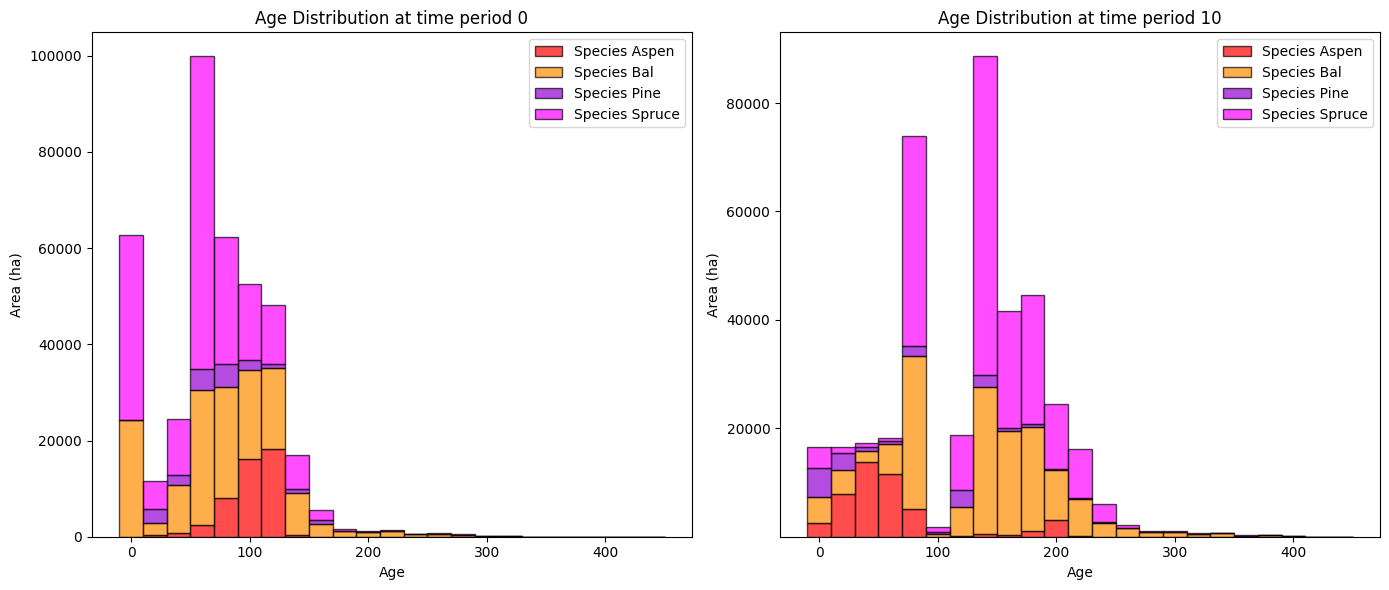

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688   4909.785142   3964.471454
Pine     602.782616   1772.814393   1170.031777
Bal     4315.588546  37139.500575  32823.912029
Spruce  1072.814408  37938.204945  36865.390537

Overall diversity has **increased** by 74823.81 hectares from time period 0 to time period 10.


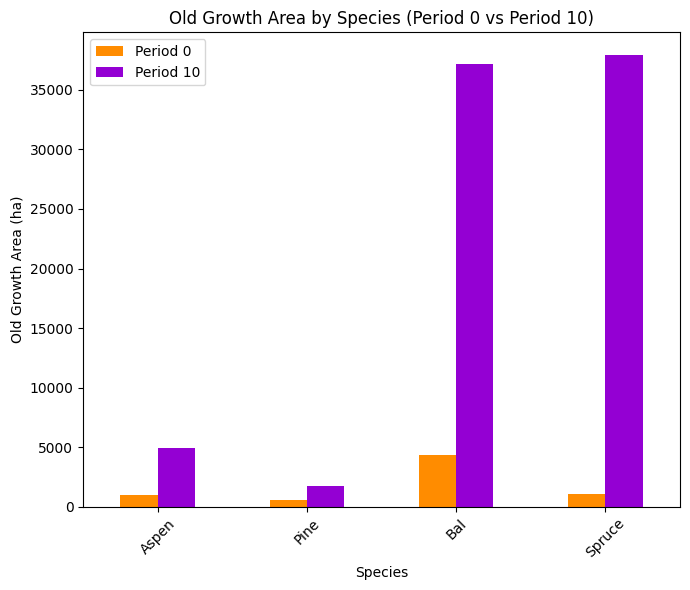

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.6474

Diversity has **decreased** by 23.74% from time 0 to time 10.


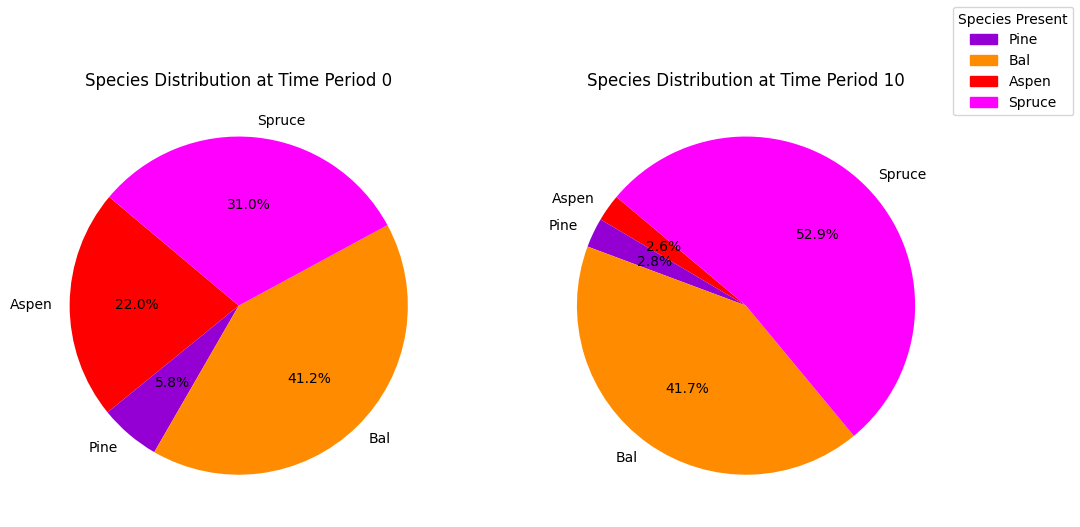

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_species_pie.pdf


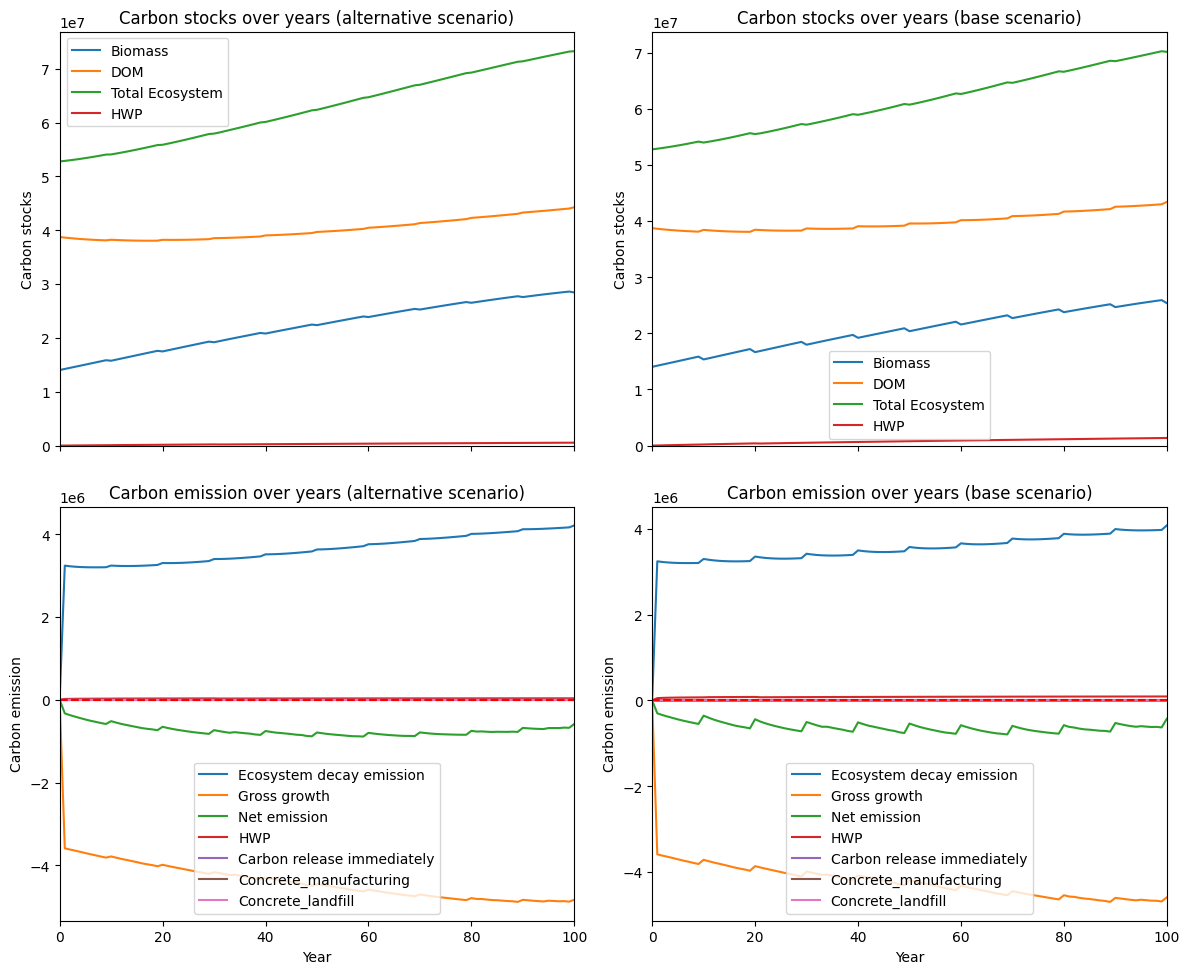

---------------------------------------------------------------------------------------
Net emission difference -2327777.7512117918
Net emission base scenario -14098531.928308379
Net emission alternative scenario -11770754.177096587
dollar_per_ton is:  4.29594276979158
Comparison of Old Growth Areas (Alternative - Base)
          0            10    Difference
Aspen   0.0  10749.362198  10749.362198
Pine    0.0   6860.524174   6860.524174
Bal     0.0  16336.132801  16336.132801
Spruce  0.0   2510.710961   2510.710961

Overall, the old growth area has **increased** by 36456.73 hectares in the alternative scenario compared to the base scenario.


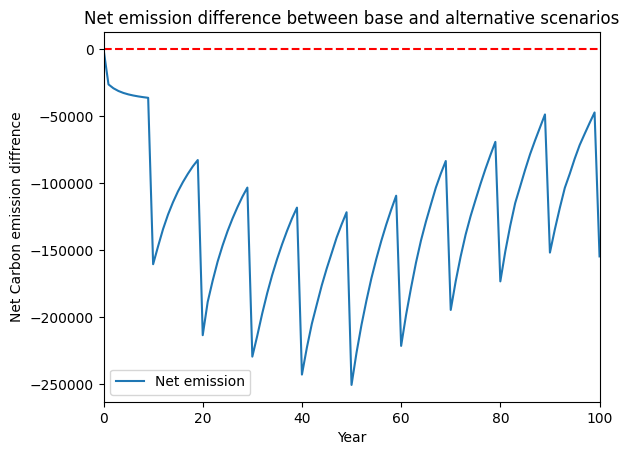

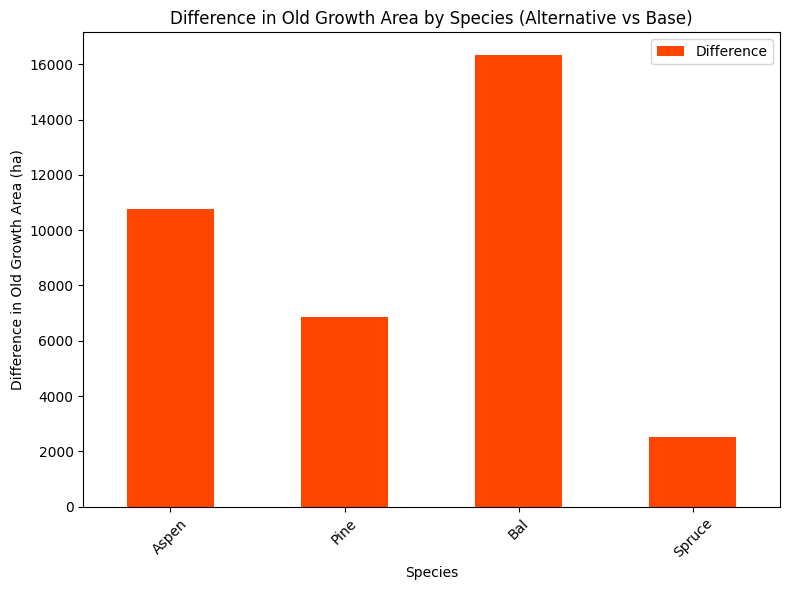

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_min_em_kpi_age_difference.pdf


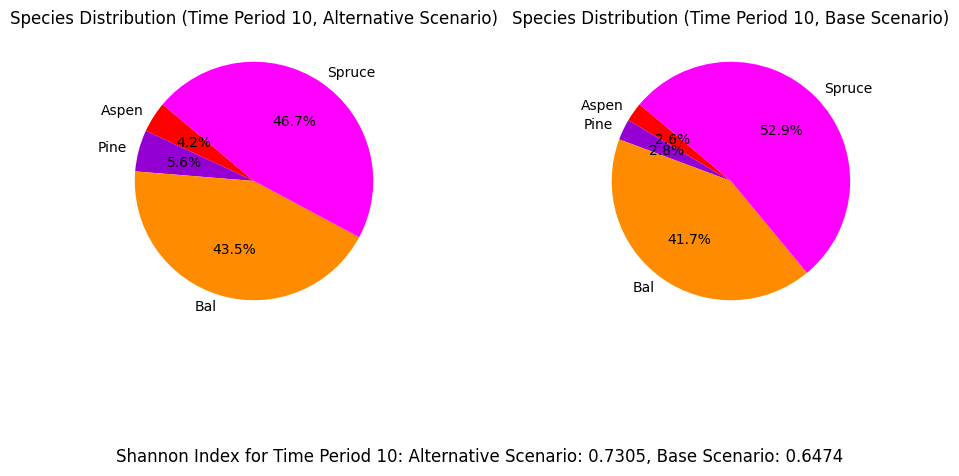

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_min_em_redchrs_AAC_30%...
running the scenario for the Red Chris mining site (30%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x2f8a20f8
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.14s
Presolved: 1699 rows, 32529 column

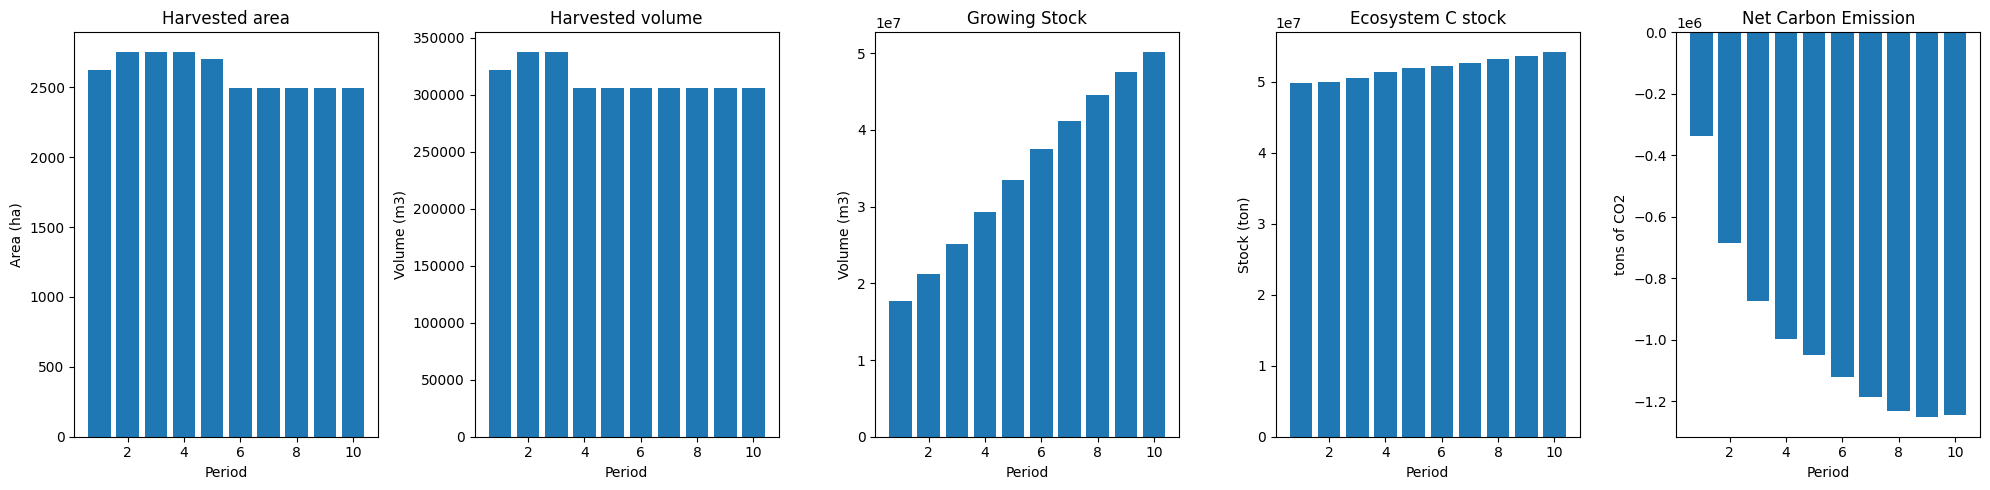

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_30%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  3317
The economic indicator (the provincial government revenues) is:  113138
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


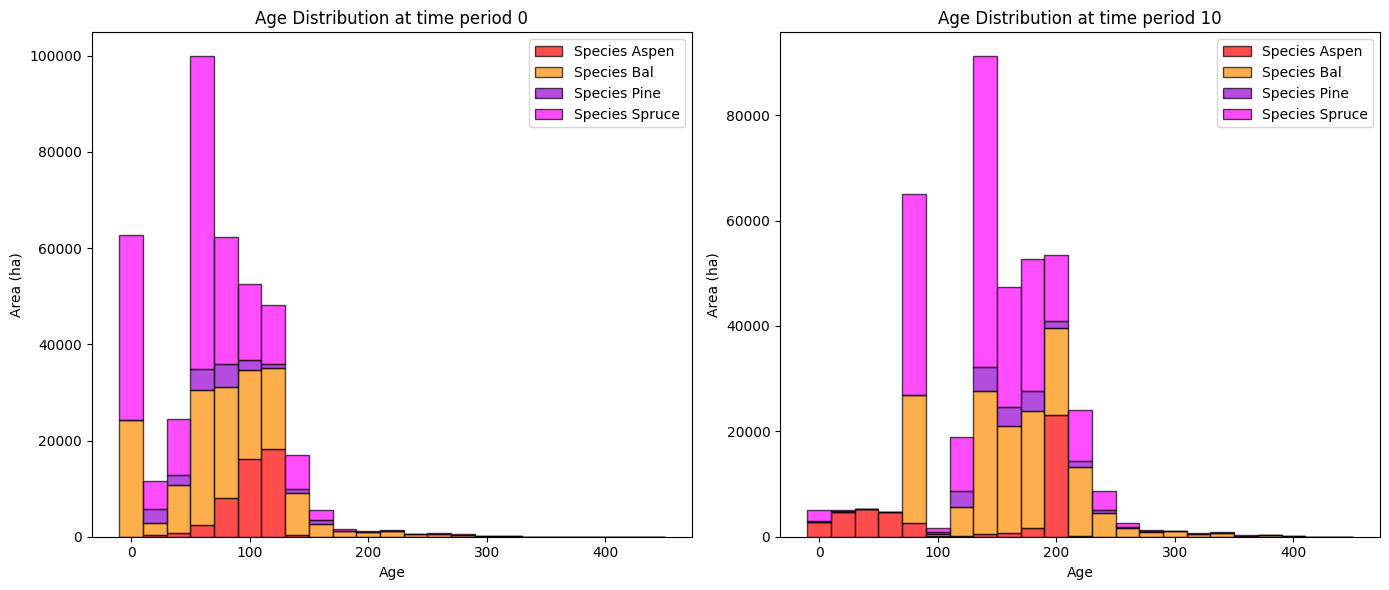

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_30%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  25898.831399  24953.517711
Pine     602.782616   9084.945750   8482.163133
Bal     4315.588546  54005.591687  49690.003141
Spruce  1072.814408  40465.217873  39392.403466

Overall diversity has **increased** by 122518.09 hectares from time period 0 to time period 10.


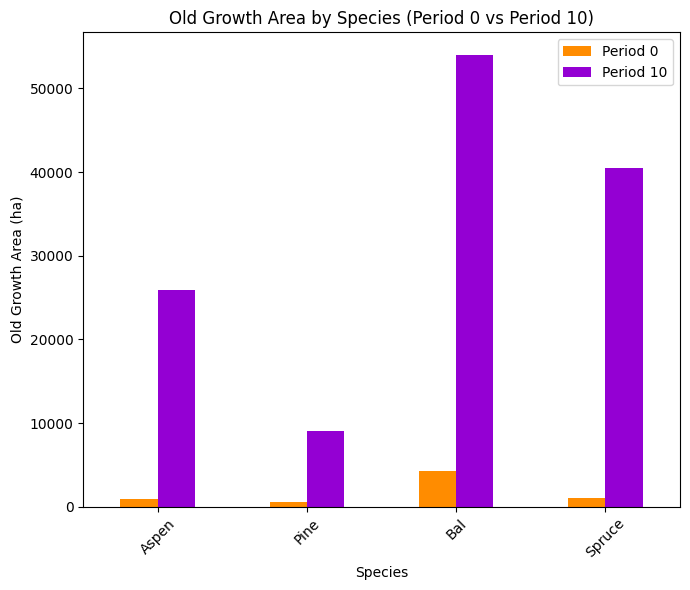

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_30%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.7585

Diversity has **decreased** by 12.63% from time 0 to time 10.


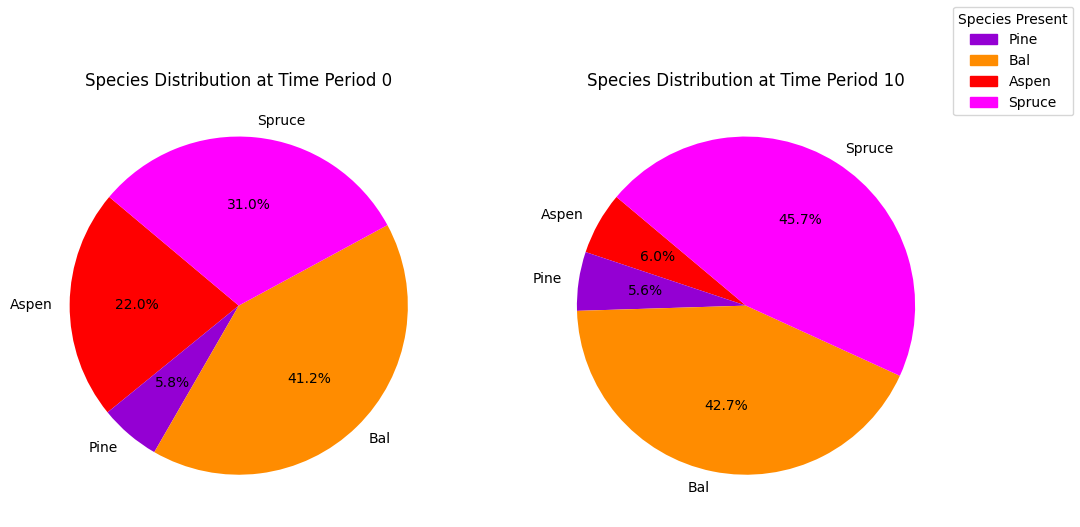

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_30%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x8d629ebf
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.15s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

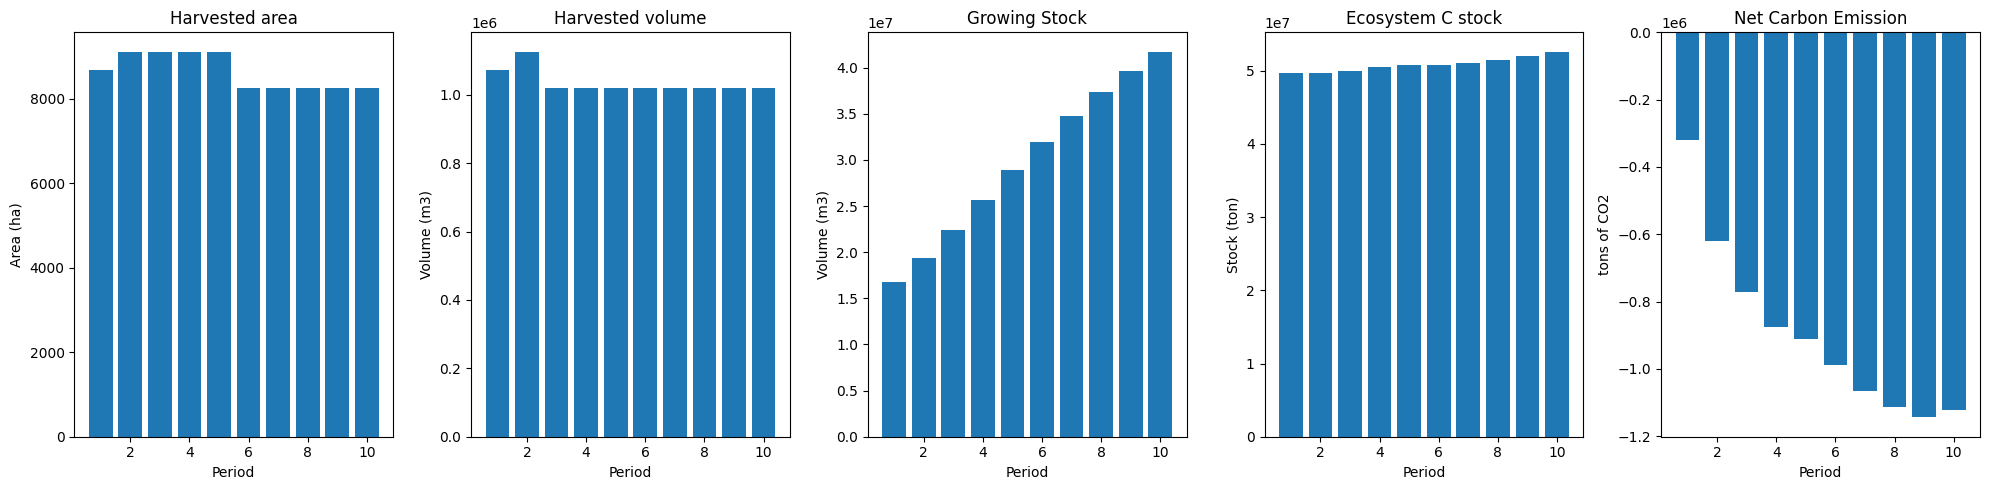

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10945
The economic indicator (the provincial government revenues) is:  373261
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


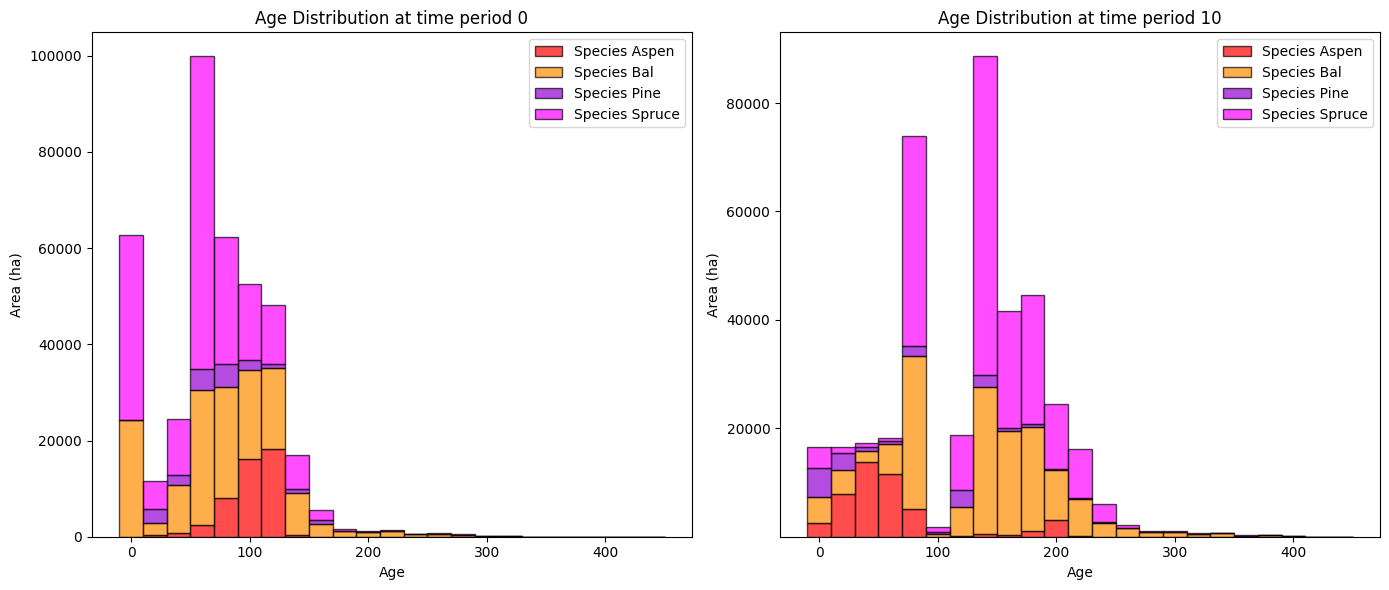

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688   4909.785142   3964.471454
Pine     602.782616   1772.814393   1170.031777
Bal     4315.588546  37139.500575  32823.912029
Spruce  1072.814408  37938.204945  36865.390537

Overall diversity has **increased** by 74823.81 hectares from time period 0 to time period 10.


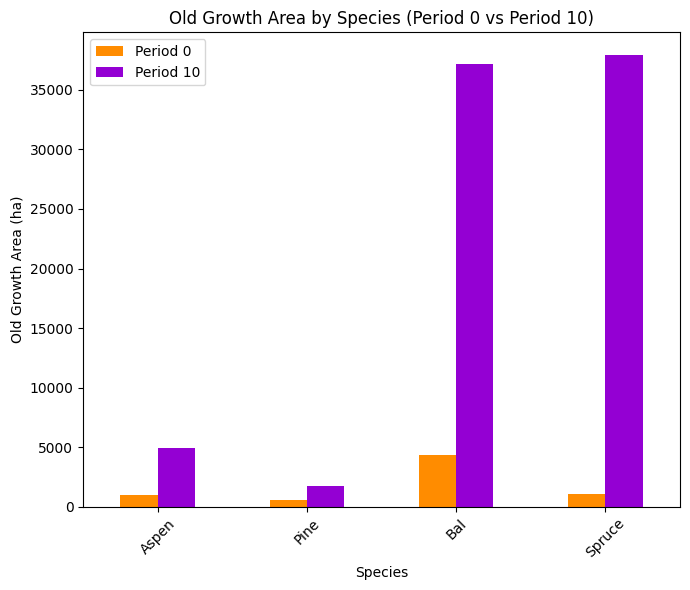

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.6474

Diversity has **decreased** by 23.74% from time 0 to time 10.


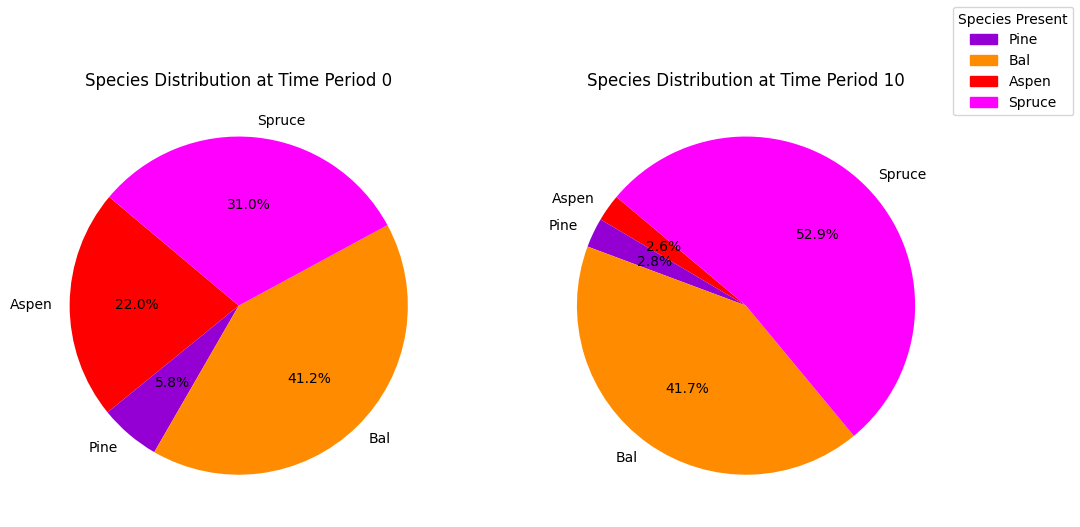

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_species_pie.pdf


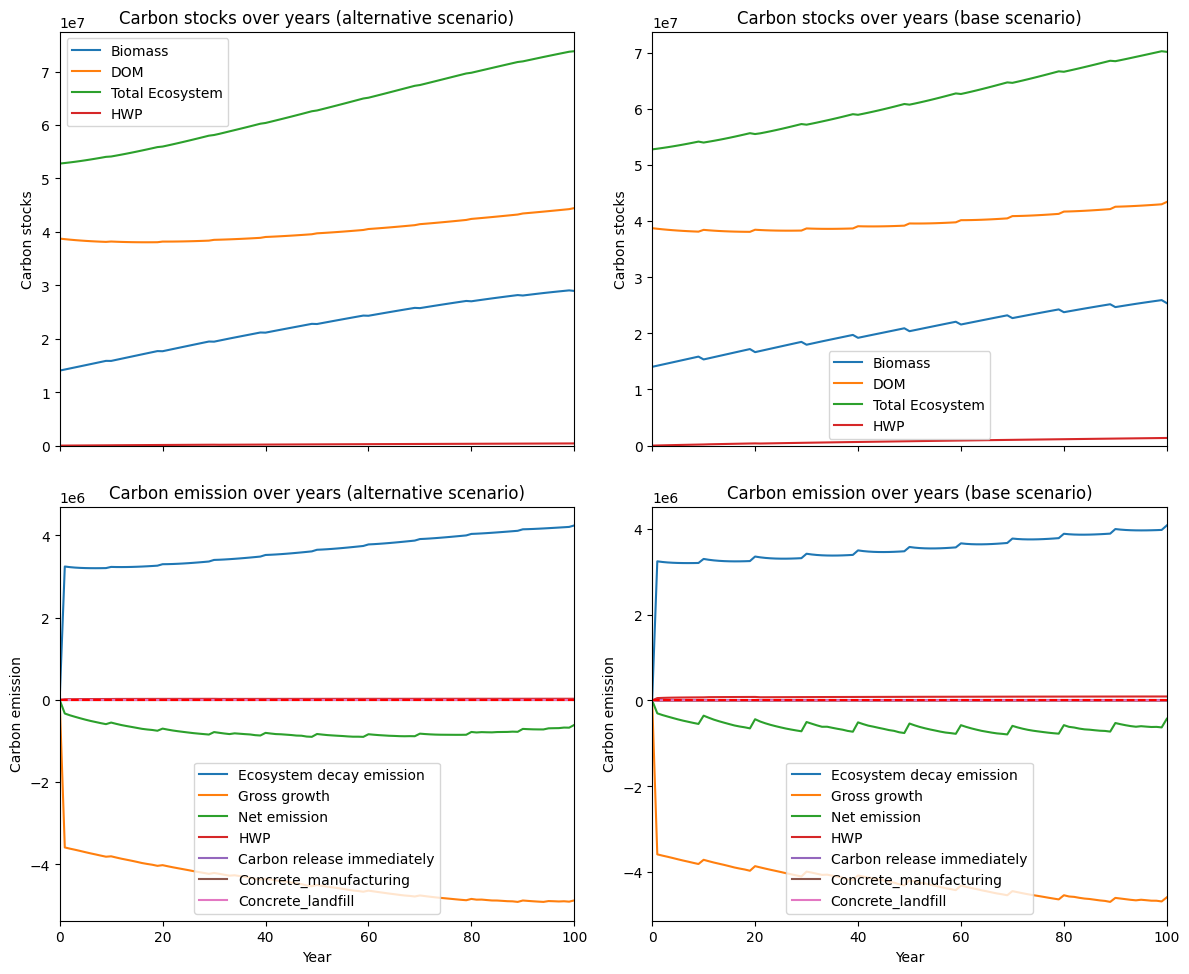

---------------------------------------------------------------------------------------
Net emission difference -2817888.32064987
Net emission base scenario -14588642.497746456
Net emission alternative scenario -11770754.177096587
dollar_per_ton is:  3.5487566795031
Comparison of Old Growth Areas (Alternative - Base)
          0            10    Difference
Aspen   0.0  20989.046257  20989.046257
Pine    0.0   7312.131356   7312.131356
Bal     0.0  16866.091113  16866.091113
Spruce  0.0   2527.012929   2527.012929

Overall, the old growth area has **increased** by 47694.28 hectares in the alternative scenario compared to the base scenario.


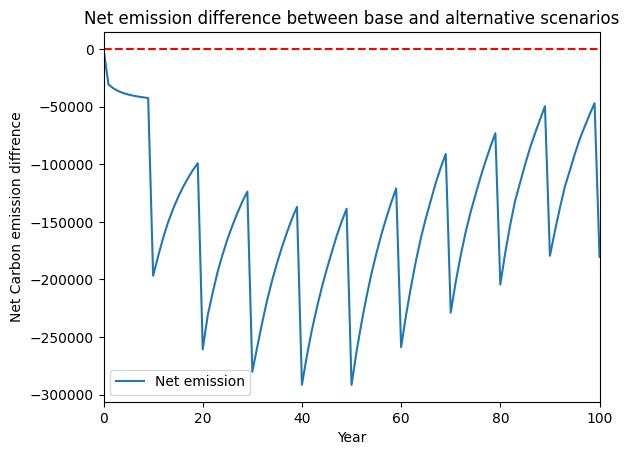

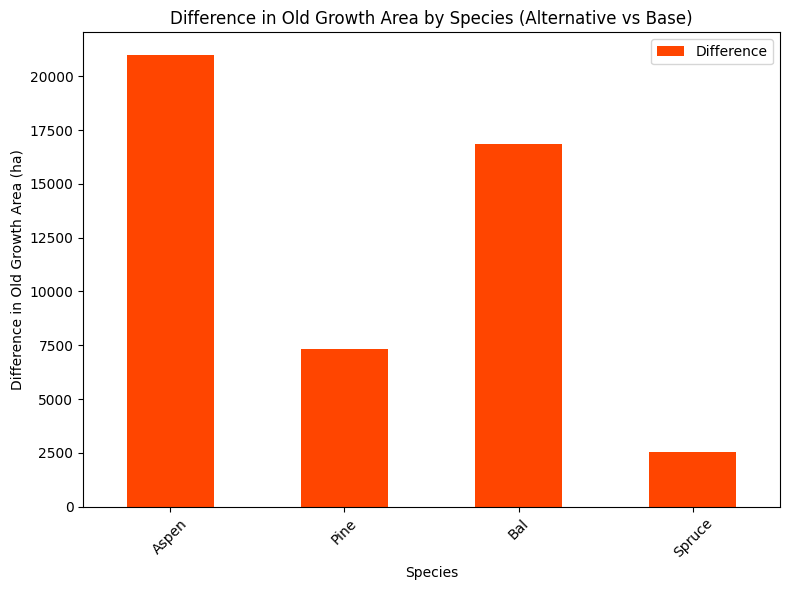

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_min_em_kpi_age_difference.pdf


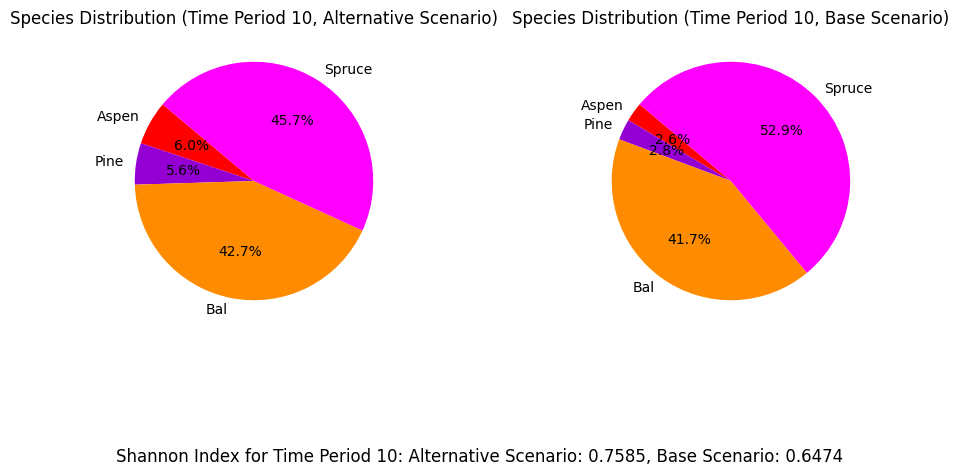

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_min_em_redchrs_AAC_20%...
running the scenario for the Red Chris mining site (20%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0xfd534cad
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.17s
Presolved: 1699 rows, 32529 column

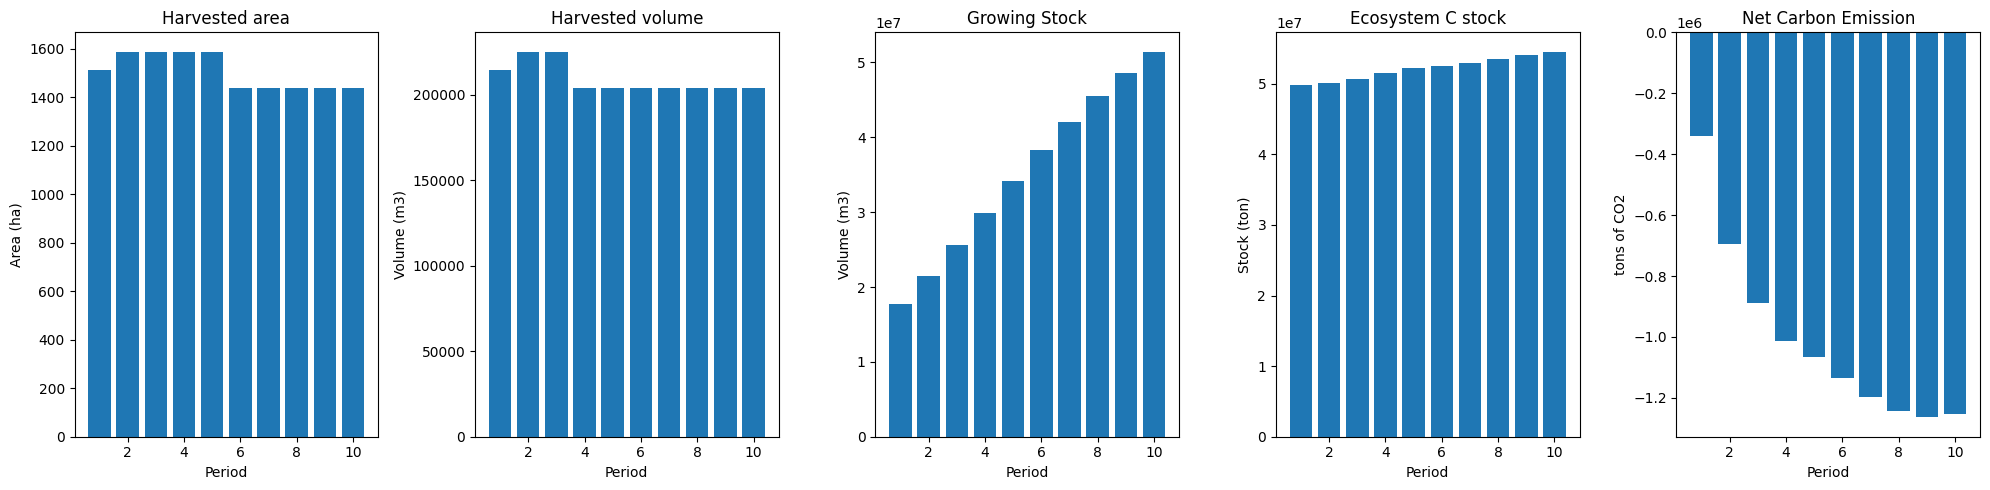

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_20%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  2211
The economic indicator (the provincial government revenues) is:  75425
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


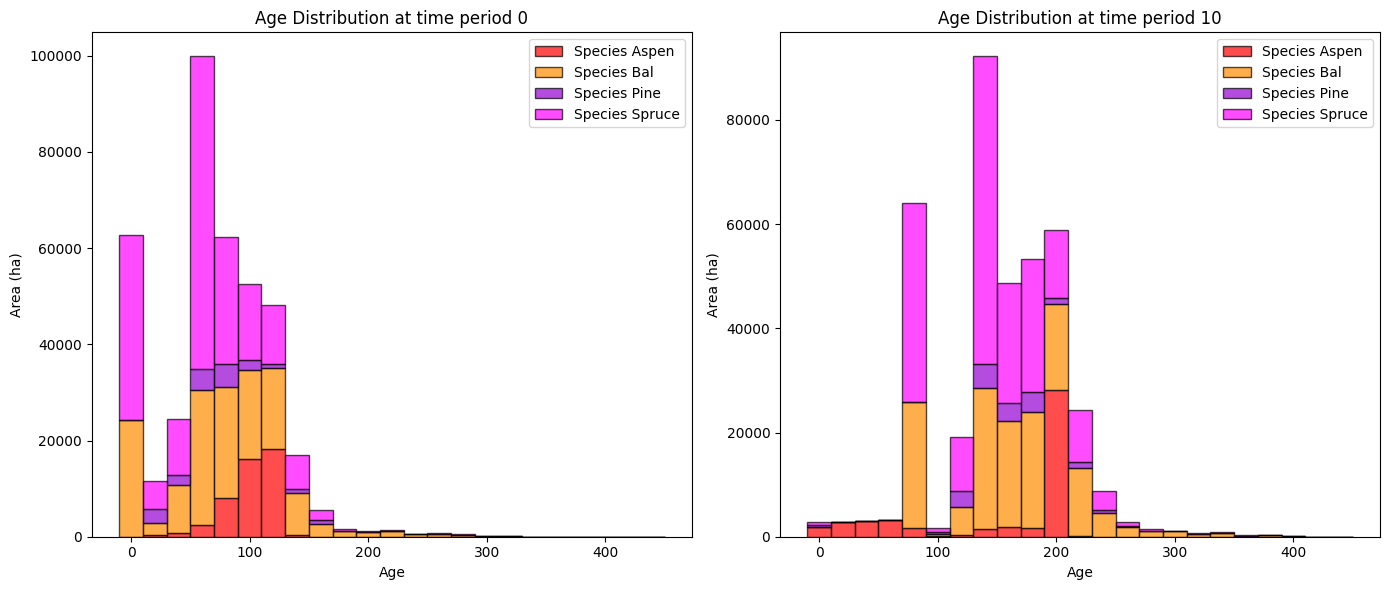

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_20%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  32194.287146  31248.973458
Pine     602.782616   9105.251120   8502.468504
Bal     4315.588546  54242.845266  49927.256720
Spruce  1072.814408  41568.021423  40495.207015

Overall diversity has **increased** by 130173.91 hectares from time period 0 to time period 10.


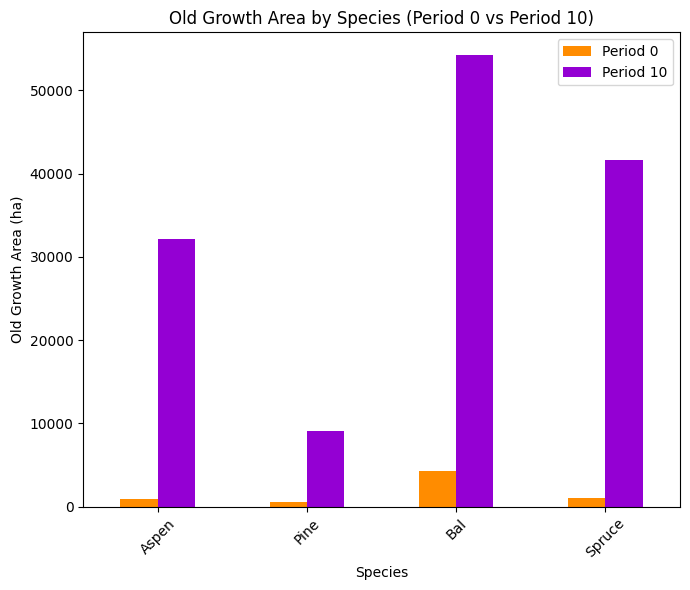

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_20%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.7787

Diversity has **decreased** by 10.61% from time 0 to time 10.


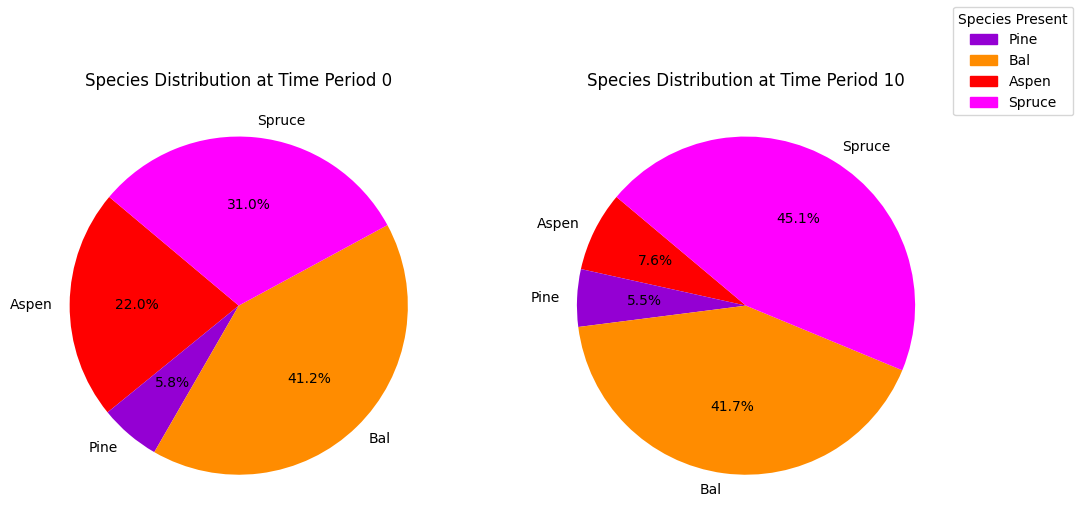

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_20%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x8d629ebf
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.12s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

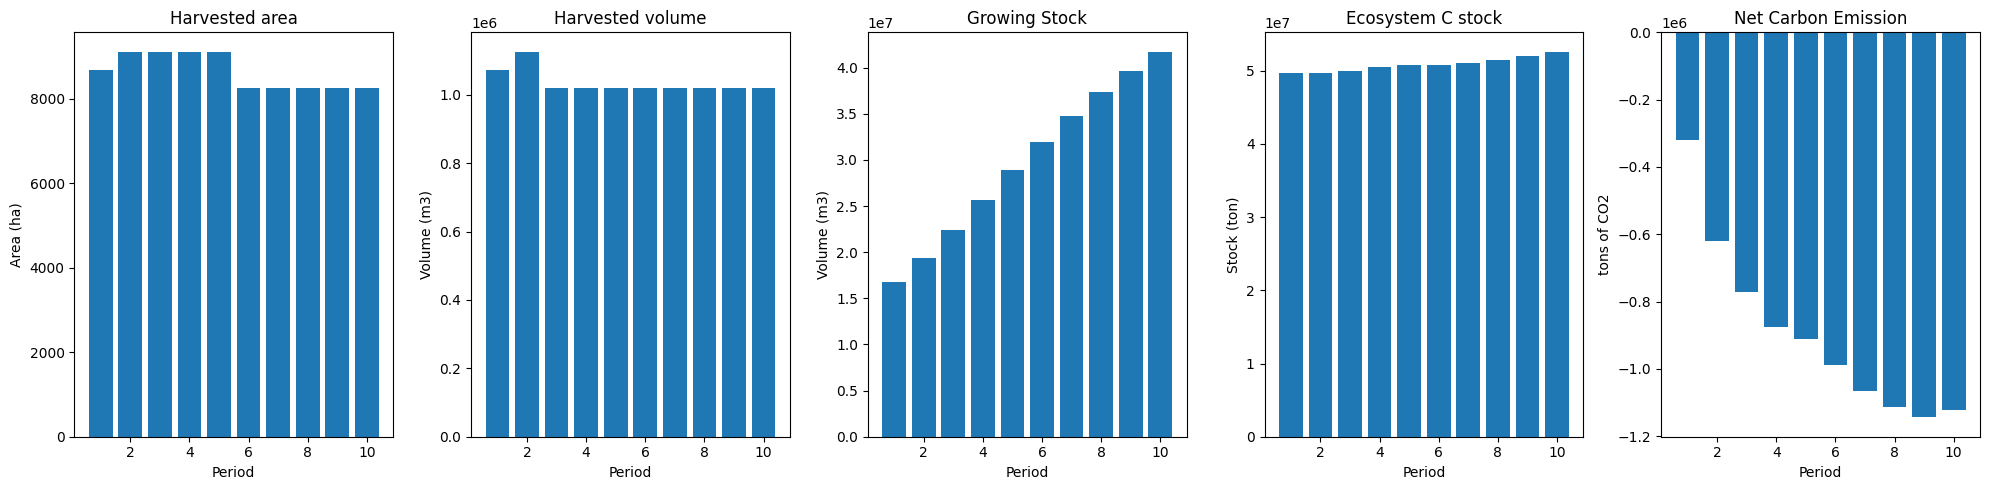

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10945
The economic indicator (the provincial government revenues) is:  373261
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


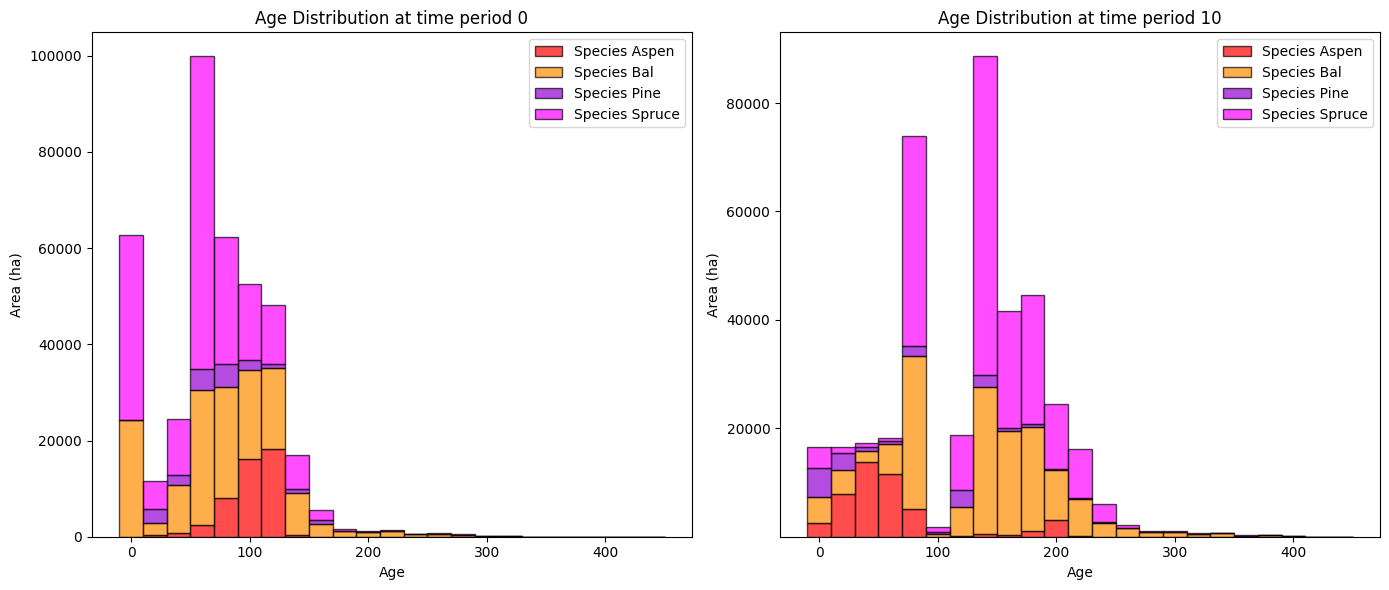

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688   4909.785142   3964.471454
Pine     602.782616   1772.814393   1170.031777
Bal     4315.588546  37139.500575  32823.912029
Spruce  1072.814408  37938.204945  36865.390537

Overall diversity has **increased** by 74823.81 hectares from time period 0 to time period 10.


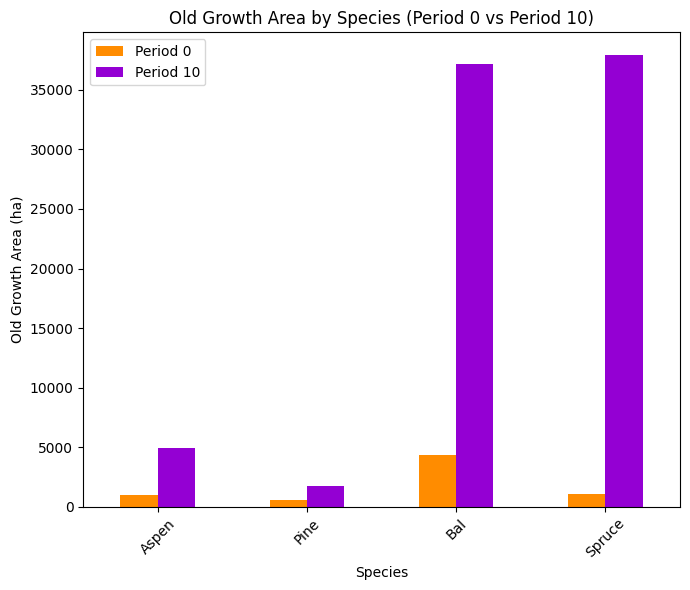

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.6474

Diversity has **decreased** by 23.74% from time 0 to time 10.


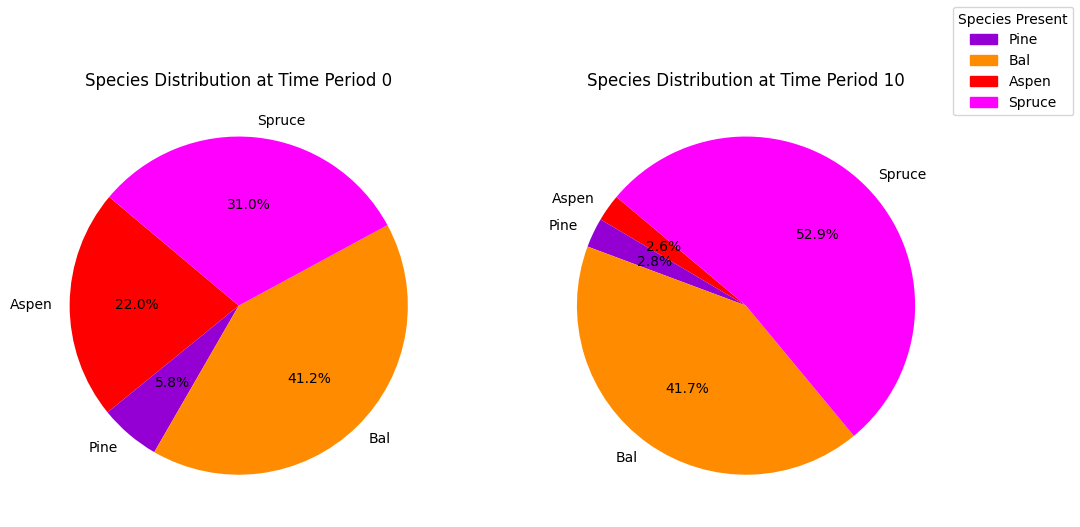

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_species_pie.pdf


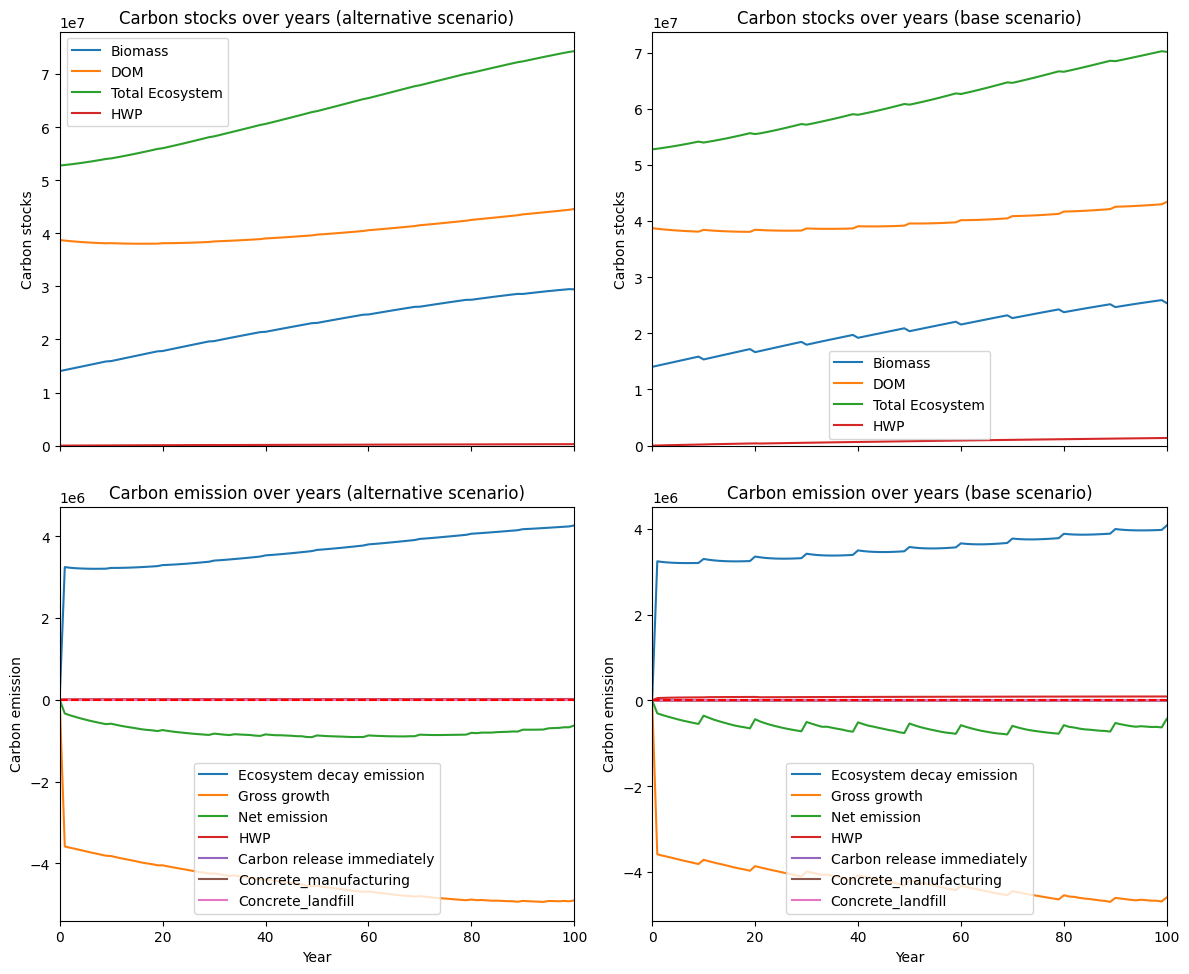

---------------------------------------------------------------------------------------
Net emission difference -3271426.12783631
Net emission base scenario -15042180.304932896
Net emission alternative scenario -11770754.177096587
dollar_per_ton is:  3.056770842205722
Comparison of Old Growth Areas (Alternative - Base)
          0            10    Difference
Aspen   0.0  27284.502004  27284.502004
Pine    0.0   7332.436727   7332.436727
Bal     0.0  17103.344691  17103.344691
Spruce  0.0   3629.816478   3629.816478

Overall, the old growth area has **increased** by 55350.10 hectares in the alternative scenario compared to the base scenario.


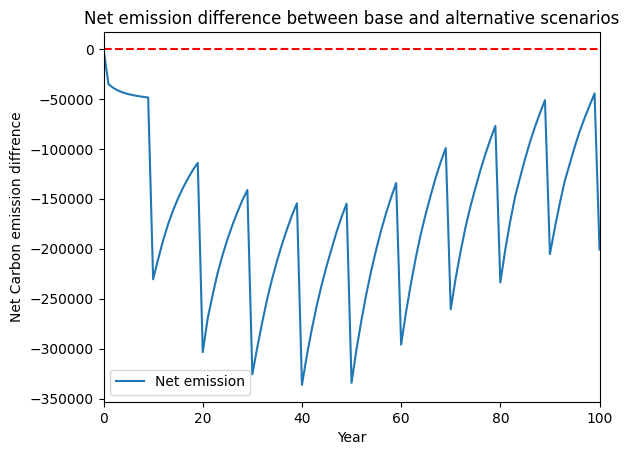

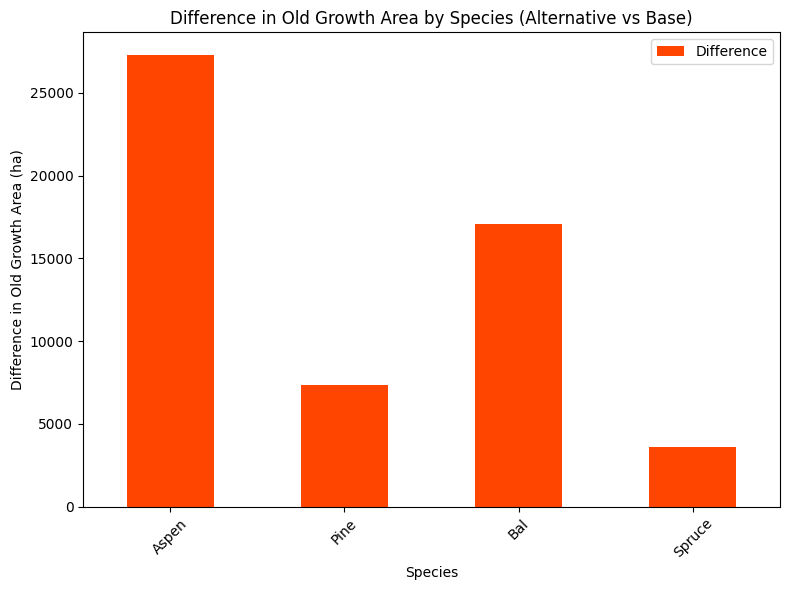

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_min_em_kpi_age_difference.pdf


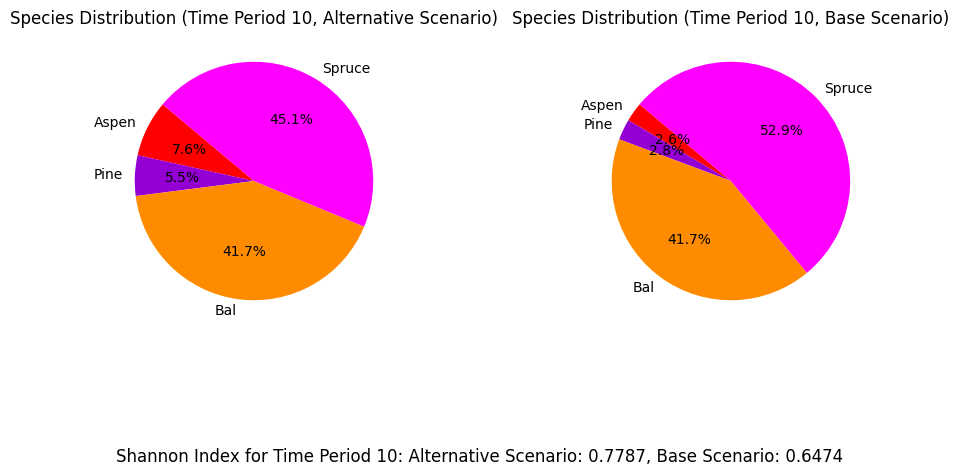

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for redchris_min_em_redchrs_AAC_10%...
running the scenario for the Red Chris mining site (10%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x9fd649b5
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.13s
Presolved: 1699 rows, 32529 column

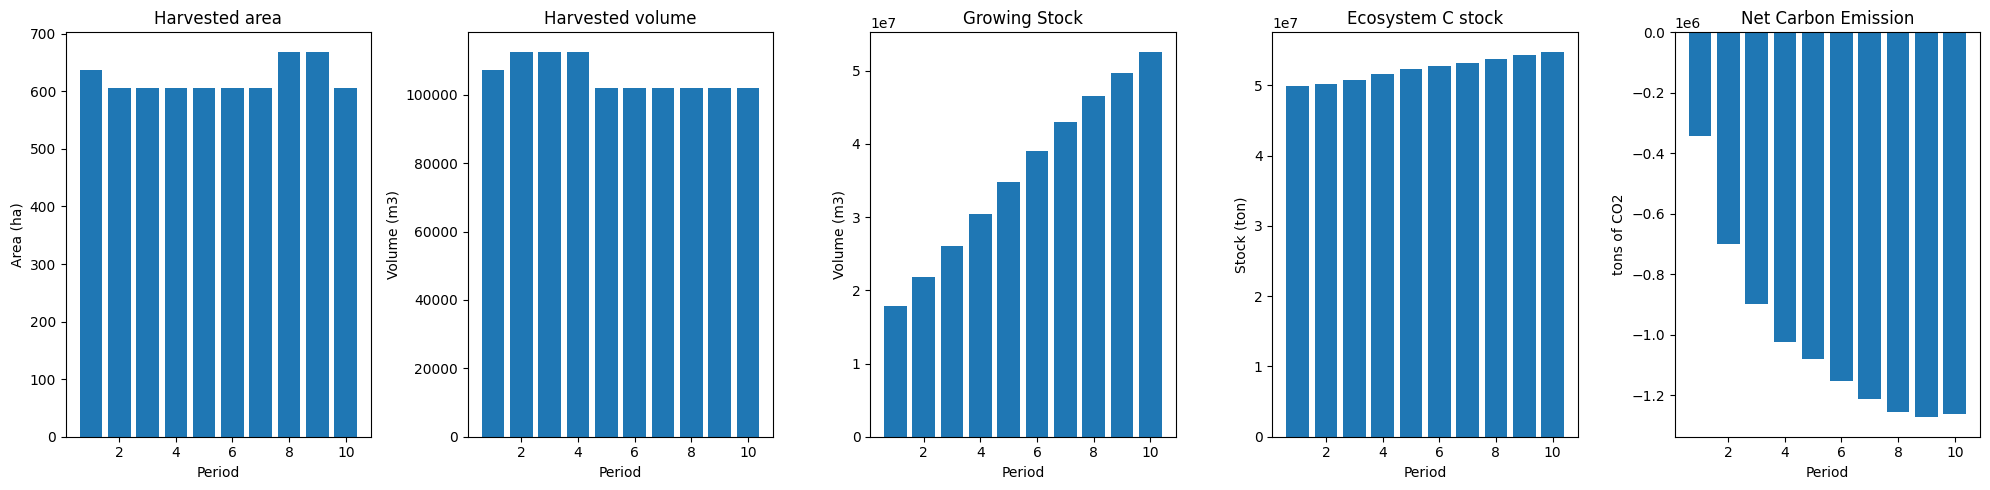

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_10%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  1117
The economic indicator (the provincial government revenues) is:  38099
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


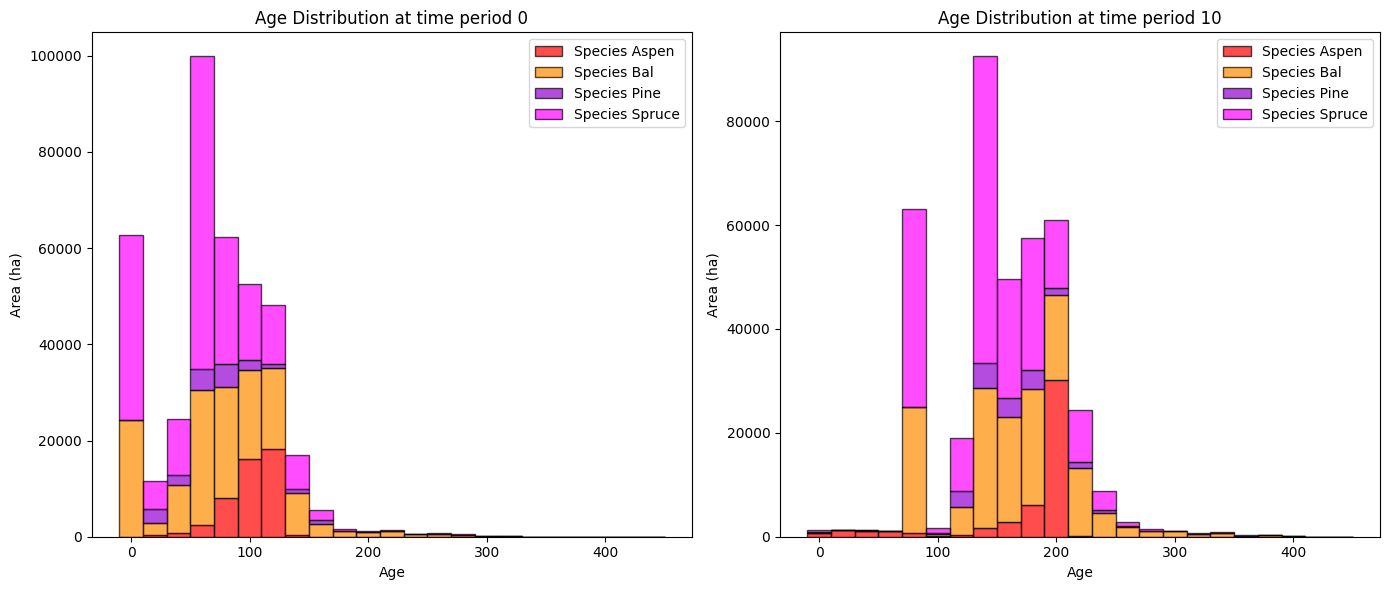

Plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_10%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688  39782.072126  38836.758438
Pine     602.782616   9118.624980   8515.842364
Bal     4315.588546  54242.845266  49927.256720
Spruce  1072.814408  41775.452374  40702.637966

Overall diversity has **increased** by 137982.50 hectares from time period 0 to time period 10.


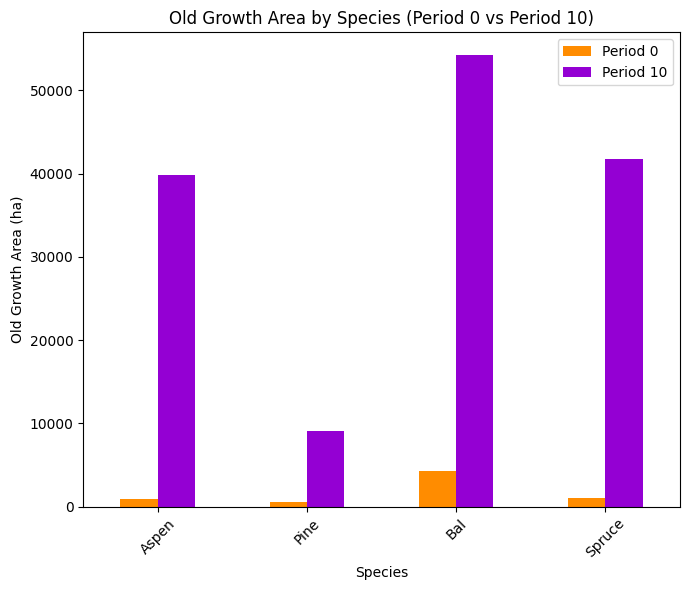

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_10%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.7992

Diversity has **decreased** by 8.56% from time 0 to time 10.


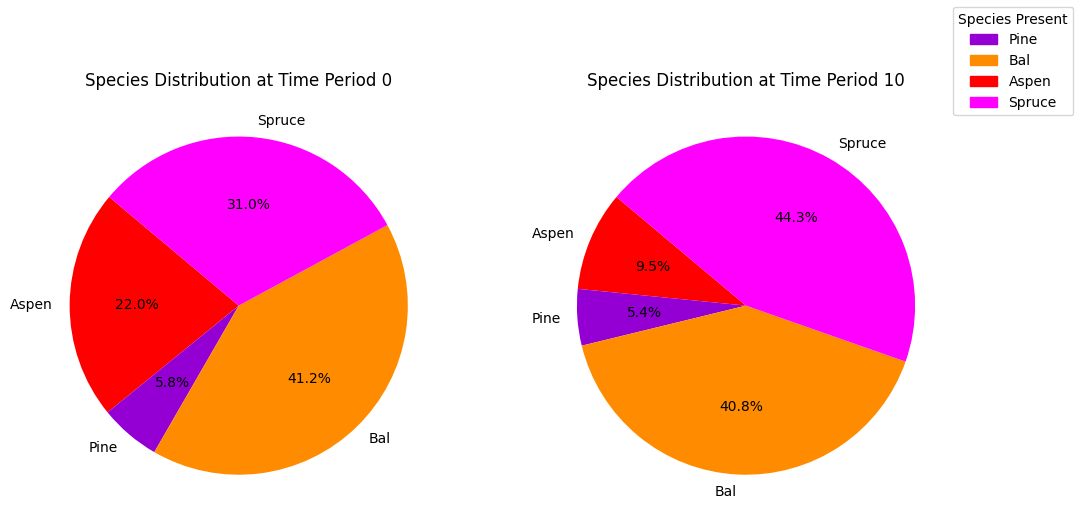

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_redchrs_AAC_10%_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3711 rows, 34533 columns and 483527 nonzeros
Model fingerprint: 0x8d629ebf
Coefficient statistics:
  Matrix range     [1e-02, 4e+06]
  Objective range  [9e-03, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2012 rows and 2005 columns
Presolve time: 0.13s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time:

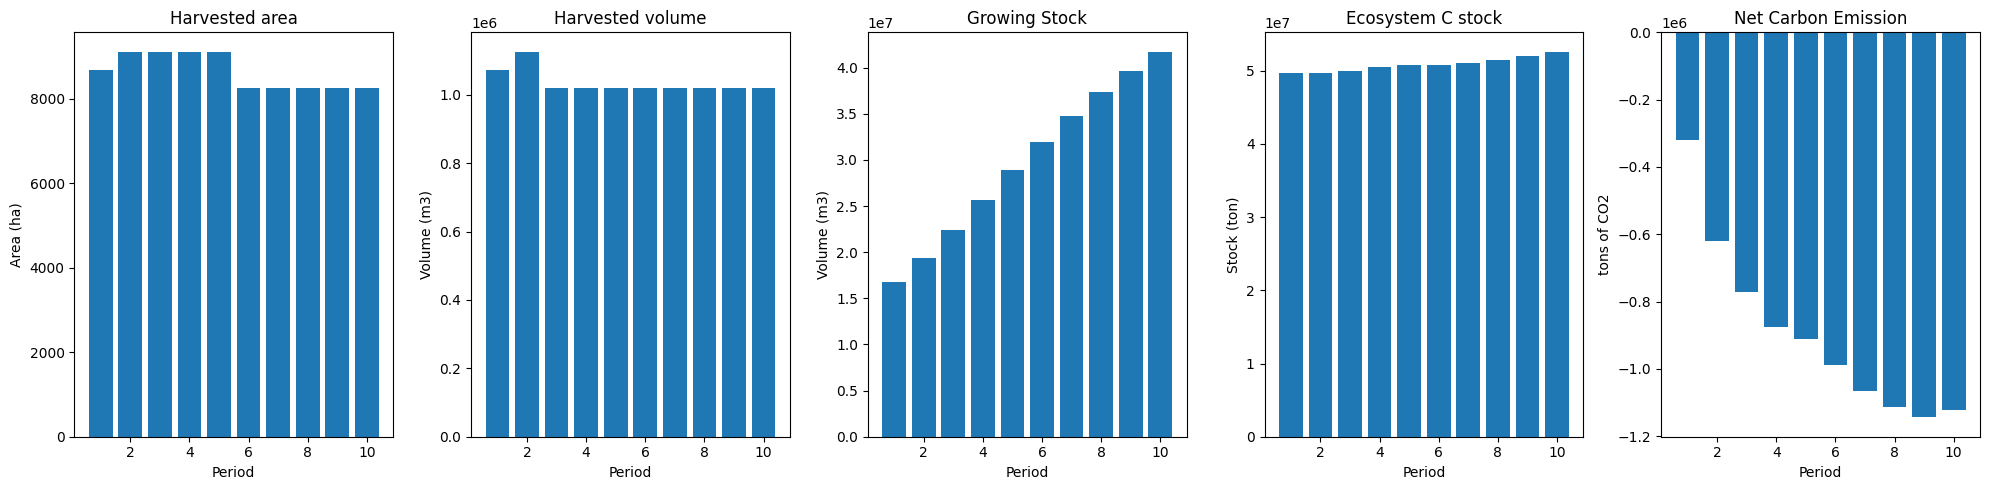

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10945
The economic indicator (the provincial government revenues) is:  373261
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


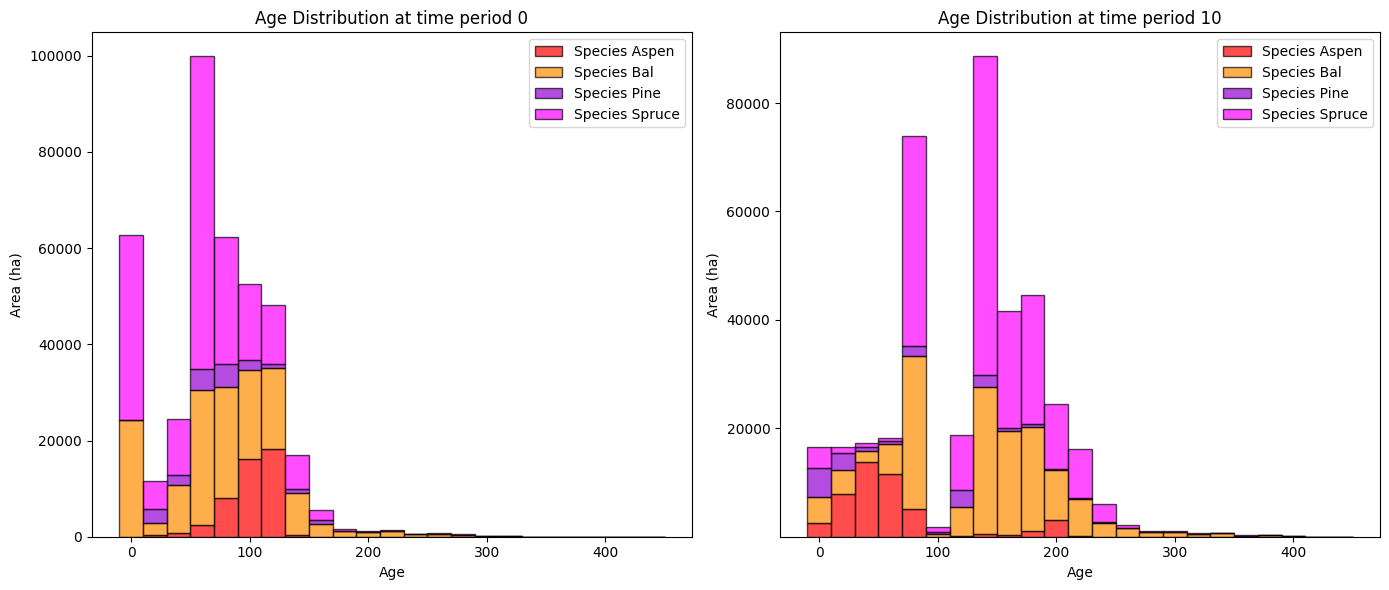

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                  0            10    Difference
Aspen    945.313688   4909.785142   3964.471454
Pine     602.782616   1772.814393   1170.031777
Bal     4315.588546  37139.500575  32823.912029
Spruce  1072.814408  37938.204945  36865.390537

Overall diversity has **increased** by 74823.81 hectares from time period 0 to time period 10.


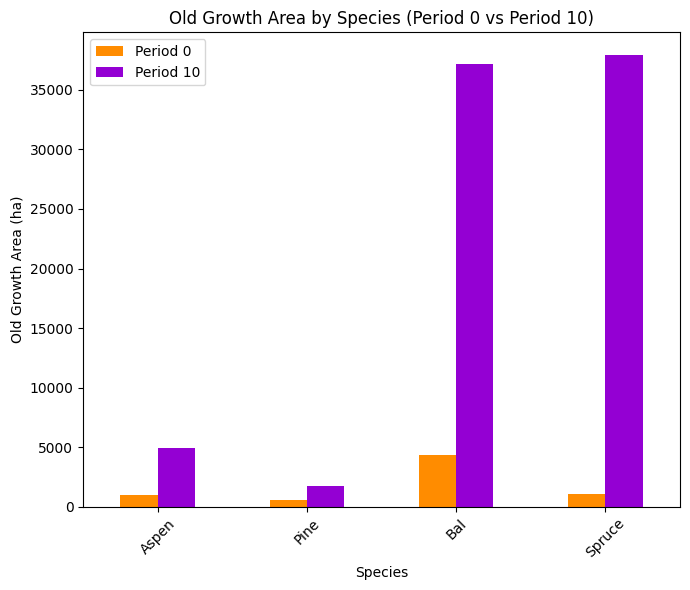

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.8848
Shannon Evenness Index for time period 10: 0.6474

Diversity has **decreased** by 23.74% from time 0 to time 10.


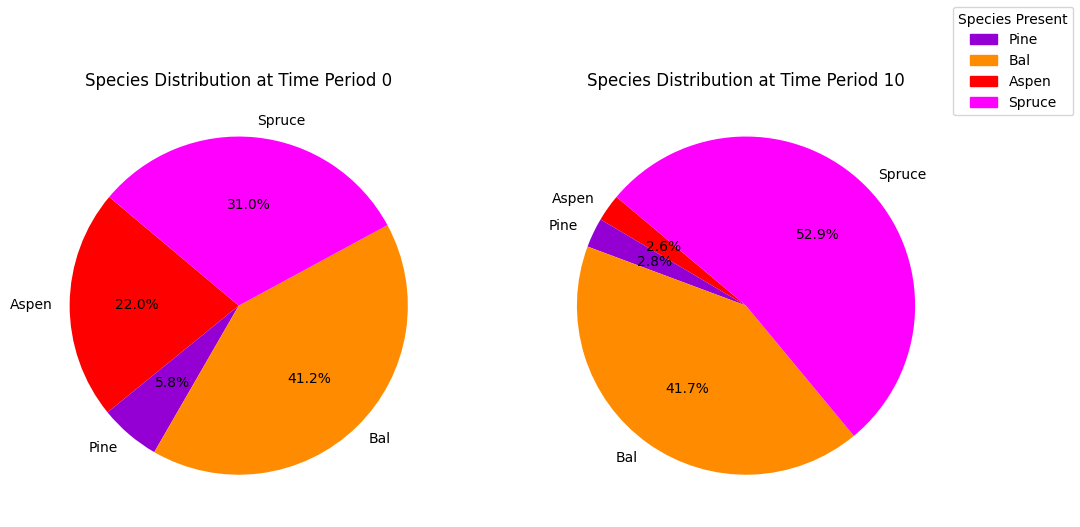

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_species_pie.pdf


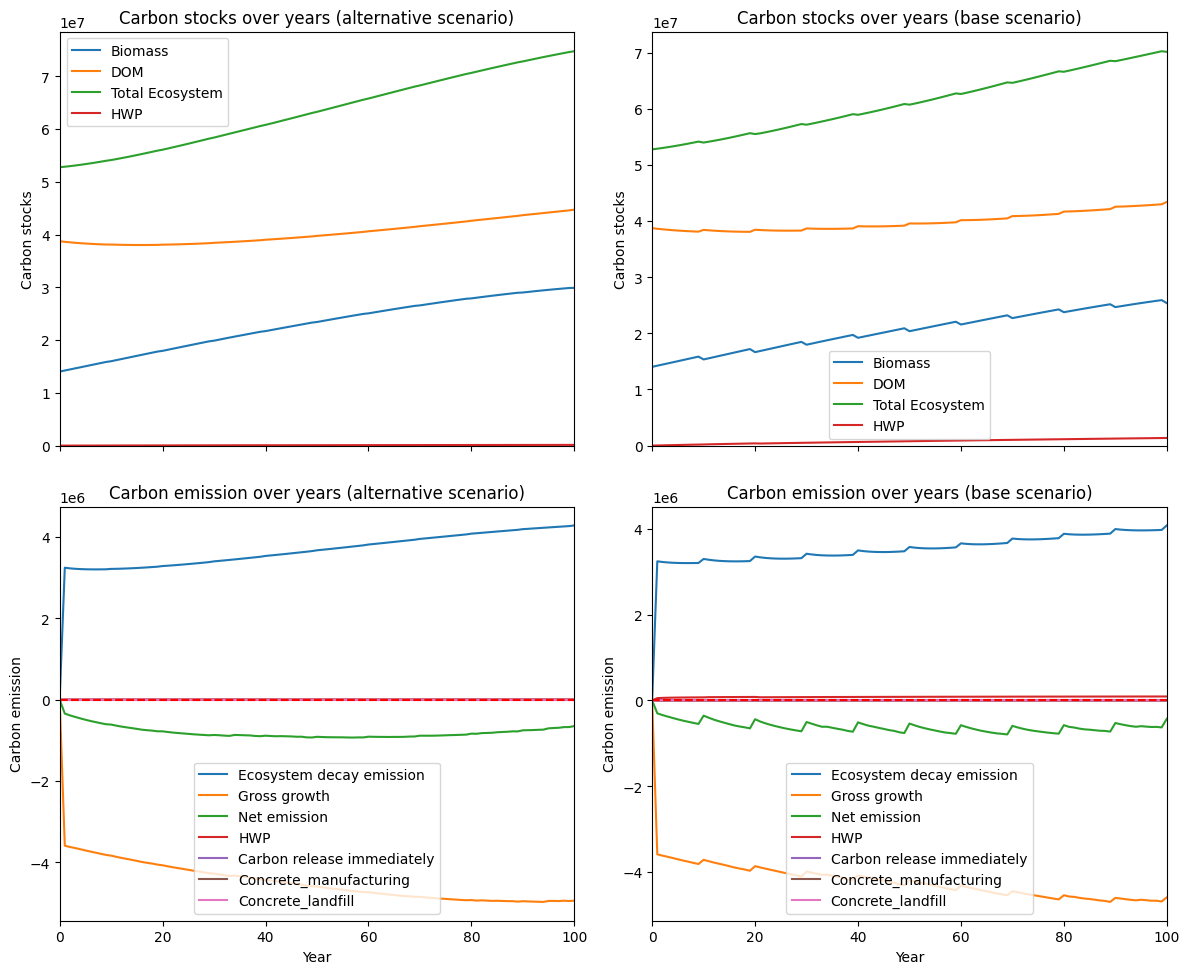

---------------------------------------------------------------------------------------
Net emission difference -3631135.1719289976
Net emission base scenario -15401889.349025581
Net emission alternative scenario -11770754.177096587
dollar_per_ton is:  2.7539597196233316
Comparison of Old Growth Areas (Alternative - Base)
          0            10    Difference
Aspen   0.0  34872.286984  34872.286984
Pine    0.0   7345.810587   7345.810587
Bal     0.0  17103.344691  17103.344691
Spruce  0.0   3837.247429   3837.247429

Overall, the old growth area has **increased** by 63158.69 hectares in the alternative scenario compared to the base scenario.


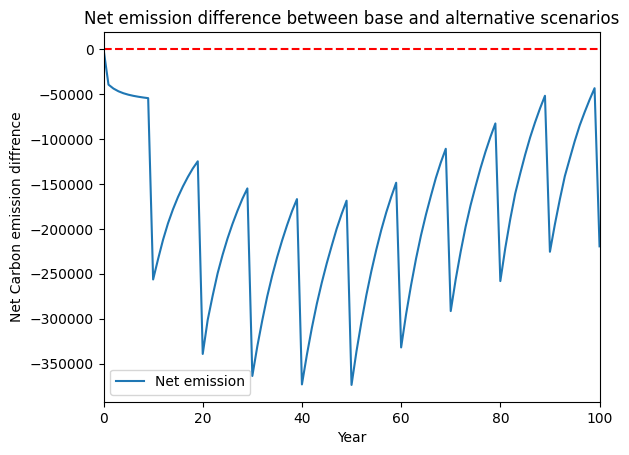

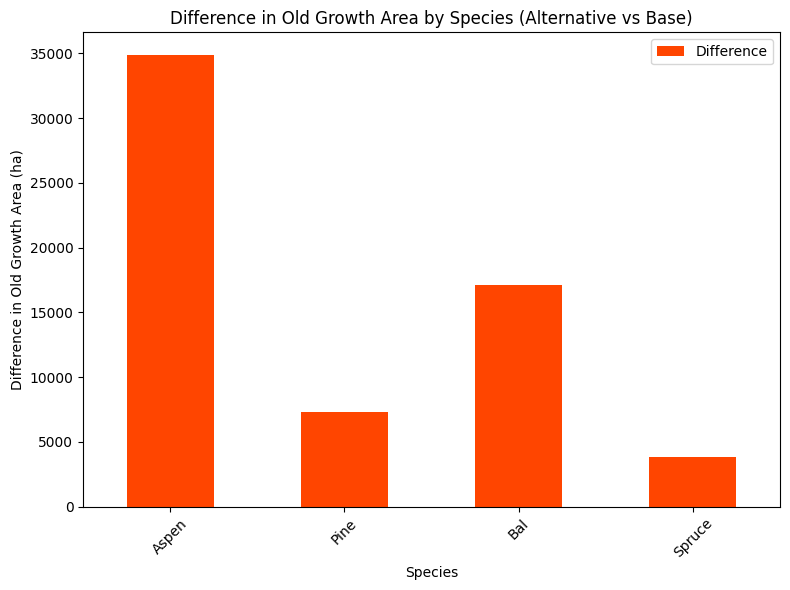

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/redchris/redchris_min_em_kpi_age_difference.pdf


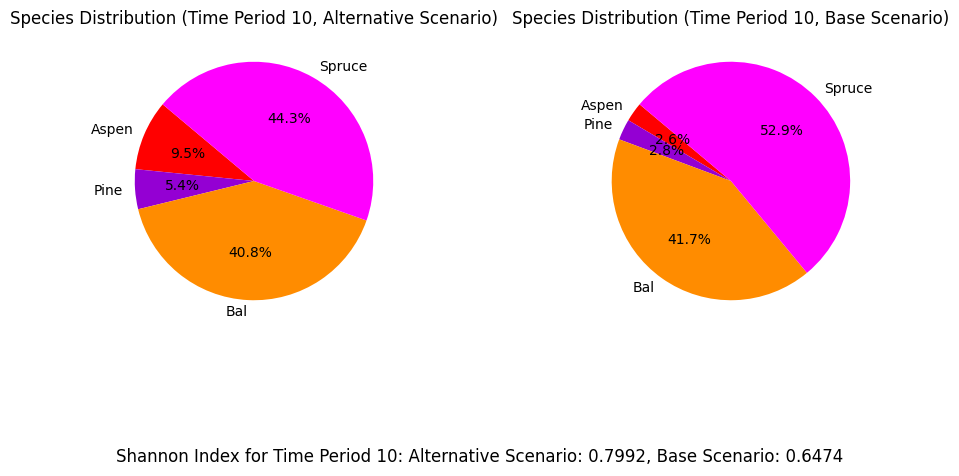

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
It took 69.0 minutes to run all scenarios.


In [12]:
Start = time.time()
scenario_names = scenario_options.get(case_study, [])
for scenario_name in scenario_names:
    print(f"Running for {case_study}_{obj_mode}_{scenario_name}...")
    results_scenarios(fm, 
                      clt_percentage, 
                      credibility, 
                      budget_input, 
                      n_steps, 
                      max_harvest, 
                      scenario_name, 
                      displacement_effect, 
                      hwp_pool_effect_value, 
                      release_immediately_value, 
                      case_study, 
                      obj_mode,                   
                      pickle_output_base=False, 
                      pickle_output_alter=False)
print('It took', round((time.time() - Start) / 60, 1), "minutes to run all scenarios.")

In [13]:
print('It took', round((time.time() - Start) / 60, 1), "minutes to run this script.")

It took 69.0 minutes to run this script.
